# Experimento VQE — versão 20.1

## Pipeline clássico–quântico para análise de pares, bancos de \(\theta\) e Transformer

A versão 20.1 incorpora as conclusões obtidas na primeira execução completa da infraestrutura:

- a reconstrução clássica, a conversão QUBO/Ising e o ansatz de Dicke foram validados;
- \(G_{ij}\) foi identificado como um baseline redundante com a menor margem individual nesta instância;
- `joint_flip_gap` e `joint_flip_nonadditivity` passam a ser as métricas conjuntas principais;
- cada Hamiltoniano recebe um identificador calculado a partir dos termos de Pauli, coeficientes e offset;
- blocos `CCY` passam a registrar todos os seus qubits lógicos;
- a tabela par–\(\theta\) usa a estrutura lógica completa do bloco;
- o caminho do CSV é declarado em uma única linha;
- todos os diretórios de saída são recriados imediatamente antes das gravações;
- o experimento anterior de \(\theta_{17}\) mantém a comparação entre `Statevector` e 4096 shots;
- a nova varredura direta congela os demais parâmetros e altera apenas \(\theta_{17}\), sem COBYLA.

### Pergunta central

> As propriedades conjuntas da paisagem clássica, a posição física dos parâmetros e a distribuição quântica final fornecem informação útil para melhorar o VQE e treinar um Transformer que generalize entre cardinalidades e Hamiltonianos?

## Mudanças científicas e computacionais da versão 20.1

### Resultado incorporado da rodada anterior

A correlação observada foi

$$
\rho_{\mathrm{Spearman}}
\left(
G_{ij},
\min(M_i,M_j)
\right)=1.
$$

Por isso, \(G_{ij}\) permanece no banco como **baseline clássico**, mas não é mais apresentado como medida principal de interação.

As métricas conjuntas principais são

$$
J_{ij}
=
\texttt{joint\_flip\_gap},
$$

e

$$
\mathcal N_{ij}
=
J_{ij}-\Delta_i-\Delta_j.
$$

### Correções estruturais

1. O CSV é definido diretamente por `STOCKS_CSV`.
2. `instance_id` identifica a janela financeira.
3. `hamiltonian_id` identifica o Hamiltoniano realmente construído.
4. `primitive_parameter_qubits` registra onde o parâmetro aparece após a decomposição.
5. `logical_block_qubits` registra todos os qubits envolvidos pelo bloco `CY` ou `CCY`.
6. `physical_qubits` é mantido como alias compatível de `logical_block_qubits`.
7. A tabela par–\(\theta\) é auditada por contagem combinatória.
8. Os diretórios são criados novamente antes de cada exportação.

### Novo teste direto de sensibilidade

A versão 20.1 acrescenta uma varredura determinística de `theta_17` sem COBYLA. O melhor vetor do percentil superior do banco é usado como âncora; os demais parâmetros permanecem congelados e somente `theta_17` é alterado em passos de `0.01`. São exportadas a distribuição completa no subespaço de Dicke, energia, \(P(x^*)\), entropia, TVD, JSD e mapas de calor.


## Hipóteses pré-registradas da versão 20.1

### H1 — Baseline clássico

O valor \(G_{ij}\) será mantido como controle. Uma relação quântica relevante deverá superar o que já é explicado por

$$
\min(M_i,M_j).
$$

### H2 — Rigidez conjunta

O custo de inverter simultaneamente os dois ativos,

$$
J_{ij},
$$

pode identificar pares rígidos mesmo quando a não aditividade é pequena.

### H3 — Interação conjunta

A não aditividade

$$
\mathcal N_{ij}
=
J_{ij}-\Delta_i-\Delta_j
$$

deve separar compensação conjunta, \(\mathcal N_{ij}<0\), de reforço conjunto, \(\mathcal N_{ij}>0\).

### H4 — Estrutura quântica

A relação entre pares financeiros e parâmetros deve usar os qubits lógicos completos do bloco. Para `CCY`, isso significa considerar alvo e controles.

### H5 — Restrição de \(\theta_{17}\)

Fixar \(\theta_{17}\) numa região associada às melhores soluções e reotimizar os demais parâmetros poderá alterar energia, probabilidade do ótimo e forma da distribuição.

### H6 — Generalização

Os splits do Transformer devem ocorrer por `hamiltonian_id`, nunca entre execuções do mesmo Hamiltoniano.

In [ ]:
# ============================================================
# 1. IMPORTS, CAMINHOS E CONFIGURAÇÃO ÚNICA — VERSÃO 20.1
# ============================================================

from __future__ import annotations

from itertools import combinations
from pathlib import Path
from time import perf_counter
import hashlib
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr, wilcoxon

NOTEBOOK_VERSION = "20.1"

# Problema original
N_ASSETS = 10
TARGET_K = 4
K_VALUES = (2, 3, 4, 5)
Q_VALUE = 0.5
RISK_FREE = 0.0475
RANDOM_SEED = 42

# O caminho correto é declarado uma única vez.
# Altere somente esta linha quando o arquivo estiver em outro local.
STOCKS_CSV = Path(r"C:\Users\Marlon_Kelly\Downloads\stocks_prices.csv")
stock_path = STOCKS_CSV.resolve()

if not stock_path.is_file():
    raise FileNotFoundError(
        "CSV não encontrado. Caminho configurado: "
        f"{stock_path}"
    )

# Banco já existente com as 10.000 execuções de k=4.
# O notebook está dentro da pasta notebooks.
EXISTING_K4_BANK = Path("results/merged.pkl").resolve()

if not EXISTING_K4_BANK.is_file():
    raise FileNotFoundError(
        "Banco k=4 não encontrado em: "
        f"{EXISTING_K4_BANK}"
    )

print("Banco k=4 configurado:", EXISTING_K4_BANK)

# Auditoria histórica do caso k=4.
KNOWN_EXACT_QISKIT_BITSTRING = "1001011000"
KNOWN_EXACT_ENERGY = -0.8181062577496281
STRICT_HISTORICAL_AUDIT = True

ENERGY_EQUALITY_ATOL = 1e-8
COMPETITIVE_REL_TOL = 0.01

# Banco definitivo
BANK_RUNS_PER_CONFIGURATION = 10000
COBYLA_MAXITER = 250
SHOTS = 4096
ESTIMATOR_PRECISION = float(1.0 / np.sqrt(SHOTS))
GENERATE_OR_RESUME_BANKS = False

# Experimento theta_17
RUN_THETA17_FIXED_EXPERIMENT = False
THETA17_INDEX = 17
THETA17_GRID_POINTS = 7
THETA17_RESTARTS = 20
THETA17_OPTIMAL_QUANTILE = 0.25
THETA17_INTERVAL_COVERAGE = 0.80
THETA17_MIN_OPTIMAL_ROWS = 20
THETA17_MIN_INTERVAL_FRACTION = 0.05
THETA17_DISTRIBUTION_SHOTS = SHOTS

# Varredura direta de theta_17 sem COBYLA
# A máscara mantém o percentil superior de qualidade:
# TOP_FRACTION=0.10 corresponde aos 10% melhores vetores do banco.
RUN_THETA17_DIRECT_SWEEP = True
THETA17_DIRECT_TOP_FRACTION = 0.10
THETA17_DIRECT_STEP = 0.01
THETA17_DIRECT_REQUESTED_END = float(np.pi)
THETA17_DIRECT_SCAN_FULL_PERIOD = True
THETA17_DIRECT_TOP_N_PORTFOLIOS = 10
THETA17_DIRECT_CHECKPOINT_EVERY = 50
THETA17_DIRECT_EXPECTED_BANK_ROWS = 10000

# Saídas
results_root = Path("vqe_r")
output_dir = results_root / "pipeline_v20"
classical_dir = output_dir / "01_classical"
quantum_dir = output_dir / "02_quantum"
bank_dir = output_dir / "03_banks"
transformer_dir = output_dir / "04_transformer_dataset"
theta17_dir = output_dir / "05_theta17_fixed_experiment"
theta17_direct_dir = output_dir / "06_theta17_direct_sweep"
figure_dir = output_dir / "figures"


def ensure_output_directories():
    """Cria novamente todos os diretórios antes de qualquer exportação."""
    for directory in [
        output_dir,
        classical_dir,
        quantum_dir,
        bank_dir,
        transformer_dir,
        theta17_dir,
        theta17_direct_dir,
        figure_dir,
    ]:
        directory.mkdir(parents=True, exist_ok=True)


ensure_output_directories()

CONFIG = {
    "notebook_version": NOTEBOOK_VERSION,
    "n_assets": N_ASSETS,
    "target_k": TARGET_K,
    "k_values": list(K_VALUES),
    "q_value": Q_VALUE,
    "risk_free": RISK_FREE,
    "random_seed": RANDOM_SEED,
    "stocks_csv": str(STOCKS_CSV),
    "strict_historical_audit": STRICT_HISTORICAL_AUDIT,
    "energy_equality_atol": ENERGY_EQUALITY_ATOL,
    "competitive_relative_tolerance": COMPETITIVE_REL_TOL,
    "bank_runs_per_configuration": BANK_RUNS_PER_CONFIGURATION,
    "cobyla_maxiter": COBYLA_MAXITER,
    "shots": SHOTS,
    "estimator_precision": ESTIMATOR_PRECISION,
    "generate_or_resume_banks": GENERATE_OR_RESUME_BANKS,
    "run_theta17_fixed_experiment": RUN_THETA17_FIXED_EXPERIMENT,
    "theta17_index": THETA17_INDEX,
    "theta17_grid_points": THETA17_GRID_POINTS,
    "theta17_restarts": THETA17_RESTARTS,
    "theta17_distribution_shots": THETA17_DISTRIBUTION_SHOTS,
    "run_theta17_direct_sweep": RUN_THETA17_DIRECT_SWEEP,
    "theta17_direct_top_fraction": THETA17_DIRECT_TOP_FRACTION,
    "theta17_direct_step": THETA17_DIRECT_STEP,
    "theta17_direct_requested_end": THETA17_DIRECT_REQUESTED_END,
    "theta17_direct_scan_full_period": THETA17_DIRECT_SCAN_FULL_PERIOD,
    "theta17_direct_top_n_portfolios": THETA17_DIRECT_TOP_N_PORTFOLIOS,
    "theta17_direct_expected_bank_rows": THETA17_DIRECT_EXPECTED_BANK_ROWS,
}

print(json.dumps(CONFIG, indent=2, ensure_ascii=False))
print("CSV:", STOCKS_CSV)
print("saídas:", output_dir)

{
  "notebook_version": "20.0",
  "n_assets": 10,
  "target_k": 4,
  "k_values": [
    2,
    3,
    4,
    5
  ],
  "q_value": 0.5,
  "risk_free": 0.0475,
  "random_seed": 42,
  "stocks_csv": "C:\\Users\\Marlon_Kelly\\Downloads\\stocks_prices.csv",
  "strict_historical_audit": true,
  "energy_equality_atol": 1e-08,
  "competitive_relative_tolerance": 0.01,
  "bank_runs_per_configuration": 100,
  "cobyla_maxiter": 250,
  "shots": 4096,
  "estimator_precision": 0.015625,
  "generate_or_resume_banks": true,
  "run_theta17_fixed_experiment": true,
  "theta17_index": 17,
  "theta17_grid_points": 7,
  "theta17_restarts": 20,
  "theta17_distribution_shots": 4096
}
CSV: C:\Users\Marlon_Kelly\Downloads\stocks_prices.csv
saídas: vqe_r\pipeline_v20


# Parte I — Reconstrução clássica exata

Esta parte não utiliza circuito quântico. Ela define a paisagem combinatória que qualquer algoritmo quântico ou modelo de aprendizado deverá reproduzir.

Para um vetor binário

$$
x=(x_0,x_1,\ldots,x_{n-1}), \qquad x_i\in\{0,1\},
$$

a função objetivo utilizada é

$$
E(x)
=
q\,x^{\mathsf T}\Sigma x
-
(1-q)\,\mu^{\mathsf T}x
+
r_f,
$$

sujeita à restrição de cardinalidade

$$
\sum_{i=0}^{n-1}x_i=k.
$$

Nesta formulação:

- \(q\) controla a aversão ao risco;
- \(\Sigma\) é a matriz de covariância;
- \(\mu\) contém os retornos dos ativos;
- \(r_f\) é o termo constante preservado do experimento original;
- \(k\) é o número exato de ativos selecionados.

O retorno usado neste projeto é a **soma dos retornos diários**, e não a média. Alterar essa definição produz outro problema financeiro e, consequentemente, outro Hamiltoniano.

In [18]:
# ============================================================
# 2. PREÇOS, RETORNOS E COVARIÂNCIA
# ============================================================

stocks_prices = pd.read_csv(stock_path, index_col=0)
stocks_prices = (
    stocks_prices
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .dropna(axis=1, how="all")
    .ffill()
    .bfill()
    .dropna()
)

if stocks_prices.empty:
    raise ValueError("O CSV não contém dados numéricos válidos.")
if stocks_prices.columns.duplicated().any():
    raise ValueError("O CSV possui tickers repetidos.")
if stocks_prices.shape[1] != N_ASSETS:
    raise ValueError(
        f"Esperados {N_ASSETS} ativos; encontrados {stocks_prices.shape[1]}: "
        f"{stocks_prices.columns.tolist()}"
    )
if len(stocks_prices) < 3:
    raise ValueError("São necessárias ao menos três datas.")

daily_returns = stocks_prices.pct_change(fill_method=None).dropna()
assets_returns = daily_returns.sum()
covariance = daily_returns.cov()

mu = assets_returns.to_numpy(dtype=float)
sigma = covariance.to_numpy(dtype=float)
sigma = 0.5 * (sigma + sigma.T)
tickers = list(stocks_prices.columns)

if not np.all(np.isfinite(mu)) or not np.all(np.isfinite(sigma)):
    raise ValueError("Retornos ou covariância contêm valores não finitos.")

min_cov_eigenvalue = float(np.linalg.eigvalsh(sigma).min())
if min_cov_eigenvalue < -1e-10:
    raise ValueError(
        "A covariância não é semidefinida positiva dentro da tolerância: "
        f"lambda_min={min_cov_eigenvalue:.3e}"
    )

asset_summary_df = pd.DataFrame({
    "asset_index": np.arange(N_ASSETS, dtype=int),
    "ticker": tickers,
    "return_sum": mu,
    "variance": np.diag(sigma),
    "risk_connection_abs": np.sum(np.abs(sigma), axis=1),
})

DATA_HASH = hashlib.sha256(
    np.concatenate([mu, sigma.reshape(-1)]).astype(np.float64).tobytes()
).hexdigest()[:16]

print("preços:", stocks_prices.shape)
print("retornos diários:", daily_returns.shape)
print("tickers:", tickers)
print("data_hash:", DATA_HASH)
print("menor autovalor da covariância:", f"{min_cov_eigenvalue:.3e}")
display(asset_summary_df)


preços: (251, 10)
retornos diários: (250, 10)
tickers: ['AAPL', 'AIG', 'AMD', 'COST', 'DAL', 'DVA', 'JPM', 'KO', 'V', 'WFC']
data_hash: fe1c8a9efc6a24d7
menor autovalor da covariância: 4.880e-05


,asset_index,ticker,return_sum,variance,risk_connection_abs
0,0,AAPL,0.277937,0.000201,0.000455
1,1,AIG,0.122904,0.000163,0.000641
2,2,AMD,0.022556,0.000914,0.001700
3,3,COST,0.422849,0.000140,0.000485
4,4,DAL,0.457501,0.000425,0.001161
5,5,DVA,0.384770,0.000337,0.000623
6,6,JPM,0.415765,0.000214,0.000794
7,7,KO,0.096391,0.000066,0.000199
8,8,V,0.220497,0.000110,0.000452
9,9,WFC,0.437331,0.000324,0.000960


## 3. Funções exatas compartilhadas por todos os valores de \(k\)

Para cada par \((i,j)\), são calculados os quatro mínimos condicionados:

$$
E_{ij}^{ab}
=
\min_{\substack{
x_i=a,\;x_j=b\\
\sum_{\ell=0}^{n-1}x_\ell=k
}}
E(x),
\qquad
ab\in\{00,01,10,11\}.
$$

O valor

$$
G_{ij}
=
E_{ij}^{(2)}-E^\ast
$$

é preservado como baseline. A execução anterior mostrou que, para esta instância, seu ranking coincide exatamente com

$$
\min(M_i,M_j).
$$

As métricas conjuntas principais passam a ser:

$$
J_{ij}
=
E_{ij}^{1-a^\ast,\,1-b^\ast}-E^\ast,
$$

e

$$
\mathcal N_{ij}
=
J_{ij}
-
\Delta_i
-
\Delta_j.
$$

Também são registrados os quatro estados condicionados, bitstrings, distância de Hamming, ativos adicionados, ativos removidos e número de swaps.

In [19]:
# ============================================================
# 3. ENUMERAÇÃO, MARGEM ANTIGA E GAPS CONDICIONAIS
# ============================================================

PAIR_STATES = ("00", "01", "10", "11")


def portfolio_objective(x_binary, mu_values=mu, sigma_values=sigma):
    """
    Calcula a função objetivo clássica:

        E(x) = q * (x^T Sigma x) - (1 - q) * (mu^T x) + r_f

    sujeita à restrição de cardinalidade aplicada na enumeração:

        sum_i x_i = k,  com x_i em {0, 1}.

    Esta função é a referência única usada no caso k=4 e nos contextos multi-k.
    """
    x = np.asarray(x_binary, dtype=float).reshape(-1)
    return float(
        Q_VALUE * x @ sigma_values @ x
        - (1.0 - Q_VALUE) * x @ mu_values
        + RISK_FREE
    )


def bitstring_from_x(x):
    return "".join(str(int(value)) for value in np.asarray(x, dtype=int))


def selected_assets_from_x(x, labels=tickers):
    return [ticker for ticker, selected in zip(labels, x) if int(selected) == 1]


def enumerate_portfolios(k_value, mu_values=mu, sigma_values=sigma, labels=tickers):
    n_value = len(labels)
    rows = []
    for selected_indices in combinations(range(n_value), int(k_value)):
        x = np.zeros(n_value, dtype=int)
        x[list(selected_indices)] = 1
        bits = bitstring_from_x(x)
        rows.append({
            "selected_indices": tuple(int(i) for i in selected_indices),
            "x_asset_order": tuple(int(v) for v in x),
            "bitstring_asset_order": bits,
            "bitstring_qiskit_order": bits[::-1],
            "selected_assets": tuple(selected_assets_from_x(x, labels)),
            "objective": portfolio_objective(x, mu_values, sigma_values),
        })
    return (
        pd.DataFrame(rows)
        .sort_values(["objective", "bitstring_asset_order"])
        .reset_index(drop=True)
    )


def old_asset_decision_margins(exact_x, exact_energy, energy_span, labels=tickers):
    selected_indices = np.flatnonzero(exact_x == 1)
    excluded_indices = np.flatnonzero(exact_x == 0)
    rows = []
    for asset_index in range(len(labels)):
        alternatives = []
        if exact_x[asset_index] == 1:
            for replacement in excluded_indices:
                trial = exact_x.copy()
                trial[asset_index] = 0
                trial[replacement] = 1
                alternatives.append((portfolio_objective(trial), trial))
        else:
            for removed in selected_indices:
                trial = exact_x.copy()
                trial[asset_index] = 1
                trial[removed] = 0
                alternatives.append((portfolio_objective(trial), trial))
        best_energy, best_trial = min(alternatives, key=lambda item: item[0])
        margin = max(float(best_energy - exact_energy), 0.0)
        rows.append({
            "asset_index": int(asset_index),
            "ticker": labels[asset_index],
            "selected_exact": int(exact_x[asset_index]),
            "decision_margin": margin,
            "decision_margin_relative": margin / max(energy_span, ENERGY_EQUALITY_ATOL),
            "best_flip_bitstring": bitstring_from_x(best_trial),
            "best_flip_selected_assets": tuple(selected_assets_from_x(best_trial, labels)),
            "return_coefficient": float(-(1.0 - Q_VALUE) * mu[asset_index]),
            "self_risk_coefficient": float(Q_VALUE * sigma[asset_index, asset_index]),
            "risk_connection": float(Q_VALUE * np.sum(np.abs(sigma[asset_index]))),
        })
    return pd.DataFrame(rows).sort_values("decision_margin", ascending=False).reset_index(drop=True)


def build_pair_gap_table(enumeration_df, exact_x, exact_energy, energy_span, asset_margin_df, labels=tickers):
    n_value = len(labels)
    margin_lookup = asset_margin_df.set_index("asset_index")["decision_margin"].to_dict()

    def conditional_best(i, j, state):
        """
        Implementa diretamente o mínimo condicionado:

            E_ij^(ab) =
                min E(x)
                sujeito a x_i = a, x_j = b e sum_l x_l = k.

        Como todas as carteiras válidas já foram enumeradas, o cálculo é
        exato: filtra-se o estado do par e seleciona-se a menor energia.
        """
        a, b = int(state[0]), int(state[1])
        mask = enumeration_df["x_asset_order"].map(
            lambda x: int(x[i]) == a and int(x[j]) == b
        )
        subset = enumeration_df.loc[mask]
        if subset.empty:
            raise RuntimeError(f"Estado inviável para par {(i, j)}: {state}")
        best = subset.iloc[0]
        return {
            "count": int(len(subset)),
            "energy": float(best["objective"]),
            "bitstring": str(best["bitstring_asset_order"]),
            "selected_assets": tuple(best["selected_assets"]),
        }

    rows = []
    for i, j in combinations(range(n_value), 2):
        state_results = {state: conditional_best(i, j, state) for state in PAIR_STATES}
        ordered_states = sorted(PAIR_STATES, key=lambda s: (state_results[s]["energy"], s))
        best_state, second_state = ordered_states[:2]
        best_energy = state_results[best_state]["energy"]
        second_energy = state_results[second_state]["energy"]
        # Gap condicional principal:
        #
        #     G_ij = E_ij^(segundo melhor estado) - E*
        #
        # Aqui, best_energy coincide com E* pela auditoria estrutural.
        gij = max(float(second_energy - best_energy), 0.0)

        states_at_best = tuple(
            state for state in PAIR_STATES
            if np.isclose(state_results[state]["energy"], best_energy, atol=ENERGY_EQUALITY_ATOL, rtol=0.0)
        )
        second_x = np.asarray([int(v) for v in state_results[second_state]["bitstring"]], dtype=int)
        hamming = int(np.sum(second_x != exact_x))
        removed = [labels[idx] for idx in np.flatnonzero((exact_x == 1) & (second_x == 0))]
        added = [labels[idx] for idx in np.flatnonzero((exact_x == 0) & (second_x == 1))]
        n_swaps = hamming // 2

        global_pair_state = f"{exact_x[i]}{exact_x[j]}"
        decision_pattern = {
            "00": "exclude_exclude",
            "01": "exclude_include",
            "10": "include_exclude",
            "11": "include_include",
        }[global_pair_state]
        a_star, b_star = int(global_pair_state[0]), int(global_pair_state[1])
        single_i_state = f"{1-a_star}{b_star}"
        single_j_state = f"{a_star}{1-b_star}"
        joint_state = f"{1-a_star}{1-b_star}"
        # Penalidades direcionais:
        #
        #     Delta_i     = E_ij^(estado com i invertido) - E*
        #     Delta_j     = E_ij^(estado com j invertido) - E*
        #     Delta_ij    = E_ij^(ambos invertidos) - E*
        #
        # Não aditividade:
        #
        #     N_ij = Delta_ij - Delta_i - Delta_j
        #
        # N_ij != 0 indica que a inversão conjunta não é explicada pela soma
        # de duas decisões individuais independentes.
        single_i_gap = max(state_results[single_i_state]["energy"] - exact_energy, 0.0)
        single_j_gap = max(state_results[single_j_state]["energy"] - exact_energy, 0.0)
        joint_gap = max(state_results[joint_state]["energy"] - exact_energy, 0.0)
        nonadditivity = joint_gap - single_i_gap - single_j_gap
        single_gap_sum = single_i_gap + single_j_gap
        nonadditivity_normalized = (
            nonadditivity
            / max(single_gap_sum, ENERGY_EQUALITY_ATOL)
        )
        exit_gap = min(single_i_gap, single_j_gap, joint_gap)
        delta_01_10 = abs(state_results["01"]["energy"] - state_results["10"]["energy"])
        top2_swap = set(ordered_states[:2]) == {"01", "10"}

        rows.append({
            "asset_i": labels[i], "asset_j": labels[j],
            "asset_index_i": int(i), "asset_index_j": int(j),
            "pair": f"{labels[i]}/{labels[j]}",
            "global_pair_state": global_pair_state,
            "decision_pattern": decision_pattern,
            "single_flip_i_state": single_i_state,
            "single_flip_j_state": single_j_state,
            "joint_complement_state": joint_state,
            "single_flip_i_gap": float(single_i_gap),
            "single_flip_j_gap": float(single_j_gap),
            "joint_flip_gap": float(joint_gap),
            "joint_flip_gap_relative": float(joint_gap / max(energy_span, ENERGY_EQUALITY_ATOL)),
            "joint_flip_nonadditivity": float(nonadditivity),
            "joint_flip_nonadditivity_relative": float(
                nonadditivity / max(energy_span, ENERGY_EQUALITY_ATOL)
            ),
            "joint_flip_nonadditivity_normalized": float(
                nonadditivity_normalized
            ),
            "joint_flip_nonadditivity_abs": float(abs(nonadditivity)),
            "G_ij_decomposition_error": float(abs(gij - exit_gap)),
            **{f"E_{state}": state_results[state]["energy"] for state in PAIR_STATES},
            **{f"delta_{state}": state_results[state]["energy"] - exact_energy for state in PAIR_STATES},
            **{f"count_{state}": state_results[state]["count"] for state in PAIR_STATES},
            **{f"bitstring_{state}": state_results[state]["bitstring"] for state in PAIR_STATES},
            "best_pair_state": best_state,
            "second_best_pair_state": second_state,
            "states_at_best": states_at_best,
            "G_ij": gij,
            "G_ij_relative": gij / max(energy_span, ENERGY_EQUALITY_ATOL),
            "swap_state_energy_difference": delta_01_10,
            "swap_state_difference_relative": delta_01_10 / max(energy_span, ENERGY_EQUALITY_ATOL),
            "top2_are_01_10": bool(top2_swap),
            "second_best_conditional_bitstring": state_results[second_state]["bitstring"],
            "second_best_selected_assets": state_results[second_state]["selected_assets"],
            "hamming_distance_from_global_optimum": hamming,
            "number_of_asset_swaps": int(n_swaps),
            "assets_removed": tuple(removed),
            "assets_added": tuple(added),
            "G_ij_per_swap": gij / max(n_swaps, 1),
            "old_margin_i": float(margin_lookup[i]),
            "old_margin_j": float(margin_lookup[j]),
            "old_pair_margin_min": float(min(margin_lookup[i], margin_lookup[j])),
            "old_pair_margin_sum": float(margin_lookup[i] + margin_lookup[j]),
            "opposite_decisions": bool(exact_x[i] != exact_x[j]),
        })

    table = pd.DataFrame(rows)
    table["is_degenerate"] = table["states_at_best"].map(len).gt(1)
    table["is_ambiguous"] = (~table["is_degenerate"] & table["G_ij_relative"].le(COMPETITIVE_REL_TOL))
    table["is_competitive_swap"] = (
        table["top2_are_01_10"] & table["swap_state_difference_relative"].le(COMPETITIVE_REL_TOL)
    )

    def classify(row):
        if row["is_degenerate"]:
            return "degenerate"
        if row["is_ambiguous"]:
            return "ambiguous"
        if row["is_competitive_swap"]:
            return "competitive_swap"
        return row["decision_pattern"]

    table["pair_class"] = table.apply(classify, axis=1)

    # Diagnóstico incorporado da rodada anterior:
    # G_ij é comparado diretamente com a menor margem individual.
    table["G_ij_minus_old_pair_margin_min"] = (
        table["G_ij"] - table["old_pair_margin_min"]
    )
    table["G_ij_equals_old_pair_margin_min"] = np.isclose(
        table["G_ij"],
        table["old_pair_margin_min"],
        atol=ENERGY_EQUALITY_ATOL,
        rtol=0.0,
    )

    table["G_ij_rank"] = (
        table["G_ij"].rank(method="min", ascending=False).astype(int)
    )
    table["joint_flip_gap_rank"] = (
        table["joint_flip_gap"].rank(method="min", ascending=False).astype(int)
    )
    table["joint_flip_nonadditivity_abs_rank"] = (
        table["joint_flip_nonadditivity_abs"]
        .rank(method="min", ascending=False)
        .astype(int)
    )

    # A ordenação padrão é mantida por G_ij para compatibilidade histórica.
    # As análises principais usam explicitamente os ranks conjuntos.
    table = table.sort_values(
        ["G_ij", "pair"],
        ascending=[False, True],
    ).reset_index(drop=True)
    return table


def build_classical_analysis(k_value):
    enumeration = enumerate_portfolios(k_value)
    exact_energy = float(enumeration.loc[0, "objective"])
    optimal_mask = np.isclose(
        enumeration["objective"].to_numpy(dtype=float), exact_energy,
        atol=ENERGY_EQUALITY_ATOL, rtol=0.0,
    )
    optimal = enumeration.loc[optimal_mask].copy()
    exact_asset_bitstrings = sorted(optimal["bitstring_asset_order"].astype(str).unique())
    exact_qiskit_bitstrings = sorted(optimal["bitstring_qiskit_order"].astype(str).unique())
    exact_x = np.asarray([int(v) for v in exact_asset_bitstrings[0]], dtype=int)
    energy_span = float(enumeration["objective"].max() - exact_energy)
    margins = old_asset_decision_margins(exact_x, exact_energy, energy_span)
    pairs = build_pair_gap_table(enumeration, exact_x, exact_energy, energy_span, margins)
    return {
        "k": int(k_value),
        "enumeration_df": enumeration,
        "optimal_df": optimal,
        "exact_energy": exact_energy,
        "energy_span": energy_span,
        "exact_x": exact_x,
        "exact_asset_bitstrings": exact_asset_bitstrings,
        "exact_qiskit_bitstrings": exact_qiskit_bitstrings,
        "selected_assets": selected_assets_from_x(exact_x),
        "asset_decision_df": margins,
        "pair_table": pairs,
    }


## 4. Caso original \(k=4\): auditoria histórica e análise dos 45 pares

O caso \(k=4\) é executado primeiro porque possui energia e bitstring históricos conhecidos.

A auditoria é dividida em duas camadas independentes.

### 4.1 Auditoria estrutural obrigatória

Essa camada verifica propriedades matemáticas que devem ser verdadeiras em qualquer janela de dados:

- número correto de carteiras válidas;
- número correto de pares;
- contagem correta de estados \(00\), \(01\), \(10\) e \(11\);
- coincidência entre o menor mínimo condicionado e a energia global;
- não negatividade das penalidades;
- paridade da distância de Hamming;
- consistência da decomposição de \(G_{ij}\).

Qualquer falha estrutural interrompe a execução.

### 4.2 Auditoria histórica opcional

Essa camada compara a energia e o bitstring atuais com o experimento histórico original.

Quando

```python
STRICT_HISTORICAL_AUDIT = True
```

uma divergência interrompe a execução.

Quando

```python
STRICT_HISTORICAL_AUDIT = False
```

a divergência é registrada como aviso, permitindo analisar novas janelas temporais, matrizes de covariância e Hamiltonianos sem editar manualmente os valores históricos.

In [20]:
# ============================================================
# 4. EXECUTAR E AUDITAR O CASO ORIGINAL k=4
# ============================================================

target_classical = build_classical_analysis(TARGET_K)
enumeration_df = target_classical["enumeration_df"]
asset_decision_df = target_classical["asset_decision_df"]
pair_table = target_classical["pair_table"]
EXACT_ENERGY = target_classical["exact_energy"]
ENERGY_SPAN = target_classical["energy_span"]
EXACT_X = target_classical["exact_x"]
EXACT_ASSET_BITSTRINGS = target_classical["exact_asset_bitstrings"]
EXACT_QISKIT_BITSTRINGS = target_classical["exact_qiskit_bitstrings"]
EXACT_SELECTED_ASSETS = target_classical["selected_assets"]

energy_matches_history = np.isclose(EXACT_ENERGY, KNOWN_EXACT_ENERGY, atol=1e-10, rtol=0.0)
bitstring_matches_history = KNOWN_EXACT_QISKIT_BITSTRING in EXACT_QISKIT_BITSTRINGS
expected_counts = {
    "00": math.comb(N_ASSETS - 2, TARGET_K),
    "01": math.comb(N_ASSETS - 2, TARGET_K - 1),
    "10": math.comb(N_ASSETS - 2, TARGET_K - 1),
    "11": math.comb(N_ASSETS - 2, TARGET_K - 2),
}
energy_columns = [f"E_{state}" for state in PAIR_STATES]
delta_columns = [f"delta_{state}" for state in PAIR_STATES]

historical_audit = {
    "historical_energy_match_ok": bool(energy_matches_history),
    "historical_bitstring_match_ok": bool(bitstring_matches_history),
}

structural_audit = {
    "portfolio_count_ok": len(enumeration_df) == math.comb(N_ASSETS, TARGET_K),
    "pair_count_ok": len(pair_table) == math.comb(N_ASSETS, 2),
    "state_counts_ok": all((pair_table[f"count_{state}"] == count).all() for state, count in expected_counts.items()),
    "conditional_minimum_is_global_ok": bool(np.allclose(
        pair_table[energy_columns].min(axis=1), EXACT_ENERGY,
        atol=ENERGY_EQUALITY_ATOL, rtol=0.0,
    )),
    "nonnegative_deltas_ok": bool((pair_table[delta_columns].min(axis=1) >= -ENERGY_EQUALITY_ATOL).all()),
    "even_hamming_distance_ok": bool((pair_table["hamming_distance_from_global_optimum"] % 2 == 0).all()),
    "G_ij_decomposition_ok": bool(pair_table["G_ij_decomposition_error"].le(ENERGY_EQUALITY_ATOL).all()),
}

g_redundancy_fraction = float(
    pair_table["G_ij_equals_old_pair_margin_min"].mean()
)
classical_diagnostic = {
    "G_ij_equals_old_pair_margin_min_fraction": g_redundancy_fraction,
    "G_ij_is_fully_redundant_in_this_instance": bool(
        np.isclose(g_redundancy_fraction, 1.0)
    ),
    "primary_pair_metrics": [
        "joint_flip_gap",
        "joint_flip_nonadditivity",
    ],
    "baseline_pair_metric": "G_ij",
}

audit = {
    "strict_historical_audit": bool(STRICT_HISTORICAL_AUDIT),
    **historical_audit,
    **structural_audit,
    **classical_diagnostic,
}

failed_structural = [
    name
    for name, value in structural_audit.items()
    if name.endswith("_ok") and not value
]
if failed_structural:
    raise RuntimeError(
        f"Auditoria estrutural clássica falhou: {failed_structural}"
    )

failed_historical = [
    name
    for name, value in historical_audit.items()
    if name.endswith("_ok") and not value
]
if STRICT_HISTORICAL_AUDIT and failed_historical:
    raise RuntimeError(
        "Auditoria histórica clássica falhou: "
        f"{failed_historical}. Revise CSV, ordem das colunas, "
        "retorno=sum(), q e risk_free, ou use "
        "STRICT_HISTORICAL_AUDIT=False para analisar outro Hamiltoniano."
    )

if failed_historical and not STRICT_HISTORICAL_AUDIT:
    warnings.warn(
        "Os valores atuais não coincidem com o caso histórico original, "
        "mas a execução continuará porque STRICT_HISTORICAL_AUDIT=False. "
        f"Divergências: {failed_historical}",
        RuntimeWarning,
    )

print("energia exata:", EXACT_ENERGY)
print("bitstring(s) Qiskit:", EXACT_QISKIT_BITSTRINGS)
print("ativos selecionados:", EXACT_SELECTED_ASSETS)
print(json.dumps(audit, indent=2, ensure_ascii=False))
display(enumeration_df.head(10))
display(asset_decision_df)
display(pair_table.head(15))


energia exata: -0.818106257749624
bitstring(s) Qiskit: ['1001011000']
ativos selecionados: ['COST', 'DAL', 'JPM', 'WFC']
{
  "strict_historical_audit": true,
  "historical_energy_match_ok": true,
  "historical_bitstring_match_ok": true,
  "portfolio_count_ok": true,
  "pair_count_ok": true,
  "state_counts_ok": true,
  "conditional_minimum_is_global_ok": true,
  "nonnegative_deltas_ok": true,
  "even_hamming_distance_ok": true,
  "G_ij_decomposition_ok": true,
  "G_ij_equals_old_pair_margin_min_fraction": 1.0,
  "G_ij_is_fully_redundant_in_this_instance": true,
  "primary_pair_metrics": [
    "joint_flip_gap",
    "joint_flip_nonadditivity"
  ],
  "baseline_pair_metric": "G_ij"
}


,selected_indices,x_asset_order,bitstring_asset_order,bitstring_qiskit_order,selected_assets,objective
0,"(3, 4, 6, 9)","(0, 0, 0, 1, 1, 0, 1, 0, 0, 1)",0001101001,1001011000,"(COST, DAL, JPM, WFC)",-0.818106
1,"(3, 4, 5, 9)","(0, 0, 0, 1, 1, 1, 0, 0, 0, 1)",0001110001,1000111000,"(COST, DAL, DVA, WFC)",-0.802765
2,"(4, 5, 6, 9)","(0, 0, 0, 0, 1, 1, 1, 0, 0, 1)",0000111001,1001110000,"(DAL, DVA, JPM, WFC)",-0.798926
3,"(3, 4, 5, 6)","(0, 0, 0, 1, 1, 1, 1, 0, 0, 0)",0001111000,0001111000,"(COST, DAL, DVA, JPM)",-0.792069
4,"(3, 5, 6, 9)","(0, 0, 0, 1, 0, 1, 1, 0, 0, 1)",0001011001,1001101000,"(COST, DVA, JPM, WFC)",-0.782050
5,"(0, 3, 4, 9)","(1, 0, 0, 1, 1, 0, 0, 0, 0, 1)",1001100001,1000011001,"(AAPL, COST, DAL, WFC)",-0.749452
6,"(0, 4, 6, 9)","(1, 0, 0, 0, 1, 0, 1, 0, 0, 1)",1000101001,1001010001,"(AAPL, DAL, JPM, WFC)",-0.745656
7,"(0, 3, 4, 6)","(1, 0, 0, 1, 1, 0, 1, 0, 0, 0)",1001101000,0001011001,"(AAPL, COST, DAL, JPM)",-0.738764
8,"(0, 4, 5, 9)","(1, 0, 0, 0, 1, 1, 0, 0, 0, 1)",1000110001,1000110001,"(AAPL, DAL, DVA, WFC)",-0.730310
9,"(0, 3, 6, 9)","(1, 0, 0, 1, 0, 0, 1, 0, 0, 1)",1001001001,1001001001,"(AAPL, COST, JPM, WFC)",-0.728727


,asset_index,ticker,selected_exact,decision_margin,decision_margin_relative,best_flip_bitstring,best_flip_selected_assets,return_coefficient,self_risk_coefficient,risk_connection
0,2,AMD,0,0.196938,0.310038,0011100001,"(AMD, COST, DAL, WFC)",-0.011278,0.000457,0.000850
1,7,KO,0,0.159281,0.250755,0001100101,"(COST, DAL, KO, WFC)",-0.048196,0.000033,0.000100
2,1,AIG,0,0.146263,0.230260,0101100001,"(AIG, COST, DAL, WFC)",-0.061452,0.000082,0.000321
3,8,V,0,0.097399,0.153335,0001100011,"(COST, DAL, V, WFC)",-0.110248,0.000055,0.000226
4,0,AAPL,0,0.068655,0.108082,1001100001,"(AAPL, COST, DAL, WFC)",-0.138969,0.000100,0.000228
5,4,DAL,1,0.036057,0.056763,0001011001,"(COST, DVA, JPM, WFC)",-0.228751,0.000213,0.000581
6,9,WFC,1,0.026037,0.040990,0001111000,"(COST, DAL, DVA, JPM)",-0.218665,0.000162,0.000480
7,3,COST,1,0.019181,0.030196,0000111001,"(DAL, DVA, JPM, WFC)",-0.211424,0.000070,0.000243
8,5,DVA,0,0.015342,0.024152,0001110001,"(COST, DAL, DVA, WFC)",-0.192385,0.000169,0.000311
9,6,JPM,1,0.015342,0.024152,0001110001,"(COST, DAL, DVA, WFC)",-0.207883,0.000107,0.000397


,asset_i,asset_j,asset_index_i,asset_index_j,pair,global_pair_state,decision_pattern,single_flip_i_state,single_flip_j_state,joint_complement_state,...,opposite_decisions,is_degenerate,is_ambiguous,is_competitive_swap,pair_class,G_ij_minus_old_pair_margin_min,G_ij_equals_old_pair_margin_min,G_ij_rank,joint_flip_gap_rank,joint_flip_nonadditivity_abs_rank
0,AMD,KO,2,7,AMD/KO,00,exclude_exclude,10,01,11,...,False,False,False,False,exclude_exclude,0.0,True,1,1,45
1,AIG,AMD,1,2,AIG/AMD,00,exclude_exclude,10,01,11,...,False,False,False,False,exclude_exclude,0.0,True,2,2,36
2,AIG,KO,1,7,AIG/KO,00,exclude_exclude,10,01,11,...,False,False,False,False,exclude_exclude,0.0,True,2,3,35
3,AIG,V,1,8,AIG/V,00,exclude_exclude,10,01,11,...,False,False,False,False,exclude_exclude,0.0,True,4,7,31
4,AMD,V,2,8,AMD/V,00,exclude_exclude,10,01,11,...,False,False,False,False,exclude_exclude,0.0,True,4,4,44
5,KO,V,7,8,KO/V,00,exclude_exclude,10,01,11,...,False,False,False,False,exclude_exclude,0.0,True,4,6,34
6,AAPL,AIG,0,1,AAPL/AIG,00,exclude_exclude,10,01,11,...,False,False,False,False,exclude_exclude,0.0,True,7,9,40
7,AAPL,AMD,0,2,AAPL/AMD,00,exclude_exclude,10,01,11,...,False,False,False,False,exclude_exclude,0.0,True,7,5,37
8,AAPL,KO,0,7,AAPL/KO,00,exclude_exclude,10,01,11,...,False,False,False,False,exclude_exclude,0.0,True,7,8,38
9,AAPL,V,0,8,AAPL/V,00,exclude_exclude,10,01,11,...,False,False,False,False,exclude_exclude,0.0,True,7,18,41


## 5. Baseline, rigidez conjunta e não aditividade

A versão 20 separa três objetos:

### Baseline individual do par

$$
G_{ij}^{\mathrm{base}}
=
\min(M_i,M_j).
$$

### Rigidez conjunta

$$
J_{ij}
=
\texttt{joint\_flip\_gap}.
$$

### Não aditividade

$$
\mathcal N_{ij}
=
J_{ij}-\Delta_i-\Delta_j.
$$

A seleção de pares para os testes quânticos considera:

- maior rigidez conjunta;
- maior reforço conjunto;
- maior compensação conjunta;
- maior não aditividade em módulo;
- pares das classes inclusão–inclusão, exclusão–inclusão e exclusão–exclusão;
- referências históricas AMD/COST, AIG/DAL e COST/DAL.

O antigo ranking por \(G_{ij}\) continua sendo exportado para ablação.

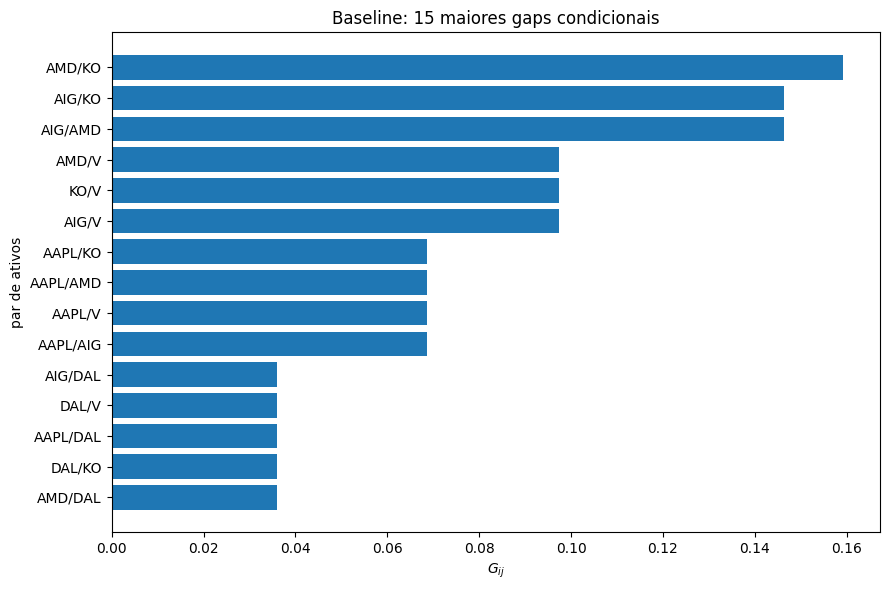

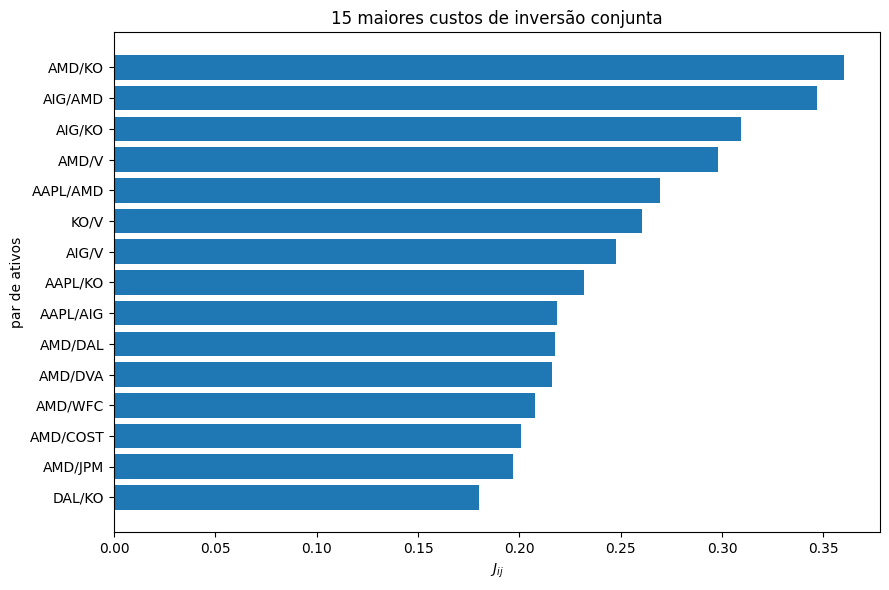

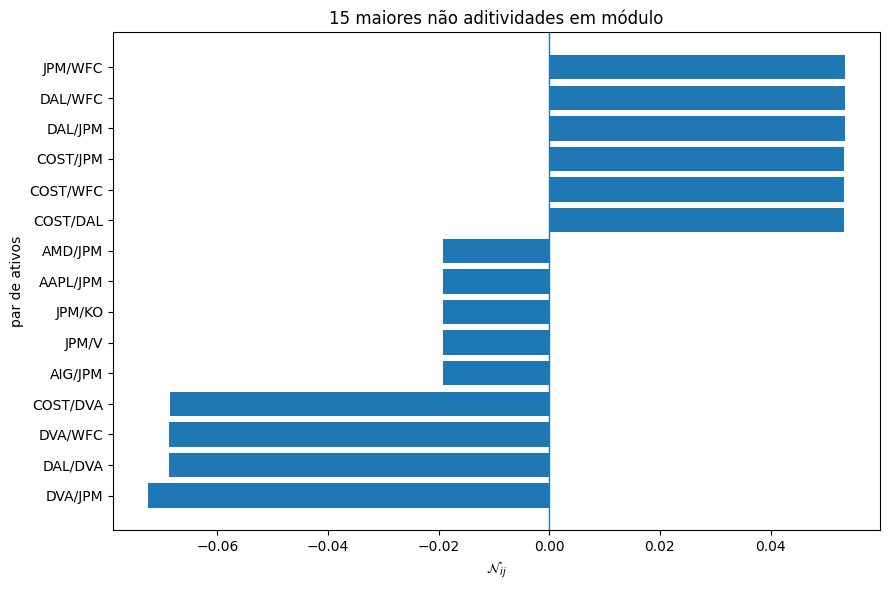

,selection_role,pair,asset_i,asset_j,asset_index_i,asset_index_j,decision_pattern,pair_class,G_ij,joint_flip_gap,joint_flip_nonadditivity,joint_flip_nonadditivity_normalized,old_pair_margin_min,number_of_asset_swaps,status
0,largest_G_baseline,AMD/KO,AMD,KO,2.0,7.0,exclude_exclude,exclude_exclude,0.159281,0.359911,0.003692,0.010364,0.159281,1.0,selected
1,largest_joint_flip_gap,AMD/KO,AMD,KO,2.0,7.0,exclude_exclude,exclude_exclude,0.159281,0.359911,0.003692,0.010364,0.159281,1.0,selected
2,largest_abs_joint_nonadditivity,DVA/JPM,DVA,JPM,5.0,6.0,exclude_include,exclude_include,0.015342,0.015342,-0.072494,-0.825335,0.015342,1.0,selected
3,largest_positive_joint_nonadditivity,JPM/WFC,JPM,WFC,6.0,9.0,include_include,include_include,0.015342,0.094869,0.053490,1.292686,0.015342,1.0,selected
4,largest_negative_joint_nonadditivity,DVA/JPM,DVA,JPM,5.0,6.0,exclude_include,exclude_include,0.015342,0.015342,-0.072494,-0.825335,0.015342,1.0,selected
5,strong_exclude_include_pair,AMD/DAL,AMD,DAL,2.0,4.0,exclude_include,exclude_include,0.036057,0.217627,-0.015368,-0.065957,0.036057,1.0,selected
6,strong_include_include_pair,DAL/WFC,DAL,WFC,4.0,9.0,include_include,include_include,0.026037,0.115519,0.053425,0.860394,0.026037,1.0,selected
7,strong_exclude_exclude_pair,AMD/KO,AMD,KO,2.0,7.0,exclude_exclude,exclude_exclude,0.159281,0.359911,0.003692,0.010364,0.159281,1.0,selected
8,competitive_pair,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_found
9,most_ambiguous_pair,AIG/JPM,AIG,JPM,1.0,6.0,exclude_include,exclude_include,0.015342,0.146263,-0.019258,-0.116348,0.015342,1.0,selected


,metric,baseline,spearman_rho,p_value
0,G_ij,old_pair_margin_min,1.000000,0.000000e+00
1,G_ij,old_pair_margin_sum,0.698686,9.443362e-08
2,joint_flip_gap,old_pair_margin_min,0.679275,2.897170e-07
3,joint_flip_gap,old_pair_margin_sum,0.956871,1.039940e-24
4,joint_flip_nonadditivity_abs,old_pair_margin_min,-0.573753,3.783772e-05
5,joint_flip_nonadditivity_abs,old_pair_margin_sum,-0.698537,9.528231e-08


In [21]:
# ============================================================
# 5. RANKING, ABLAÇÃO E VISUALIZAÇÃO CLÁSSICA — VERSÃO 20
# ============================================================


def first_or_none(df, sort_column, ascending=False):
    if df.empty:
        return None
    return df.sort_values(sort_column, ascending=ascending).iloc[0]


def selection_record(role, row):
    if row is None:
        return {
            "selection_role": role,
            "pair": None,
            "status": "not_found",
        }
    return {
        "selection_role": role,
        "pair": row["pair"],
        "asset_i": row["asset_i"],
        "asset_j": row["asset_j"],
        "asset_index_i": int(row["asset_index_i"]),
        "asset_index_j": int(row["asset_index_j"]),
        "decision_pattern": row["decision_pattern"],
        "pair_class": row["pair_class"],
        "G_ij": float(row["G_ij"]),
        "joint_flip_gap": float(row["joint_flip_gap"]),
        "joint_flip_nonadditivity": float(
            row["joint_flip_nonadditivity"]
        ),
        "joint_flip_nonadditivity_normalized": float(
            row["joint_flip_nonadditivity_normalized"]
        ),
        "old_pair_margin_min": float(row["old_pair_margin_min"]),
        "number_of_asset_swaps": int(row["number_of_asset_swaps"]),
        "status": "selected",
    }


nondegenerate = pair_table.loc[~pair_table["is_degenerate"]].copy()

largest_abs_nonadditivity = (
    None
    if nondegenerate.empty
    else nondegenerate.loc[
        nondegenerate["joint_flip_nonadditivity_abs"].idxmax()
    ]
)
largest_positive_nonadditivity = first_or_none(
    nondegenerate.loc[
        nondegenerate["joint_flip_nonadditivity"].gt(0)
    ],
    "joint_flip_nonadditivity",
)
largest_negative_nonadditivity = first_or_none(
    nondegenerate.loc[
        nondegenerate["joint_flip_nonadditivity"].lt(0)
    ],
    "joint_flip_nonadditivity",
    ascending=True,
)

selections = [
    selection_record(
        "largest_G_baseline",
        first_or_none(nondegenerate, "G_ij"),
    ),
    selection_record(
        "largest_joint_flip_gap",
        first_or_none(nondegenerate, "joint_flip_gap"),
    ),
    selection_record(
        "largest_abs_joint_nonadditivity",
        largest_abs_nonadditivity,
    ),
    selection_record(
        "largest_positive_joint_nonadditivity",
        largest_positive_nonadditivity,
    ),
    selection_record(
        "largest_negative_joint_nonadditivity",
        largest_negative_nonadditivity,
    ),
    selection_record(
        "strong_exclude_include_pair",
        first_or_none(
            nondegenerate.loc[
                nondegenerate["decision_pattern"].isin(
                    ["exclude_include", "include_exclude"]
                )
            ],
            "joint_flip_gap",
        ),
    ),
    selection_record(
        "strong_include_include_pair",
        first_or_none(
            nondegenerate.loc[
                nondegenerate["decision_pattern"].eq("include_include")
            ],
            "joint_flip_gap",
        ),
    ),
    selection_record(
        "strong_exclude_exclude_pair",
        first_or_none(
            nondegenerate.loc[
                nondegenerate["decision_pattern"].eq("exclude_exclude")
            ],
            "joint_flip_gap",
        ),
    ),
    selection_record(
        "competitive_pair",
        first_or_none(
            pair_table.loc[pair_table["is_competitive_swap"]],
            "swap_state_difference_relative",
            ascending=True,
        ),
    ),
    selection_record(
        "most_ambiguous_pair",
        first_or_none(
            nondegenerate,
            "G_ij_relative",
            ascending=True,
        ),
    ),
]

for role, names in {
    "reference_AMD_COST": {"AMD", "COST"},
    "reference_AIG_DAL": {"AIG", "DAL"},
    "reference_COST_DAL": {"COST", "DAL"},
}.items():
    match = pair_table.loc[
        pair_table.apply(
            lambda row: {row["asset_i"], row["asset_j"]} == names,
            axis=1,
        )
    ]
    selections.append(
        selection_record(
            role,
            None if match.empty else match.iloc[0],
        )
    )

pair_category_selection_df = pd.DataFrame(selections)

ablation_rows = []
for metric in [
    "G_ij",
    "joint_flip_gap",
    "joint_flip_nonadditivity_abs",
]:
    for baseline in [
        "old_pair_margin_min",
        "old_pair_margin_sum",
    ]:
        rho, p_value = spearmanr(
            pair_table[metric],
            pair_table[baseline],
        )
        ablation_rows.append({
            "metric": metric,
            "baseline": baseline,
            "spearman_rho": float(rho),
            "p_value": float(p_value),
        })

ablation_summary_df = pd.DataFrame(ablation_rows)

# Baseline histórico
top_g = pair_table.nlargest(15, "G_ij").sort_values("G_ij")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_g["pair"], top_g["G_ij"])
ax.set_xlabel(r"$G_{ij}$")
ax.set_ylabel("par de ativos")
ax.set_title("Baseline: 15 maiores gaps condicionais")
fig.tight_layout()
fig.savefig(
    figure_dir / "01_baseline_Gij_k4.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

# Rigidez conjunta
top_joint = (
    pair_table
    .nlargest(15, "joint_flip_gap")
    .sort_values("joint_flip_gap")
)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_joint["pair"], top_joint["joint_flip_gap"])
ax.set_xlabel(r"$J_{ij}$")
ax.set_ylabel("par de ativos")
ax.set_title("15 maiores custos de inversão conjunta")
fig.tight_layout()
fig.savefig(
    figure_dir / "02_joint_flip_gap_k4.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

# Não aditividade
nonadditivity_plot = (
    pair_table
    .loc[pair_table["joint_flip_nonadditivity_abs"].nlargest(15).index]
    .sort_values("joint_flip_nonadditivity")
)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    nonadditivity_plot["pair"],
    nonadditivity_plot["joint_flip_nonadditivity"],
)
ax.axvline(0.0, linewidth=1.0)
ax.set_xlabel(r"$\mathcal{N}_{ij}$")
ax.set_ylabel("par de ativos")
ax.set_title("15 maiores não aditividades em módulo")
fig.tight_layout()
fig.savefig(
    figure_dir / "03_joint_nonadditivity_k4.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

display(pair_category_selection_df)
display(ablation_summary_df)

## Decisão científica após a parte clássica

A rodada anterior permitiu separar definitivamente três níveis:

$$
\text{margem individual}
\;\neq\;
\text{rigidez conjunta}
\;\neq\;
\text{não aditividade}.
$$

A ponte a ser testada passa a ser

$$
\left\{
J_{ij},
\mathcal N_{ij}
\right\}
\overset{?}{\longrightarrow}
\left\{
F_{ij}^{E},
F_{ij}^{P},
S_{ij}^{\mathrm{causal}}
\right\}
\overset{?}{\longrightarrow}
\text{melhoria operacional do VQE}.
$$

O valor \(G_{ij}\) continua sendo usado somente como baseline.

# Parte II — Codificação QUBO/Ising e auditoria quântica

Depois de a análise clássica passar pelas auditorias, o mesmo problema é escrito como um modelo binário e convertido para QUBO e Hamiltoniano de Ising.

A função financeira implementada no modelo é

$$
\min_x
\left[
q\,x^{\mathsf T}\Sigma x
-
(1-q)\,\mu^{\mathsf T}x
+
r_f
\right],
$$

sujeita a

$$
\sum_i x_i=k.
$$

O Hamiltoniano obtido deve reproduzir a energia exata da enumeração e conter apenas termos diagonais:

$$
H_C
=
c_0 I
+
\sum_i h_i Z_i
+
\sum_{i<j}J_{ij}Z_iZ_j.
$$

A presença de termos \(X\) ou \(Y\) indicaria que a conversão não corresponde ao Hamiltoniano de custo diagonal utilizado nesta investigação.

In [22]:
# ============================================================
# 6. DEPENDÊNCIAS QUÂNTICAS
# ============================================================

from docplex.mp.model import Model
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit import ParameterVector
from qiskit.primitives import BackendEstimatorV2
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_optimization.translators import from_docplex_mp
from qiskit_optimization.converters import QuadraticProgramToQubo

try:
    from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver
    from qiskit_algorithms.optimizers import COBYLA
except ImportError:
    from qiskit.algorithms.minimum_eigensolvers import NumPyMinimumEigensolver
    from qiskit.algorithms.optimizers import COBYLA

try:
    import cvxpy as cp
except ImportError:
    cp = None
    warnings.warn("CVXPY não está instalado; a enumeração continuará sendo a referência clássica.")


In [23]:
# ============================================================
# 7. CONSTRUIR QUBO/ISING PARA UMA CARDINALIDADE
# ============================================================


def build_docplex_ising(k_value):
    """
    Constrói o mesmo problema clássico no DOcplex:

        min_x q * x^T Sigma x - (1-q) * mu^T x + r_f
        sujeito a sum_i x_i = k.

    Em seguida, realiza as transformações:

        problema binário -> QUBO -> Hamiltoniano de Ising.

    A equivalência é auditada comparando energia e bitstring com a
    enumeração clássica exata.
    """
    model = Model(name=f"portfolio_n{N_ASSETS}_k{k_value}")
    variables = np.array([
        model.binary_var(name=f"x_{index}") for index in range(N_ASSETS)
    ], dtype=object)

    risk_expression = model.sum(
        float(sigma[row, column]) * variables[row] * variables[column]
        for row in range(N_ASSETS) for column in range(N_ASSETS)
    )
    return_expression = model.sum(
        float(mu[index]) * variables[index] for index in range(N_ASSETS)
    )
    model.minimize(
        Q_VALUE * risk_expression
        - (1.0 - Q_VALUE) * return_expression
        + RISK_FREE
    )
    model.add_constraint(model.sum(variables.tolist()) == int(k_value), ctname="budget")

    quadratic_program = from_docplex_mp(model=model)
    qubo = QuadraticProgramToQubo().convert(quadratic_program)
    ising, offset = qubo.to_ising()

    labels = [str(label) for label in ising.paulis.to_labels()]
    non_diagonal = [label for label in labels if "X" in label or "Y" in label]
    if non_diagonal:
        raise RuntimeError(f"Hamiltoniano não diagonal: {non_diagonal[:10]}")

    exact_result = NumPyMinimumEigensolver().compute_minimum_eigenvalue(operator=ising)
    exact_energy = float(np.real(exact_result.eigenvalue + offset))
    state_dict = exact_result.eigenstate.to_dict()
    exact_bitstrings = sorted({
        str(bitstring).replace(" ", "")
        for bitstring, amplitude in state_dict.items()
        if abs(amplitude) > 1e-12
    })

    return {
        "model": model,
        "quadratic_program": quadratic_program,
        "qubo": qubo,
        "ising": ising,
        "offset": float(offset),
        "pauli_labels": labels,
        "exact_energy_ising": exact_energy,
        "exact_bitstrings_ising": exact_bitstrings,
    }


target_encoding = build_docplex_ising(TARGET_K)
if not np.isclose(target_encoding["exact_energy_ising"], EXACT_ENERGY, atol=1e-10, rtol=0.0):
    raise RuntimeError("A energia Ising não coincide com a enumeração clássica.")
if not set(EXACT_QISKIT_BITSTRINGS).intersection(target_encoding["exact_bitstrings_ising"]):
    raise RuntimeError("O bitstring Ising não coincide com a enumeração clássica.")

lp_path = quantum_dir / "portfolio_k4.lp"
lp_path.write_text(target_encoding["model"].export_as_lp_string(), encoding="utf-8")

print("energia clássica:", EXACT_ENERGY)
print("energia Ising + offset:", target_encoding["exact_energy_ising"])
print("bitstrings Ising:", target_encoding["exact_bitstrings_ising"])
print("termos de Pauli:", len(target_encoding["pauli_labels"]))
print("LP salvo em:", lp_path.resolve())


energia clássica: -0.818106257749624
energia Ising + offset: -0.8181062577496281
bitstrings Ising: ['1001011000']
termos de Pauli: 55
LP salvo em: C:\Users\Marlon_Kelly\Downloads\vqe_r\pipeline_v20\02_quantum\portfolio_k4.lp


# Parte III — Ansatz de Dicke e mapa físico dos parâmetros

Cada parâmetro possui duas descrições complementares.

### Qubits primitivos do parâmetro

`primitive_parameter_qubits` informa em quais qubits aparecem as instruções que contêm explicitamente \(\theta_r\).

### Qubits lógicos do bloco

`logical_block_qubits` informa todos os qubits envolvidos pelo bloco do ansatz.

Para `CY`:

$$
\texttt{logical\_block\_qubits}=(i,l).
$$

Para `CCY`:

$$
\texttt{logical\_block\_qubits}=(i,i+1,l).
$$

Essa distinção é essencial. Num bloco `CCY`, as rotações \(RY(\pm\theta)\) aparecem apenas no alvo, mas as portas `CCX` conectam o parâmetro aos dois controles.

A periodicidade permanece:

- `CY`: período máximo \(4\pi\), classe `four_pi_eligible`;
- `CCY`: período \(2\pi\), classe `guaranteed_2pi`.

In [24]:
# ============================================================
# 8. PORTAS E ANSATZ DE DICKE RASTREÁVEL
# ============================================================


def CY_parameterized(identifier):
    param = ParameterVector(name=f"x{identifier}", length=1)
    qc = QuantumCircuit(2)
    qc.cry(param[0], 1, 0)
    return qc.to_gate(label="CY")


def CCY_parameterized(identifier):
    param = ParameterVector(name=f"y{identifier}", length=1)
    qc = QuantumCircuit(3)
    qc.ry(param[0], 0)
    qc.ccx(2, 1, 0)
    qc.ry(-param[0], 0)
    qc.ccx(2, 1, 0)
    return qc.to_gate(label="CCY")


def dicke_parameter_count(n_value, k_value):
    return int(k_value * (2 * n_value - k_value - 1) / 2)


def build_tracked_dicke_ansatz(n_value, k_value, seed):
    numpy_state = np.random.get_state()
    try:
        np.random.seed(int(seed))
        qr = QuantumRegister(n_value, "q")
        qc = QuantumCircuit(qr)
        for excitation_index in range(k_value):
            qc.x(n_value - excitation_index - 1)

        records = []
        aux = 1
        for l_value in range(n_value)[::-1]:
            for i_value in range(l_value - 1, l_value - 1 - k_value, -1):
                if i_value >= 0:
                    unique_name = f"{l_value}{i_value}{aux}{np.random.randint(0, int(1e8))}"
                    if i_value == l_value - 1:
                        gate = CY_parameterized(unique_name)
                        gate_parameter = list(gate.params[0].parameters)[0]
                        qc.cx(qr[i_value], qr[l_value])
                        qc.append(gate, [qr[i_value], qr[l_value]])
                        qc.cx(qr[i_value], qr[l_value])
                        gate_type = "CY"
                    else:
                        gate = CCY_parameterized(unique_name)
                        gate_parameter = list(gate.params[0].parameters)[0]
                        qc.cx(qr[i_value], qr[l_value])
                        qc.append(gate, [qr[i_value], qr[i_value + 1], qr[l_value]])
                        qc.cx(qr[i_value], qr[l_value])
                        gate_type = "CCY"
                    records.append({
                        "parameter_object": gate_parameter,
                        "parameter_name": str(gate_parameter),
                        "l": int(l_value),
                        "i": int(i_value),
                        "distance": int(l_value - i_value),
                        "ansatz_gate_type": gate_type,
                    })
                aux += 1
    finally:
        np.random.set_state(numpy_state)

    ordered_parameters = list(qc.parameters)
    parameter_to_index = {parameter: index for index, parameter in enumerate(ordered_parameters)}
    structure_rows = []
    for record in records:
        parameter_object = record.pop("parameter_object")
        structure_rows.append({
            "theta_index": int(parameter_to_index[parameter_object]),
            **record,
        })
    structure_df = pd.DataFrame(structure_rows).sort_values("theta_index").reset_index(drop=True)
    expected = dicke_parameter_count(n_value, k_value)
    if len(structure_df) != expected:
        raise RuntimeError(f"Esperados {expected} parâmetros; encontrados {len(structure_df)}.")
    structure_df["n"] = int(n_value)
    structure_df["k"] = int(k_value)
    structure_df["rho_k_over_n"] = k_value / n_value
    structure_df["u_l"] = structure_df["l"] / max(n_value - 1, 1)
    structure_df["u_distance"] = structure_df["distance"] / max(k_value, 1)
    structure_df["u_theta_index"] = structure_df["theta_index"] / max(expected - 1, 1)
    return qc.decompose(), structure_df


In [25]:
# ============================================================
# 9. MAPA FÍSICO E LÓGICO DOS PARÂMETROS
# ============================================================


def build_physical_parameter_map(ansatz, structure_df):
    """
    Mapeia cada theta em dois níveis:

    1. primitive_parameter_qubits:
       qubits das instruções primitivas que contêm explicitamente theta;

    2. logical_block_qubits:
       todos os qubits do bloco CY ou CCY.

    Para compatibilidade, physical_qubits é definido como alias dos
    qubits lógicos completos.
    """
    parameter_order = list(ansatz.parameters)
    parameter_to_index = {
        parameter: index
        for index, parameter in enumerate(parameter_order)
    }
    occurrence_rows = []

    for instruction_position, instruction in enumerate(ansatz.data):
        operation = instruction.operation
        operation_name = str(operation.name).lower()
        qubits = tuple(
            int(ansatz.find_bit(qubit).index)
            for qubit in instruction.qubits
        )

        for parameter_slot, expression in enumerate(operation.params):
            expression_parameters = getattr(
                expression,
                "parameters",
                set(),
            )
            for parameter in expression_parameters:
                if parameter not in parameter_to_index:
                    continue
                try:
                    coefficient = float(
                        expression.gradient(parameter)
                    )
                except Exception:
                    coefficient = np.nan

                occurrence_rows.append({
                    "theta_index": int(
                        parameter_to_index[parameter]
                    ),
                    "parameter_name": str(parameter),
                    "primitive_operation": operation_name,
                    "primitive_qubits": qubits,
                    "instruction_position": int(
                        instruction_position
                    ),
                    "parameter_slot": int(parameter_slot),
                    "parameter_coefficient": coefficient,
                })

    occurrence_df = pd.DataFrame(occurrence_rows)
    physical_rows = []

    for theta_index, group in occurrence_df.groupby("theta_index"):
        operations = sorted(
            set(group["primitive_operation"].astype(str))
        )
        primitive_parameter_qubits = tuple(sorted({
            int(qubit)
            for qubit_tuple in group["primitive_qubits"]
            for qubit in qubit_tuple
        }))

        if "cry" in operations:
            primitive_type = "CRY"
            angular_period = float(4 * np.pi)
            periodicity_class = "four_pi_eligible"
        else:
            primitive_type = "RY"
            angular_period = float(2 * np.pi)
            periodicity_class = "guaranteed_2pi"

        physical_rows.append({
            "theta_index": int(theta_index),
            "primitive_physical_type": primitive_type,
            "primitive_operations": tuple(operations),
            "primitive_parameter_qubits": (
                primitive_parameter_qubits
            ),
            "angular_period": angular_period,
            "periodicity_structural_class": periodicity_class,
            "n_occurrences_decomposed": int(len(group)),
            "parameter_coefficients": tuple(
                float(value)
                for value in group["parameter_coefficient"]
            ),
            "first_instruction": int(
                group["instruction_position"].min()
            ),
            "last_instruction": int(
                group["instruction_position"].max()
            ),
            "fourier_n_grid_minimum": 5,
        })

    parameter_map = (
        structure_df
        .merge(
            pd.DataFrame(physical_rows),
            on="theta_index",
            how="left",
            validate="one_to_one",
        )
        .sort_values("theta_index")
        .reset_index(drop=True)
    )

    if parameter_map["primitive_physical_type"].isna().any():
        raise RuntimeError(
            "Mapa físico incompleto após a decomposição."
        )

    def logical_qubits_from_row(row):
        i_value = int(row["i"])
        l_value = int(row["l"])

        if row["ansatz_gate_type"] == "CY":
            return tuple(sorted((i_value, l_value)))

        if row["ansatz_gate_type"] == "CCY":
            return tuple(sorted((
                i_value,
                i_value + 1,
                l_value,
            )))

        raise RuntimeError(
            "Tipo de bloco desconhecido: "
            f"{row['ansatz_gate_type']}"
        )

    parameter_map["logical_block_qubits"] = (
        parameter_map.apply(
            logical_qubits_from_row,
            axis=1,
        )
    )

    # Alias compatível. A partir da versão 20, physical_qubits representa
    # o bloco lógico completo, e não apenas as rotações parametrizadas.
    parameter_map["physical_qubits"] = (
        parameter_map["logical_block_qubits"]
    )

    cy = parameter_map["ansatz_gate_type"].eq("CY")
    ccy = parameter_map["ansatz_gate_type"].eq("CCY")

    checks = {
        "CY_is_CRY": bool(
            parameter_map.loc[
                cy,
                "primitive_physical_type",
            ].eq("CRY").all()
        ),
        "CY_has_one_occurrence": bool(
            parameter_map.loc[
                cy,
                "n_occurrences_decomposed",
            ].eq(1).all()
        ),
        "CY_has_4pi_max_period": bool(
            np.allclose(
                parameter_map.loc[cy, "angular_period"],
                4 * np.pi,
            )
        ),
        "CY_has_two_logical_qubits": bool(
            parameter_map.loc[
                cy,
                "logical_block_qubits",
            ].map(len).eq(2).all()
        ),
        "CCY_is_RY": bool(
            parameter_map.loc[
                ccy,
                "primitive_physical_type",
            ].eq("RY").all()
        ),
        "CCY_has_two_occurrences": bool(
            parameter_map.loc[
                ccy,
                "n_occurrences_decomposed",
            ].eq(2).all()
        ),
        "CCY_has_2pi_period": bool(
            np.allclose(
                parameter_map.loc[ccy, "angular_period"],
                2 * np.pi,
            )
        ),
        "CCY_has_one_primitive_parameter_qubit": bool(
            parameter_map.loc[
                ccy,
                "primitive_parameter_qubits",
            ].map(len).eq(1).all()
        ),
        "CCY_has_three_logical_qubits": bool(
            parameter_map.loc[
                ccy,
                "logical_block_qubits",
            ].map(len).eq(3).all()
        ),
    }

    failed = [
        name
        for name, value in checks.items()
        if not value
    ]
    if failed:
        raise RuntimeError(
            f"Auditoria estrutural falhou: {failed}"
        )

    return parameter_map, occurrence_df, checks


target_ansatz, target_structure = build_tracked_dicke_ansatz(
    N_ASSETS,
    TARGET_K,
    RANDOM_SEED + 100 * N_ASSETS + TARGET_K,
)

target_parameter_map, target_occurrences, periodicity_audit = (
    build_physical_parameter_map(
        target_ansatz,
        target_structure,
    )
)

print("parâmetros k=4:", target_ansatz.num_parameters)
print(
    json.dumps(
        periodicity_audit,
        indent=2,
        ensure_ascii=False,
    )
)
display(target_parameter_map)

parâmetros k=4: 30
{
  "CY_is_CRY": true,
  "CY_has_one_occurrence": true,
  "CY_has_4pi_max_period": true,
  "CY_has_two_logical_qubits": true,
  "CCY_is_RY": true,
  "CCY_has_two_occurrences": true,
  "CCY_has_2pi_period": true,
  "CCY_has_one_primitive_parameter_qubit": true,
  "CCY_has_three_logical_qubits": true
}


,theta_index,parameter_name,l,i,distance,ansatz_gate_type,n,k,rho_k_over_n,u_l,...,primitive_parameter_qubits,angular_period,periodicity_structural_class,n_occurrences_decomposed,parameter_coefficients,first_instruction,last_instruction,fourier_n_grid_minimum,logical_block_qubits,physical_qubits
0,0,x103340657975[0],1,0,1,CY,10,4,0.4,0.111111,...,"(0, 1)",12.566371,four_pi_eligible,1,"(1.0,)",155,155,5,"(0, 1)","(0, 1)"
1,1,x212981772868[0],2,1,1,CY,10,4,0.4,0.222222,...,"(1, 2)",12.566371,four_pi_eligible,1,"(1.0,)",146,146,5,"(1, 2)","(1, 2)"
2,2,x322597585847[0],3,2,1,CY,10,4,0.4,0.333333,...,"(2, 3)",12.566371,four_pi_eligible,1,"(1.0,)",127,127,5,"(2, 3)","(2, 3)"
3,3,x432174836029[0],4,3,1,CY,10,4,0.4,0.444444,...,"(3, 4)",12.566371,four_pi_eligible,1,"(1.0,)",106,106,5,"(3, 4)","(3, 4)"
4,4,x541782529335[0],5,4,1,CY,10,4,0.4,0.555556,...,"(4, 5)",12.566371,four_pi_eligible,1,"(1.0,)",85,85,5,"(4, 5)","(4, 5)"
5,5,x651366641117[0],6,5,1,CY,10,4,0.4,0.666667,...,"(5, 6)",12.566371,four_pi_eligible,1,"(1.0,)",64,64,5,"(5, 6)","(5, 6)"
6,6,x76955113488[0],7,6,1,CY,10,4,0.4,0.777778,...,"(6, 7)",12.566371,four_pi_eligible,1,"(1.0,)",43,43,5,"(6, 7)","(6, 7)"
7,7,x87597561617[0],8,7,1,CY,10,4,0.4,0.888889,...,"(7, 8)",12.566371,four_pi_eligible,1,"(1.0,)",22,22,5,"(7, 8)","(7, 8)"
8,8,x9817579238[0],9,8,1,CY,10,4,0.4,1.000000,...,"(8, 9)",12.566371,four_pi_eligible,1,"(1.0,)",5,5,5,"(8, 9)","(8, 9)"
9,9,y203025865386[0],2,0,2,CCY,10,4,0.4,0.222222,...,"(0,)",6.283185,guaranteed_2pi,2,"(1.0, -1.0)",149,151,5,"(0, 1, 2)","(0, 1, 2)"


# Parte IV — Contextos multi-\(k\)

São construídos contextos independentes para

$$
k\in\{2,3,4,5\}.
$$

A mesma janela financeira compartilha um `instance_id`, mas cada combinação de cardinalidade, penalização e operadores de Pauli recebe um `hamiltonian_id` próprio.

Cada contexto preserva:

- enumeração exata;
- gaps e métricas conjuntas;
- QUBO;
- Hamiltoniano de Ising;
- solução exata;
- ansatz;
- mapa estrutural;
- simulador;
- Estimator.

In [26]:
# ============================================================
# 10. CONSTRUIR CONTEXTOS MULTI-k COM IDs DISTINTOS
# ============================================================


def build_hamiltonian_id(ising, offset, n_value, k_value):
    """
    Calcula um identificador a partir da representação real do Hamiltoniano.
    """
    terms = sorted([
        {
            "label": str(label),
            "coefficient": float(np.real(coefficient)),
        }
        for label, coefficient in zip(
            ising.paulis.to_labels(),
            np.asarray(ising.coeffs),
        )
    ], key=lambda item: item["label"])

    payload = {
        "n": int(n_value),
        "k": int(k_value),
        "offset": float(offset),
        "terms": terms,
    }

    return hashlib.sha256(
        json.dumps(
            payload,
            sort_keys=True,
            ensure_ascii=False,
        ).encode("utf-8")
    ).hexdigest()[:16]


def build_problem_context(k_value, classical_analysis):
    encoding = build_docplex_ising(k_value)

    if not np.isclose(
        encoding["exact_energy_ising"],
        classical_analysis["exact_energy"],
        atol=1e-10,
        rtol=0.0,
    ):
        raise RuntimeError(
            f"k={k_value}: Ising e enumeração não coincidem."
        )

    if not set(
        classical_analysis["exact_qiskit_bitstrings"]
    ).intersection(
        encoding["exact_bitstrings_ising"]
    ):
        raise RuntimeError(
            f"k={k_value}: bitstrings Ising e clássicos não coincidem."
        )

    ansatz, structure_df = build_tracked_dicke_ansatz(
        N_ASSETS,
        k_value,
        RANDOM_SEED + 100 * N_ASSETS + k_value,
    )

    parameter_map, occurrence_df, structure_audit = (
        build_physical_parameter_map(
            ansatz,
            structure_df,
        )
    )

    simulator = AerSimulator(
        method="statevector",
        device="CPU",
    )
    estimator_seed = int(
        RANDOM_SEED + 500_000 + 100 * int(k_value)
    )
    estimator = BackendEstimatorV2(
        backend=simulator,
        options={
            "default_precision": float(
                ESTIMATOR_PRECISION
            ),
            "abelian_grouping": True,
            "seed_simulator": estimator_seed,
        },
    )

    instance_id = DATA_HASH
    problem_id = (
        f"{instance_id}_n{N_ASSETS}_"
        f"k{k_value}_q{Q_VALUE:.3f}"
    )
    hamiltonian_id = build_hamiltonian_id(
        encoding["ising"],
        encoding["offset"],
        N_ASSETS,
        k_value,
    )

    return {
        "instance_id": instance_id,
        "problem_id": problem_id,
        "hamiltonian_id": hamiltonian_id,
        "n": N_ASSETS,
        "k": int(k_value),
        "tickers": tickers,
        "assets_returns": assets_returns.copy(),
        "covariance": covariance.copy(),
        "classical": classical_analysis,
        "model": encoding["model"],
        "qubo": encoding["qubo"],
        "ising": encoding["ising"],
        "offset": encoding["offset"],
        "pauli_labels": encoding["pauli_labels"],
        "exact_energy": classical_analysis["exact_energy"],
        "exact_bitstrings": (
            classical_analysis["exact_qiskit_bitstrings"]
        ),
        "ansatz": ansatz,
        "n_parameters": int(ansatz.num_parameters),
        "structure_df": structure_df,
        "parameter_map": parameter_map,
        "occurrence_df": occurrence_df,
        "structure_audit": structure_audit,
        "simulator": simulator,
        "estimator": estimator,
        "estimator_precision": float(
            ESTIMATOR_PRECISION
        ),
        "estimator_shots_equivalent": int(SHOTS),
        "estimator_seed": estimator_seed,
    }


classical_by_k = {
    TARGET_K: target_classical
}
for k_value in K_VALUES:
    if k_value not in classical_by_k:
        classical_by_k[k_value] = (
            build_classical_analysis(k_value)
        )

problem_contexts = {
    k_value: build_problem_context(
        k_value,
        classical_by_k[k_value],
    )
    for k_value in K_VALUES
}

context_summary_df = pd.DataFrame([
    {
        "instance_id": context["instance_id"],
        "problem_id": context["problem_id"],
        "hamiltonian_id": context["hamiltonian_id"],
        "n": context["n"],
        "k": context["k"],
        "n_valid_portfolios": len(
            context["classical"]["enumeration_df"]
        ),
        "n_parameters": context["n_parameters"],
        "exact_energy": context["exact_energy"],
        "exact_bitstrings": context["exact_bitstrings"],
        "selected_assets": (
            context["classical"]["selected_assets"]
        ),
        "largest_G_baseline_pair": (
            context["classical"]["pair_table"]
            .nlargest(1, "G_ij")
            .iloc[0]["pair"]
        ),
        "largest_joint_flip_pair": (
            context["classical"]["pair_table"]
            .nlargest(1, "joint_flip_gap")
            .iloc[0]["pair"]
        ),
    }
    for context in problem_contexts.values()
]).sort_values("k")

if context_summary_df["hamiltonian_id"].nunique() != len(K_VALUES):
    raise RuntimeError(
        "Os contextos multi-k não produziram Hamiltonianos distintos."
    )

display(context_summary_df)

,instance_id,problem_id,hamiltonian_id,n,k,n_valid_portfolios,n_parameters,exact_energy,exact_bitstrings,selected_assets,largest_G_baseline_pair,largest_joint_flip_pair
0,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k2_q0.500,de5bd3a9b466716e,10,2,45,17,-0.399367,[1000010000],"[DAL, WFC]",AMD/KO,AMD/KO
1,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k3_q0.500,2a73466ca849e9a8,10,3,120,24,-0.610674,[1000011000],"[COST, DAL, WFC]",AMD/KO,AMD/KO
2,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k4_q0.500,2981ed37e5ccee90,10,4,210,30,-0.818106,[1001011000],"[COST, DAL, JPM, WFC]",AMD/KO,AMD/KO
3,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k5_q0.500,5b59f524866aa3c8,10,5,252,35,-1.010176,[1001111000],"[COST, DAL, DVA, JPM, WFC]",AMD/KO,AMD/KO


## Auditoria do subespaço de Dicke

O ansatz deve preservar exatamente o número de excitações.

Para um problema com cardinalidade \(k\), toda a probabilidade deve permanecer no conjunto

$$
\mathcal{H}_k
=
\left\{
x\in\{0,1\}^n:
\sum_i x_i=k
\right\}.
$$

A probabilidade de vazamento é calculada por

$$
P_{\mathrm{fora}}
=
\sum_{x:\,\sum_i x_i\neq k}
P(x).
$$

O teste exige

$$
P_{\mathrm{fora}}\leq 10^{-10}.
$$

Essa auditoria verifica diretamente a propriedade que justifica o uso do ansatz de Dicke no problema de seleção de portfólio.

In [27]:
# ============================================================
# 10.1 AUDITORIA DE PRESERVAÇÃO DA CARDINALIDADE
# ============================================================

cardinality_audit_rows = []
for k_value, context in problem_contexts.items():
    local_rng = np.random.default_rng(RANDOM_SEED + 90_000 + k_value)
    theta_test = local_rng.uniform(-np.pi, np.pi, size=context["n_parameters"])
    assigned = context["ansatz"].assign_parameters(theta_test, inplace=False)
    probabilities = Statevector.from_instruction(assigned).probabilities_dict()
    leakage = float(sum(
        probability
        for bitstring, probability in probabilities.items()
        if str(bitstring).replace(" ", "").count("1") != k_value
    ))
    cardinality_audit_rows.append({
        "problem_id": context["problem_id"],
        "k": int(k_value),
        "probability_outside_hamming_weight_k": leakage,
        "cardinality_preserved": bool(leakage <= 1e-10),
    })

cardinality_audit_df = pd.DataFrame(cardinality_audit_rows).sort_values("k")
if not cardinality_audit_df["cardinality_preserved"].all():
    raise RuntimeError("O ansatz apresentou vazamento para fora do subespaço de Dicke.")

display(cardinality_audit_df)


,problem_id,k,probability_outside_hamming_weight_k,cardinality_preserved
0,fe1c8a9efc6a24d7_n10_k2_q0.500,2,1.070830e-32,True
1,fe1c8a9efc6a24d7_n10_k3_q0.500,3,1.722431e-32,True
2,fe1c8a9efc6a24d7_n10_k4_q0.500,4,2.908239e-32,True
3,fe1c8a9efc6a24d7_n10_k5_q0.500,5,3.162105e-32,True


# Parte V — Banco definitivo de parâmetros \(\theta\)

Existe apenas um desenho de banco:

- 10.000 reinicializações por cardinalidade no banco definitivo;
- 250 avaliações COBYLA;
- 4096 shots equivalentes no Estimator;
- reavaliação final exata por `Statevector`;
- medição final explícita com 4096 shots;
- checkpoint e retomada automática.

A flag `GENERATE_OR_RESUME_BANKS` controla somente a execução do cálculo caro.
Nesta versão, `GENERATE_OR_RESUME_BANKS=False` por padrão: o notebook carrega o banco já produzido e não inicia novas rodadas COBYLA. A varredura direta utiliza todas as linhas válidas de `k=4` encontradas no arquivo.


In [28]:
# ============================================================
# 11. MÉTRICAS EXATAS E UMA RODADA COBYLA
# ============================================================


def exact_theta_metrics(context, theta):
    theta = np.asarray(theta, dtype=float).reshape(-1)
    if len(theta) != context["n_parameters"]:
        raise ValueError(
            f"Vetor theta com {len(theta)} elementos; esperados {context['n_parameters']}."
        )
    assigned = context["ansatz"].assign_parameters(theta, inplace=False)
    state = Statevector.from_instruction(assigned)
    energy = float(np.real(state.expectation_value(context["ising"])) + context["offset"])
    probabilities = {
        str(key).replace(" ", ""): float(value)
        for key, value in state.probabilities_dict().items()
    }
    p_opt = float(sum(probabilities.get(bitstring, 0.0) for bitstring in context["exact_bitstrings"]))
    dominant = max(probabilities, key=probabilities.get)
    return {
        "energy_exact_eval": energy,
        "gap_exact_eval": abs(energy - context["exact_energy"]),
        "p_exact_eval": p_opt,
        "dominant_bitstring_exact_eval": dominant,
        "is_exact_dominant_eval": bool(dominant in set(context["exact_bitstrings"])),
    }


def run_cobyla_bank_row(context, run_index):
    local_rng = np.random.default_rng(
        RANDOM_SEED + 1_000_000 + 10_000 * context["n"] + 100 * context["k"] + int(run_index)
    )
    theta_initial = 0.5 * np.pi * local_rng.random(context["n_parameters"])
    history = []

    def objective(theta):
        """
        Função entregue ao COBYLA.

        O Estimator aproxima:

            E(theta) = <psi(theta)|H_C|psi(theta)> + offset

        com precisão solicitada:

            epsilon = 1 / sqrt(SHOTS).

        A avaliação exata por Statevector é realizada somente após o término
        da otimização e não é usada para guiar o COBYLA.
        """
        theta = np.asarray(theta, dtype=float).reshape(-1)
        result = context["estimator"].run(
            pubs=[(context["ansatz"], context["ising"], theta)],
            precision=context["estimator_precision"],
        ).result()
        energy = float(
            np.real(np.asarray(result[0].data.evs).reshape(-1)[0]) + context["offset"]
        )
        history.append((theta.copy(), energy))
        return energy

    start = perf_counter()
    result = COBYLA(maxiter=COBYLA_MAXITER).minimize(fun=objective, x0=theta_initial)
    optimizer_time = perf_counter() - start
    theta_final = np.asarray(result.x, dtype=float).reshape(-1)
    exact_metrics = exact_theta_metrics(context, theta_final)

    measured = context["ansatz"].assign_parameters(theta_final, inplace=False).copy()
    measured.measure_all()
    simulator_start = perf_counter()
    counts = (
        context["simulator"].run(
            measured,
            shots=SHOTS,
            seed_simulator=RANDOM_SEED + 2_000_000 + 10_000 * context["n"] + 100 * context["k"] + int(run_index),
        ).result().get_counts()
    )
    simulator_time = perf_counter() - simulator_start
    counts = {str(key).replace(" ", ""): int(value) for key, value in counts.items()}
    total_counts = max(sum(counts.values()), 1)
    most_frequent = max(counts, key=counts.get)
    p_opt_shots = float(sum(counts.get(bit, 0) for bit in context["exact_bitstrings"]) / total_counts)

    return {
        "problem_id": context["problem_id"],
        "hamiltonian_id": context["hamiltonian_id"],
        "n": context["n"],
        "k": context["k"],
        "run": int(run_index),
        "n_parameters": context["n_parameters"],
        "initial_point": theta_initial,
        "best_parameters": theta_final,
        "objective_function_value": float(result.fun),
        "exact_energy": context["exact_energy"],
        "nfev": int(len(history)),
        "optimizer_time": float(optimizer_time),
        "simulator_time": float(simulator_time),
        "shots": int(SHOTS),
        "estimator_precision": float(context["estimator_precision"]),
        "estimator_shots_equivalent": int(context["estimator_shots_equivalent"]),
        "probability_best_answer_shots": p_opt_shots,
        "most_frequent_bitstring": most_frequent,
        "is_exact_dominant_shots": bool(most_frequent in set(context["exact_bitstrings"])),
        "counts": counts,
        **exact_metrics,
        "status": "ok",
    }


In [ ]:
# ============================================================
# 12. CARREGAR O BANCO EXISTENTE DE 10.000 VETORES — k=4
# ============================================================

import ast


def parse_saved_theta(value):
    """
    Converte best_parameters para um vetor NumPy.

    Aceita:
    - np.ndarray;
    - list;
    - tuple;
    - string contendo uma lista.
    """
    if isinstance(value, np.ndarray):
        return np.asarray(value, dtype=float).reshape(-1)

    if isinstance(value, (list, tuple)):
        return np.asarray(value, dtype=float).reshape(-1)

    if isinstance(value, str):
        text = value.strip()

        try:
            parsed = json.loads(text)
        except Exception:
            parsed = ast.literal_eval(text)

        return np.asarray(parsed, dtype=float).reshape(-1)

    raise TypeError(
        "Tipo inválido em best_parameters: "
        f"{type(value).__name__}"
    )


def normalize_existing_k4_bank(
    raw_bank,
    context,
):
    """
    Converte o banco antigo de 10.000 execuções para o esquema
    esperado pela versão 20.1.

    Importante:
    probability_best_answer foi calculada usando 4096 shots.
    Ela será usada somente para selecionar a melhor região do banco.

    A varredura de theta_17 continuará usando Statevector exato.
    """
    if isinstance(raw_bank, list):
        bank_df = pd.DataFrame(raw_bank)

    elif isinstance(raw_bank, pd.DataFrame):
        bank_df = raw_bank.copy()

    else:
        raise TypeError(
            "O banco salvo deve ser DataFrame ou lista de registros; "
            f"foi recebido {type(raw_bank).__name__}."
        )

    required_original_columns = {
        "best_parameters",
        "probability_best_answer",
        "objective_function_value",
    }

    missing = sorted(
        required_original_columns
        - set(bank_df.columns)
    )

    if missing:
        raise RuntimeError(
            "O banco antigo não contém as colunas necessárias: "
            f"{missing}"
        )

    # --------------------------------------------------------
    # Identificador da execução
    # --------------------------------------------------------
    if "run" not in bank_df.columns:
        if "run_id" in bank_df.columns:
            bank_df["run"] = pd.to_numeric(
                bank_df["run_id"],
                errors="coerce",
            )
        else:
            bank_df["run"] = np.arange(
                len(bank_df),
                dtype=int,
            )

    # --------------------------------------------------------
    # Vetores theta
    # --------------------------------------------------------
    bank_df["best_parameters"] = (
        bank_df["best_parameters"]
        .map(parse_saved_theta)
    )

    bank_df["theta_length"] = (
        bank_df["best_parameters"]
        .map(len)
    )

    expected_theta_length = int(
        context["n_parameters"]
    )

    invalid_theta_length = (
        bank_df["theta_length"]
        .ne(expected_theta_length)
    )

    if invalid_theta_length.any():
        invalid_counts = (
            bank_df.loc[
                invalid_theta_length,
                "theta_length",
            ]
            .value_counts()
            .to_dict()
        )

        raise RuntimeError(
            "Existem vetores theta com tamanho incompatível. "
            f"Esperado: {expected_theta_length}. "
            f"Encontrado: {invalid_counts}"
        )

    # --------------------------------------------------------
    # Probabilidade usada na máscara dos melhores vetores
    # --------------------------------------------------------
    bank_df["p_exact_eval"] = pd.to_numeric(
        bank_df["probability_best_answer"],
        errors="coerce",
    )

    # O nome p_exact_eval é mantido por compatibilidade com
    # a varredura, mas a origem é a medição de 4096 shots.
    bank_df["p_exact_eval_source"] = (
        "probability_best_answer_4096shots"
    )

    # --------------------------------------------------------
    # Gap energético
    # --------------------------------------------------------
    if "absolute_energy_gap" in bank_df.columns:
        bank_df["gap_exact_eval"] = pd.to_numeric(
            bank_df["absolute_energy_gap"],
            errors="coerce",
        ).abs()

    elif (
        "best_objective_function_value"
        in bank_df.columns
    ):
        bank_df["gap_exact_eval"] = (
            pd.to_numeric(
                bank_df["objective_function_value"],
                errors="coerce",
            )
            - pd.to_numeric(
                bank_df[
                    "best_objective_function_value"
                ],
                errors="coerce",
            )
        ).abs()

    else:
        bank_df["gap_exact_eval"] = (
            pd.to_numeric(
                bank_df["objective_function_value"],
                errors="coerce",
            )
            - float(context["exact_energy"])
        ).abs()

    # --------------------------------------------------------
    # Colunas exigidas pela versão 20.1
    # --------------------------------------------------------
    bank_df["status"] = "ok"
    bank_df["problem_id"] = context["problem_id"]
    bank_df["hamiltonian_id"] = (
        context["hamiltonian_id"]
    )
    bank_df["n"] = int(context["n"])
    bank_df["k"] = int(context["k"])
    bank_df["n_parameters"] = int(
        context["n_parameters"]
    )
    bank_df["exact_energy"] = float(
        context["exact_energy"]
    )

    if "objective_function_value" in bank_df.columns:
        bank_df["energy_saved"] = pd.to_numeric(
            bank_df["objective_function_value"],
            errors="coerce",
        )

    # Remove apenas registros realmente inválidos.
    bank_df = (
        bank_df
        .dropna(
            subset=[
                "run",
                "best_parameters",
                "p_exact_eval",
                "gap_exact_eval",
            ]
        )
        .drop_duplicates(
            subset=["run"],
            keep="last",
        )
        .sort_values("run")
        .reset_index(drop=True)
    )

    bank_df["run"] = (
        bank_df["run"]
        .astype(int)
    )

    return bank_df


# ------------------------------------------------------------
# Carregamento dos bancos
# ------------------------------------------------------------

bank_frames = {}
bank_status_rows = []

for k_value, context in problem_contexts.items():

    config_dir = (
        bank_dir
        / f"n{N_ASSETS}k{k_value}"
    )

    config_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    checkpoint_path = (
        config_dir
        / "bank_rows.pkl"
    )

    final_path = (
        config_dir
        / "theta_bank.pkl"
    )

    # --------------------------------------------------------
    # Para k=4, carregar diretamente o banco antigo de 10.000
    # --------------------------------------------------------
    if int(k_value) == int(TARGET_K):

        print(
            "Carregando banco k=4 de:",
            EXISTING_K4_BANK,
        )

        raw_k4_bank = pd.read_pickle(
            EXISTING_K4_BANK
        )

        bank_df = normalize_existing_k4_bank(
            raw_bank=raw_k4_bank,
            context=context,
        )

        # Salva uma cópia já normalizada no caminho da versão 20.1.
        bank_df.to_pickle(final_path)

        source_path = EXISTING_K4_BANK

    # --------------------------------------------------------
    # Os demais k continuam usando os bancos da versão 20
    # quando existirem. Eles não são necessários para a
    # varredura direta de theta_17.
    # --------------------------------------------------------
    elif checkpoint_path.is_file():

        loaded_rows = pd.read_pickle(
            checkpoint_path
        )

        if isinstance(loaded_rows, list):
            bank_df = pd.DataFrame(
                loaded_rows
            )
        else:
            bank_df = pd.DataFrame()

        source_path = checkpoint_path

    elif final_path.is_file():

        loaded_bank = pd.read_pickle(
            final_path
        )

        if isinstance(loaded_bank, pd.DataFrame):
            bank_df = loaded_bank.copy()
        elif isinstance(loaded_bank, list):
            bank_df = pd.DataFrame(
                loaded_bank
            )
        else:
            bank_df = pd.DataFrame()

        source_path = final_path

    else:
        bank_df = pd.DataFrame()
        source_path = final_path

    bank_frames[int(k_value)] = bank_df

    bank_status_rows.append(
        {
            "problem_id": (
                context["problem_id"]
            ),
            "k": int(k_value),
            "target_rows": (
                BANK_RUNS_PER_CONFIGURATION
                if int(k_value) == TARGET_K
                else 0
            ),
            "available_rows": int(
                len(bank_df)
            ),
            "complete": bool(
                int(k_value) != TARGET_K
                or len(bank_df)
                >= BANK_RUNS_PER_CONFIGURATION
            ),
            "source_path": str(
                Path(source_path).resolve()
            ),
            "normalized_path": str(
                final_path.resolve()
            ),
        }
    )


bank_status_df = (
    pd.DataFrame(bank_status_rows)
    .sort_values("k")
    .reset_index(drop=True)
)

display(bank_status_df)


# ------------------------------------------------------------
# Auditoria obrigatória do banco k=4
# ------------------------------------------------------------

k4_bank_df = bank_frames[TARGET_K]

if k4_bank_df.empty:
    raise RuntimeError(
        "O banco k=4 permaneceu vazio após a leitura de "
        f"{EXISTING_K4_BANK}."
    )

theta_matrix_k4 = np.vstack(
    k4_bank_df[
        "best_parameters"
    ].to_numpy()
)

print()
print("Banco k=4 carregado corretamente")
print("arquivo:", EXISTING_K4_BANK)
print("linhas válidas:", len(k4_bank_df))
print("matriz theta:", theta_matrix_k4.shape)
print(
    "probabilidade mínima/máxima:",
    float(k4_bank_df["p_exact_eval"].min()),
    float(k4_bank_df["p_exact_eval"].max()),
)
print(
    "gap mínimo/máximo:",
    float(k4_bank_df["gap_exact_eval"].min()),
    float(k4_bank_df["gap_exact_eval"].max()),
)

if theta_matrix_k4.shape[1] != 30:
    raise RuntimeError(
        "O banco k=4 deveria possuir 30 parâmetros por vetor, "
        f"mas apresentou {theta_matrix_k4.shape[1]}."
    )

k=2 run 1/100 gap=1.474630e-04 p*=0.9953
k=2 run 2/100 gap=1.092751e-02 p*=0.0000
k=2 run 3/100 gap=1.112513e-02 p*=0.0000
k=2 run 4/100 gap=2.080260e-02 p*=0.0001
k=2 run 5/100 gap=7.279214e-03 p*=0.0000
k=2 run 6/100 gap=1.107874e-02 p*=0.0000
k=2 run 7/100 gap=7.309671e-03 p*=0.0000
k=2 run 8/100 gap=7.177129e-03 p*=0.0000
k=2 run 9/100 gap=1.117908e-02 p*=0.0001
k=2 run 10/100 gap=1.246352e-04 p*=0.9953
k=2 run 11/100 gap=7.034478e-03 p*=0.0000
k=2 run 12/100 gap=1.105367e-02 p*=0.0000
k=2 run 13/100 gap=1.141404e-02 p*=0.0000
k=2 run 14/100 gap=1.104160e-02 p*=0.0000
k=2 run 15/100 gap=2.627242e-02 p*=0.0000
k=2 run 16/100 gap=1.105039e-02 p*=0.0000
k=2 run 17/100 gap=1.289048e-02 p*=0.0000
k=2 run 18/100 gap=4.780193e-05 p*=0.9986
k=2 run 19/100 gap=7.369892e-03 p*=0.0001
k=2 run 20/100 gap=7.158232e-03 p*=0.0000
k=2 run 21/100 gap=2.636324e-02 p*=0.0000
k=2 run 22/100 gap=1.192032e-04 p*=0.9984
k=2 run 23/100 gap=1.086077e-02 p*=0.0000
k=2 run 24/100 gap=2.655128e-02 p*=0.0000
k

,problem_id,k,target_rows,available_rows,complete,path
0,fe1c8a9efc6a24d7_n10_k2_q0.500,2,100,100,True,C:\Users\Marlon_Kelly\Downloads\vqe_r\pipeline...
1,fe1c8a9efc6a24d7_n10_k3_q0.500,3,100,100,True,C:\Users\Marlon_Kelly\Downloads\vqe_r\pipeline...
2,fe1c8a9efc6a24d7_n10_k4_q0.500,4,100,100,True,C:\Users\Marlon_Kelly\Downloads\vqe_r\pipeline...
3,fe1c8a9efc6a24d7_n10_k5_q0.500,5,100,100,True,C:\Users\Marlon_Kelly\Downloads\vqe_r\pipeline...


# Parte VI — Experimento com \(\theta_{17}\) fixado

Para \(k=4\), \(\theta_{17}\) é um parâmetro `CCY` com:

$$
(i,i+1,l)=(3,4,5),
$$

período

$$
T_{\theta_{17}}=2\pi,
$$

e grade mínima teórica de cinco pontos. A versão 20 utiliza sete pontos.

Após cada otimização são comparadas:

$$
P_{\mathrm{exact}}(x)
=
|\langle x|\psi(\theta)\rangle|^2,
$$

e

$$
\widehat P_{4096}(x)
=
\frac{N_x}{4096}.
$$

O objetivo é separar mudança física da distribuição e flutuação amostral.

theta17 baseline restart=1/20 p*=0.0001 gap=1.929e-02
theta17 restart 1/20 concluído.
theta17 baseline restart=2/20 p*=0.9694 gap=8.537e-04
theta17 restart 2/20 concluído.
theta17 baseline restart=3/20 p*=0.9633 gap=2.996e-03
theta17 restart 3/20 concluído.
theta17 baseline restart=4/20 p*=0.0001 gap=1.957e-02
theta17 restart 4/20 concluído.
theta17 baseline restart=5/20 p*=0.0038 gap=1.924e-02
theta17 restart 5/20 concluído.
theta17 baseline restart=6/20 p*=0.0000 gap=1.933e-02
theta17 restart 6/20 concluído.
theta17 baseline restart=7/20 p*=0.0010 gap=1.925e-02
theta17 restart 7/20 concluído.
theta17 baseline restart=8/20 p*=0.9970 gap=1.946e-04
theta17 restart 8/20 concluído.
theta17 baseline restart=9/20 p*=0.0000 gap=1.933e-02
theta17 restart 9/20 concluído.
theta17 baseline restart=10/20 p*=0.9830 gap=7.014e-04
theta17 restart 10/20 concluído.
theta17 baseline restart=11/20 p*=0.9471 gap=1.100e-03
theta17 restart 11/20 concluído.
theta17 baseline restart=12/20 p*=0.9990 gap=1.018

c:\Users\Marlon_Kelly\PycharmProjects\eos_papers\.conda\lib\site-packages\scipy\stats\_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


{'enabled': True,
 'executed': True,
 'experiment_signature': '01ba55962566',
 'theta_index': 17,
 'ansatz_gate_type': 'CCY',
 'primitive_physical_type': 'RY',
 'primitive_parameter_qubits': (3,),
 'logical_block_qubits': (3, 4, 5),
 'physical_qubits': (3, 4, 5),
 'angular_period': 6.283185307179586,
 'fourier_n_grid_minimum': 5,
 'grid_points_used': 7,
 'first_instruction': 92,
 'last_instruction': 94,
 'selection': {'n_valid_bank_rows': 100,
  'n_selected_rows': 23,
  'p_exact_threshold': 0.9859199127740863,
  'gap_threshold': 0.0006150960272369721,
  'fallback_lexicographic_used': False},
 'interval': {'start_unwrapped': 1.4359937943162744,
  'end_unwrapped': 1.7501530596752537,
  'center_unwrapped': 1.593073426995764,
  'start': 1.4359937943162744,
  'end': 1.7501530596752537,
  'center': 1.593073426995764,
  'width': 0.3141592653589793,
  'coverage': 0.8,
  'n_input': 23,
  'n_covered': 19,
  'minimum_width_applied': True},
 'optimal_grid': [1.4359937943162744,
  1.488353671876104

,condition,grid_index,fixed_theta_value,n,p_exact_median,p_exact_q25,p_exact_q75,p_shots_median,p_shots_q25,p_shots_q75,...,tvd_shots_vs_baseline_median,jsd_shots_vs_baseline_median,tvd_shots_vs_exact_median,jsd_shots_vs_exact_median,max_abs_probability_error_shots_median,rmse_probability_shots_median,exact_dominant_rate,shots_dominant_rate,nfev_median,optimizer_time_median
0,fixed_optimal_interval,0,1.435994,20,0.968214,0.963245,0.980490,0.970215,0.961182,0.979004,...,0.054565,0.015739,0.003484,0.000386,0.002510,0.000102,1.00,1.00,250.0,10.601735
1,fixed_optimal_interval,1,1.488354,20,0.986899,0.979207,0.992563,0.986694,0.975037,0.992798,...,0.058472,0.018317,0.002070,0.000299,0.001726,0.000072,1.00,1.00,250.0,10.553755
2,fixed_optimal_interval,2,1.540714,20,0.992679,0.982462,0.998293,0.993774,0.981873,0.998108,...,0.059204,0.021594,0.001459,0.000346,0.000983,0.000042,1.00,1.00,250.0,10.445982
3,fixed_optimal_interval,3,1.593073,20,0.992560,0.981578,0.998468,0.993164,0.982605,0.998474,...,0.077759,0.036386,0.001615,0.000342,0.000751,0.000038,1.00,1.00,250.0,10.453689
4,fixed_optimal_interval,4,1.645433,20,0.984408,0.974192,0.992470,0.982788,0.975708,0.993286,...,0.053833,0.016568,0.001851,0.000334,0.001331,0.000055,0.95,0.95,250.0,10.507621
5,fixed_optimal_interval,5,1.697793,20,0.981935,0.960570,0.983480,0.981201,0.957642,0.983215,...,0.069336,0.019430,0.003494,0.000332,0.002646,0.000119,1.00,1.00,250.0,10.526248
6,fixed_optimal_interval,6,1.750153,20,0.964580,0.953571,0.967083,0.962524,0.952881,0.966858,...,0.074951,0.022620,0.003993,0.000392,0.003087,0.000134,1.00,1.00,250.0,10.558270
7,fixed_shifted_control,0,4.577586,20,0.968214,0.963245,0.980490,0.970215,0.960388,0.979797,...,0.060913,0.017144,0.003415,0.000388,0.002761,0.000101,1.00,1.00,250.0,10.603805
8,fixed_shifted_control,1,4.629946,20,0.986899,0.979207,0.992563,0.988159,0.978271,0.992493,...,0.058105,0.018512,0.002009,0.000358,0.001446,0.000059,1.00,1.00,250.0,10.478252
9,fixed_shifted_control,2,4.682306,20,0.992679,0.982462,0.998293,0.991943,0.980652,0.998108,...,0.058716,0.020979,0.001692,0.000310,0.001219,0.000046,1.00,1.00,250.0,10.496797


,metric,left_condition,right_condition,n_pairs,median_left,median_right,median_difference_left_minus_right,wilcoxon_statistic,wilcoxon_p_value
0,p_exact,fixed_optimal_interval,fixed_shifted_control,20,0.978256,0.978256,0.000000e+00,0.0,0.317311
1,p_exact,fixed_optimal_interval,free_baseline,20,0.978256,0.933210,3.218929e-02,32.0,0.004860
2,p_shots,fixed_optimal_interval,fixed_shifted_control,20,0.977557,0.977992,8.196150e-04,63.0,0.116760
3,p_shots,fixed_optimal_interval,free_baseline,20,0.977557,0.933105,3.402274e-02,29.0,0.003153
4,gap,fixed_optimal_interval,fixed_shifted_control,20,0.000688,0.000688,-3.805550e-16,95.0,0.708639
5,gap,fixed_optimal_interval,free_baseline,20,0.000688,0.002536,-1.634316e-03,30.0,0.003654
6,exact_dominant_rate,fixed_optimal_interval,fixed_shifted_control,20,1.000000,1.000000,0.000000e+00,0.0,NaN
7,exact_dominant_rate,fixed_optimal_interval,free_baseline,20,1.000000,1.000000,0.000000e+00,0.0,0.003892
8,shots_dominant_rate,fixed_optimal_interval,fixed_shifted_control,20,1.000000,1.000000,0.000000e+00,0.0,NaN
9,shots_dominant_rate,fixed_optimal_interval,free_baseline,20,1.000000,1.000000,0.000000e+00,0.0,0.003892


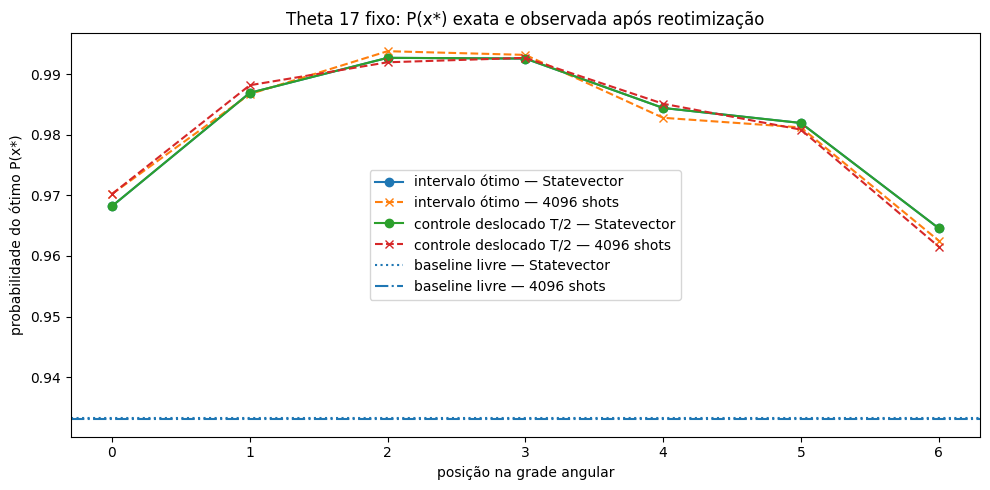

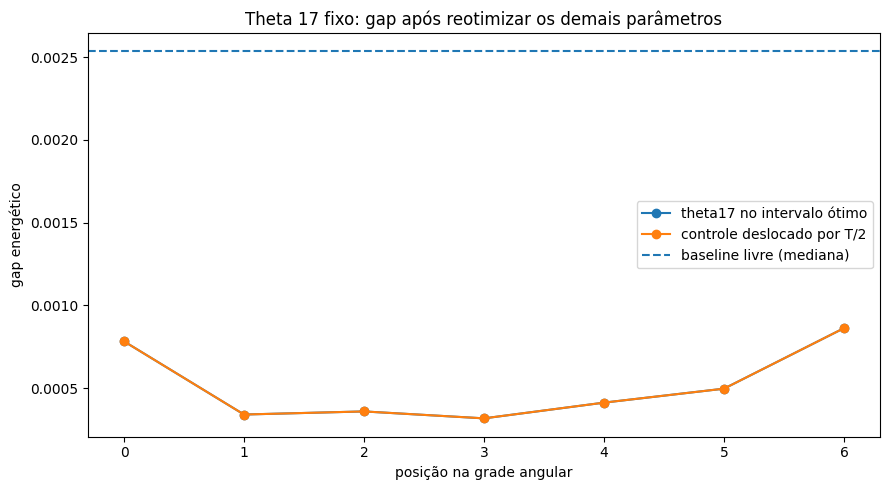

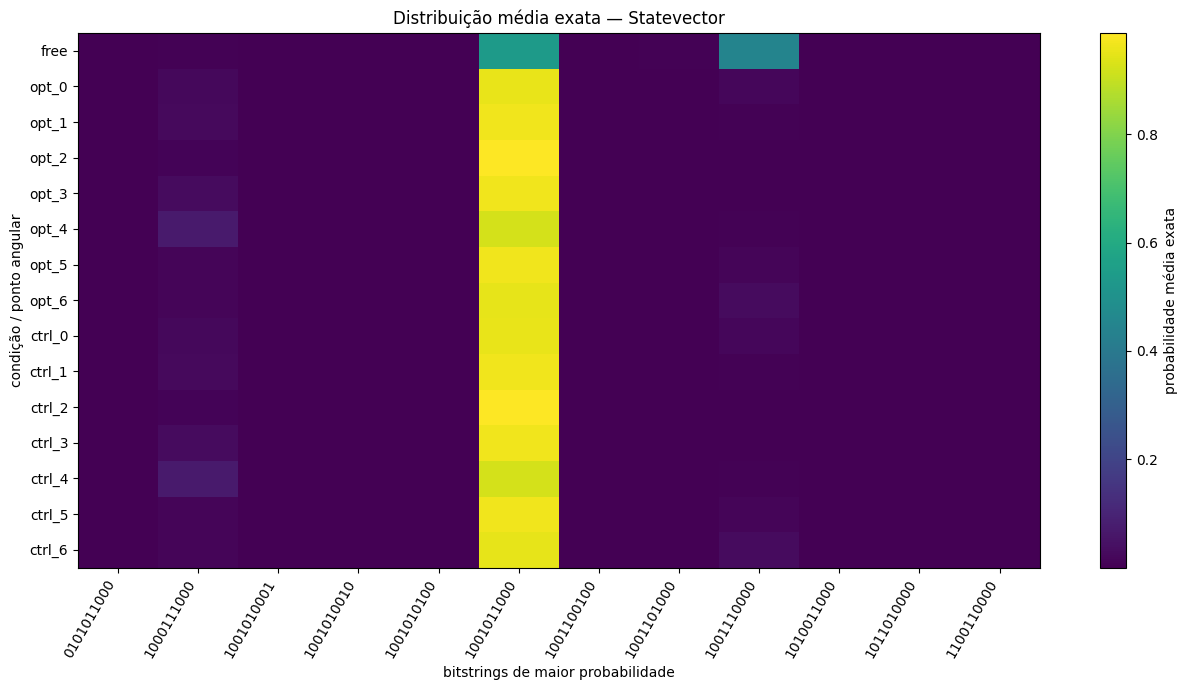

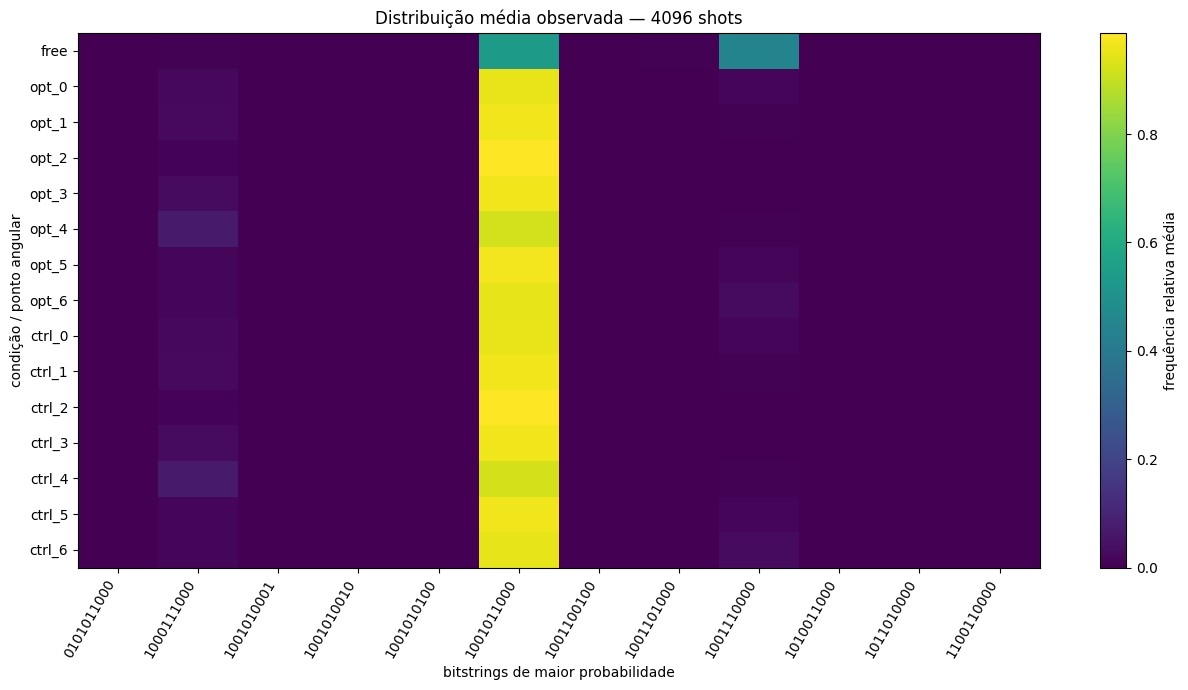

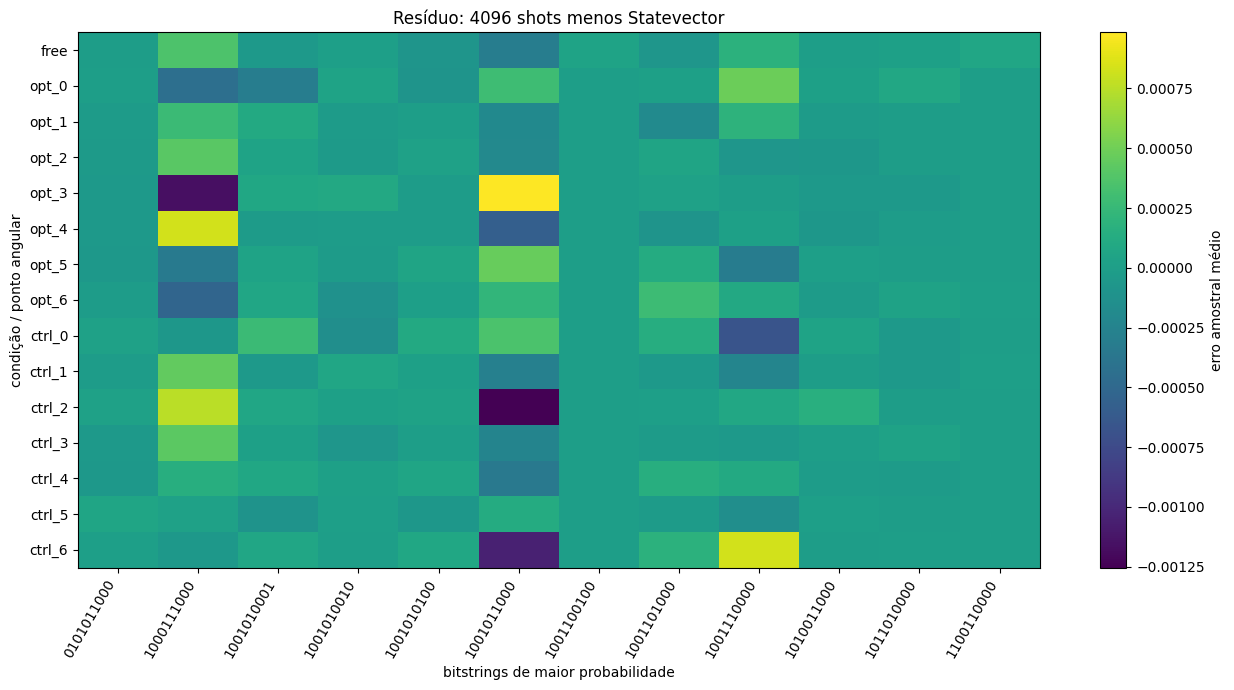

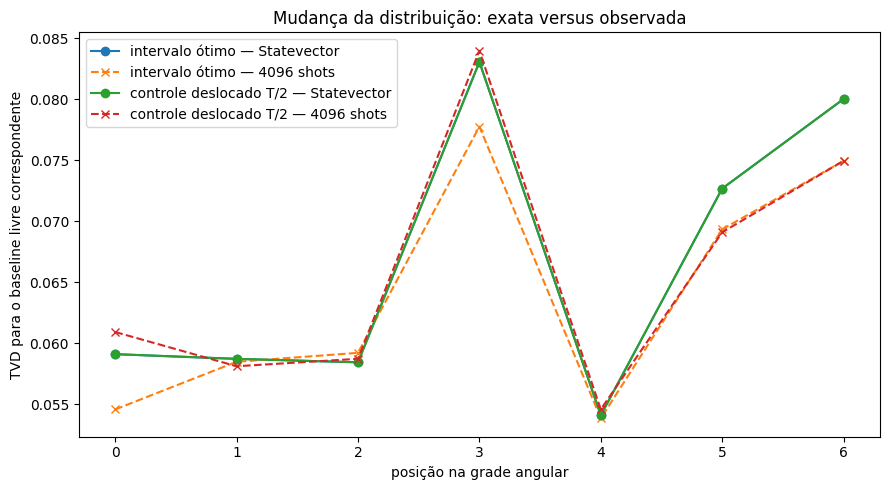

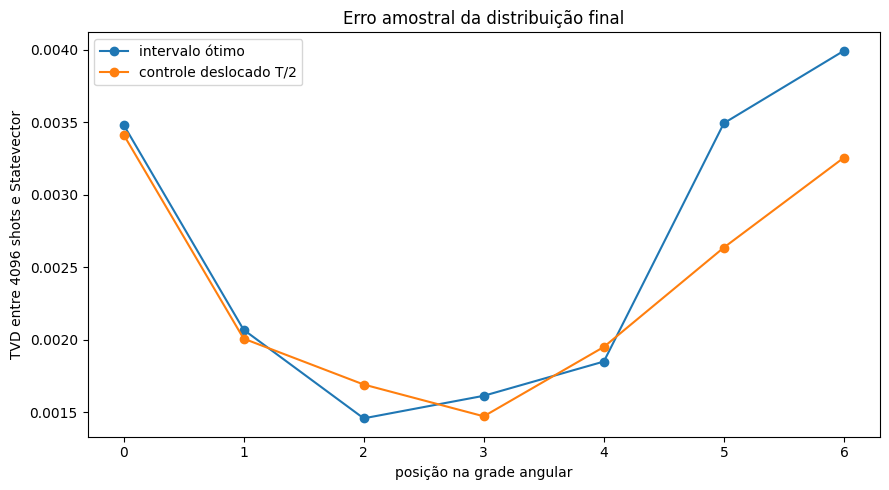

In [30]:
# ============================================================
# 13. THETA_17 FIXO: COBYLA NOS OUTROS PARÂMETROS
# ============================================================

ensure_output_directories()
theta17_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)


def canonical_positive_angle(angle, period):
    return float(np.mod(float(angle), float(period)))


def shortest_circular_arc(angles, period, coverage=0.80, minimum_fraction=0.05):
    """
    Menor arco circular que cobre `coverage` das observações.
    Retorna limites desenrolados; valores físicos são obtidos módulo `period`.
    """
    values = np.sort(np.mod(np.asarray(angles, dtype=float), period))
    if len(values) == 0:
        raise ValueError("Não há ângulos para construir o intervalo.")
    n_cover = max(1, int(np.ceil(float(coverage) * len(values))))
    extended = np.concatenate([values, values + period])
    candidates = []
    for start_index in range(len(values)):
        end_index = start_index + n_cover - 1
        width = float(extended[end_index] - extended[start_index])
        candidates.append((width, start_index, end_index))
    width, start_index, end_index = min(candidates, key=lambda item: item[0])
    start = float(extended[start_index])
    end = float(extended[end_index])
    center = 0.5 * (start + end)

    minimum_width = float(minimum_fraction) * float(period)
    was_expanded = bool(width < minimum_width)
    if was_expanded:
        start = center - 0.5 * minimum_width
        end = center + 0.5 * minimum_width
        width = minimum_width

    return {
        "start_unwrapped": float(start),
        "end_unwrapped": float(end),
        "center_unwrapped": float(0.5 * (start + end)),
        "start": canonical_positive_angle(start, period),
        "end": canonical_positive_angle(end, period),
        "center": canonical_positive_angle(0.5 * (start + end), period),
        "width": float(width),
        "coverage": float(coverage),
        "n_input": int(len(values)),
        "n_covered": int(n_cover),
        "minimum_width_applied": was_expanded,
    }


def select_theta17_optimal_rows(bank_df):
    required = {
        "best_parameters",
        "p_exact_eval",
        "gap_exact_eval",
        "status",
    }
    missing = sorted(required - set(bank_df.columns))
    if missing:
        raise RuntimeError(f"Banco k=4 sem colunas necessárias: {missing}")

    valid = (
        bank_df.loc[bank_df["status"].eq("ok")]
        .dropna(subset=["p_exact_eval", "gap_exact_eval"])
        .copy()
    )
    if len(valid) < THETA17_MIN_OPTIMAL_ROWS:
        raise RuntimeError(
            "O experimento de theta_17 requer ao menos "
            f"{THETA17_MIN_OPTIMAL_ROWS} execuções válidas no banco k=4; "
            f"foram encontradas {len(valid)}."
        )

    p_threshold = float(valid["p_exact_eval"].quantile(1.0 - THETA17_OPTIMAL_QUANTILE))
    gap_threshold = float(valid["gap_exact_eval"].quantile(THETA17_OPTIMAL_QUANTILE))
    selected = valid.loc[
        valid["p_exact_eval"].ge(p_threshold)
        & valid["gap_exact_eval"].le(gap_threshold)
    ].copy()

    fallback_used = False
    if len(selected) < THETA17_MIN_OPTIMAL_ROWS:
        fallback_used = True
        selected = (
            valid.sort_values(
                ["p_exact_eval", "gap_exact_eval"],
                ascending=[False, True],
            )
            .head(THETA17_MIN_OPTIMAL_ROWS)
            .copy()
        )

    return selected, {
        "n_valid_bank_rows": int(len(valid)),
        "n_selected_rows": int(len(selected)),
        "p_exact_threshold": p_threshold,
        "gap_threshold": gap_threshold,
        "fallback_lexicographic_used": bool(fallback_used),
    }


def exact_distribution_metrics(context, theta):
    """
    Calcula a distribuição ideal do circuito final:

        P_exact(x) = |<x|psi(theta)>|^2.

    Também calcula:

        E_exact(theta) = <psi(theta)|H_C|psi(theta)> + offset
        P_exact(x*)    = soma das probabilidades dos bitstrings ótimos.

    Nenhum shot é usado nesta função.
    """
    theta = np.asarray(theta, dtype=float).reshape(-1)
    assigned = context["ansatz"].assign_parameters(theta, inplace=False)
    state = Statevector.from_instruction(assigned)
    probabilities = np.asarray(state.probabilities(), dtype=float)
    probabilities = probabilities / max(float(probabilities.sum()), np.finfo(float).eps)
    labels = np.asarray(
        [format(index, f"0{context['n']}b") for index in range(len(probabilities))],
        dtype=object,
    )
    energy = float(np.real(state.expectation_value(context["ising"])) + context["offset"])
    optimal_set = set(context["exact_bitstrings"])
    optimal_mask = np.asarray([label in optimal_set for label in labels], dtype=bool)
    p_opt = float(probabilities[optimal_mask].sum())
    dominant_index = int(np.argmax(probabilities))
    nonzero = probabilities[probabilities > 0.0]
    entropy = float(-np.sum(nonzero * np.log(nonzero)))
    participation_ratio = float(1.0 / np.sum(probabilities ** 2))
    return {
        "probability_vector": probabilities,  # alias legado: distribuição exata
        "probability_vector_exact": probabilities,
        "bitstring_labels": labels,
        "energy_exact_eval": energy,
        "gap_exact_eval": abs(energy - context["exact_energy"]),
        "p_exact_eval": p_opt,
        "dominant_bitstring_exact_eval": str(labels[dominant_index]),
        "dominant_probability_exact_eval": float(probabilities[dominant_index]),
        "is_exact_dominant_eval": bool(labels[dominant_index] in optimal_set),
        "entropy": entropy,
        "normalized_entropy": float(entropy / np.log(len(probabilities))),
        "participation_ratio": participation_ratio,
    }



def sampled_distribution_metrics(context, theta, shots, seed_simulator):
    """
    Mede o circuito final e calcula a distribuição observada:

        P_hat(x) = N_x / N_shots,

    em que N_x é a contagem do bitstring x.

    Essa distribuição contém flutuação amostral e deve ser comparada com
    a distribuição exata do Statevector.
    """
    theta = np.asarray(theta, dtype=float).reshape(-1)
    assigned = context["ansatz"].assign_parameters(theta, inplace=False)
    measured = assigned.copy()
    measured.measure_all()

    start = perf_counter()
    raw_counts = (
        context["simulator"].run(
            measured,
            shots=int(shots),
            seed_simulator=int(seed_simulator),
        )
        .result()
        .get_counts()
    )
    elapsed = perf_counter() - start

    counts = {
        str(bitstring).replace(" ", ""): int(count)
        for bitstring, count in raw_counts.items()
    }
    labels = np.asarray(
        [format(index, f"0{context['n']}b") for index in range(2 ** context["n"])],
        dtype=object,
    )
    total = max(int(sum(counts.values())), 1)
    probabilities = np.asarray(
        [counts.get(str(label), 0) / total for label in labels],
        dtype=float,
    )
    probabilities = probabilities / max(
        float(probabilities.sum()), np.finfo(float).eps
    )

    optimal_set = set(context["exact_bitstrings"])
    optimal_mask = np.asarray([label in optimal_set for label in labels], dtype=bool)
    p_opt = float(probabilities[optimal_mask].sum())
    dominant_index = int(np.argmax(probabilities))
    nonzero = probabilities[probabilities > 0.0]
    entropy = float(-np.sum(nonzero * np.log(nonzero)))
    participation_ratio = float(1.0 / np.sum(probabilities ** 2))

    return {
        "probability_vector_shots": probabilities,
        "counts_shots": counts,
        "distribution_shots": int(total),
        "measurement_seed": int(seed_simulator),
        "simulator_time_shots": float(elapsed),
        "p_opt_shots": p_opt,
        "dominant_bitstring_shots": str(labels[dominant_index]),
        "dominant_probability_shots": float(probabilities[dominant_index]),
        "is_exact_dominant_shots": bool(labels[dominant_index] in optimal_set),
        "entropy_shots": entropy,
        "normalized_entropy_shots": float(entropy / np.log(len(probabilities))),
        "participation_ratio_shots": participation_ratio,
    }


def total_variation_distance(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    return float(0.5 * np.abs(p - q).sum())


def jensen_shannon_divergence(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    midpoint = 0.5 * (p + q)

    def kl_divergence(a, b):
        mask = a > 0.0
        return float(np.sum(a[mask] * np.log(a[mask] / b[mask])))

    return float(
        0.5 * kl_divergence(p, midpoint)
        + 0.5 * kl_divergence(q, midpoint)
    )


def run_cobyla_with_theta_constraint(
    context,
    initial_theta,
    run_index,
    condition,
    fixed_theta_value=np.nan,
):
    initial_theta = np.asarray(initial_theta, dtype=float).reshape(-1).copy()
    if len(initial_theta) != context["n_parameters"]:
        raise ValueError("Dimensão do ponto inicial incompatível com o ansatz.")

    is_fixed = condition != "free_baseline"
    free_indices = np.asarray(
        [index for index in range(context["n_parameters"]) if index != THETA17_INDEX],
        dtype=int,
    )
    history = []

    if is_fixed:
        theta_fixed = float(fixed_theta_value)
        initial_theta[THETA17_INDEX] = theta_fixed
        x0 = initial_theta[free_indices].copy()

        def unpack(candidate):
            full = initial_theta.copy()
            full[free_indices] = np.asarray(candidate, dtype=float)
            full[THETA17_INDEX] = theta_fixed
            return full
    else:
        x0 = initial_theta.copy()

        def unpack(candidate):
            return np.asarray(candidate, dtype=float).reshape(-1)

    def objective(candidate):
        theta_full = unpack(candidate)
        result = context["estimator"].run(
            pubs=[(context["ansatz"], context["ising"], theta_full)],
            precision=context["estimator_precision"],
        ).result()
        energy = float(
            np.real(np.asarray(result[0].data.evs).reshape(-1)[0])
            + context["offset"]
        )
        history.append(energy)
        return energy

    start = perf_counter()
    result = COBYLA(maxiter=COBYLA_MAXITER).minimize(fun=objective, x0=x0)
    elapsed = perf_counter() - start
    theta_final = unpack(result.x)
    metrics = exact_distribution_metrics(context, theta_final)

    seed_payload = (
        f"{RANDOM_SEED}|{context['problem_id']}|{run_index}|{condition}|"
        f"{float(fixed_theta_value) if is_fixed else 'free'}|{THETA17_DISTRIBUTION_SHOTS}"
    )
    measurement_seed = int(
        hashlib.sha256(seed_payload.encode("utf-8")).hexdigest()[:8], 16
    ) % (2**31 - 1)
    sampled_metrics = sampled_distribution_metrics(
        context=context,
        theta=theta_final,
        shots=THETA17_DISTRIBUTION_SHOTS,
        seed_simulator=measurement_seed,
    )
    sampled_metrics["tvd_shots_vs_exact"] = total_variation_distance(
        sampled_metrics["probability_vector_shots"],
        metrics["probability_vector_exact"],
    )
    sampled_metrics["jsd_shots_vs_exact"] = jensen_shannon_divergence(
        sampled_metrics["probability_vector_shots"],
        metrics["probability_vector_exact"],
    )
    residual = (
        sampled_metrics["probability_vector_shots"]
        - metrics["probability_vector_exact"]
    )
    sampled_metrics["max_abs_probability_error_shots"] = float(
        np.max(np.abs(residual))
    )
    sampled_metrics["rmse_probability_shots"] = float(
        np.sqrt(np.mean(residual ** 2))
    )
    sampled_metrics["p_opt_shots_minus_exact"] = float(
        sampled_metrics["p_opt_shots"] - metrics["p_exact_eval"]
    )

    if is_fixed and not np.isclose(
        theta_final[THETA17_INDEX],
        float(fixed_theta_value),
        atol=1e-12,
        rtol=0.0,
    ):
        raise RuntimeError("theta_17 deixou de permanecer fixo durante a otimização.")

    return {
        "problem_id": context["problem_id"],
        "hamiltonian_id": context["hamiltonian_id"],
        "n": context["n"],
        "k": context["k"],
        "restart": int(run_index),
        "condition": str(condition),
        "fixed_theta_index": int(THETA17_INDEX),
        "fixed_theta_value": (
            float(fixed_theta_value) if is_fixed else np.nan
        ),
        "initial_theta": initial_theta,
        "best_parameters": theta_final,
        "theta17_final": float(theta_final[THETA17_INDEX]),
        "objective_function_value": float(result.fun),
        "nfev": int(len(history)),
        "optimizer_time": float(elapsed),
        "estimator_precision": float(context["estimator_precision"]),
        "estimator_shots_equivalent": int(context["estimator_shots_equivalent"]),
        "status": "ok",
        **metrics,
        **sampled_metrics,
    }


theta17_runs_df = pd.DataFrame()
theta17_summary_df = pd.DataFrame()
theta17_probability_long_df = pd.DataFrame()
theta17_paired_tests_df = pd.DataFrame()
theta17_interval_metadata = {
    "enabled": bool(RUN_THETA17_FIXED_EXPERIMENT),
    "executed": False,
}

if RUN_THETA17_FIXED_EXPERIMENT:
    context = problem_contexts[TARGET_K]
    bank_df = bank_frames[TARGET_K]
    if bank_df.empty:
        raise RuntimeError(
            "O banco k=4 está vazio. Gere ou carregue o banco definitivo antes "
            "de executar o experimento com theta_17 fixo."
        )
    if THETA17_INDEX >= context["n_parameters"]:
        raise RuntimeError(
            f"theta_{THETA17_INDEX} não existe no ansatz k={TARGET_K}."
        )

    parameter_row = (
        context["parameter_map"]
        .loc[lambda df: df["theta_index"].eq(THETA17_INDEX)]
    )
    if len(parameter_row) != 1:
        raise RuntimeError("O mapa físico não identificou theta_17 de forma única.")
    parameter_row = parameter_row.iloc[0]
    theta_period = float(parameter_row["angular_period"])
    theta17_grid_minimum = int(
        parameter_row["fourier_n_grid_minimum"]
    )

    if THETA17_GRID_POINTS < theta17_grid_minimum:
        raise RuntimeError(
            "A grade de theta_17 possui menos pontos que a "
            f"cota teórica: {THETA17_GRID_POINTS} < "
            f"{theta17_grid_minimum}."
        )

    selected_rows, selection_metadata = select_theta17_optimal_rows(bank_df)
    theta17_optimal_values = np.asarray(
        [
            np.asarray(theta, dtype=float)[THETA17_INDEX]
            for theta in selected_rows["best_parameters"]
        ],
        dtype=float,
    )
    interval = shortest_circular_arc(
        theta17_optimal_values,
        period=theta_period,
        coverage=THETA17_INTERVAL_COVERAGE,
        minimum_fraction=THETA17_MIN_INTERVAL_FRACTION,
    )

    optimal_grid_unwrapped = np.linspace(
        interval["start_unwrapped"],
        interval["end_unwrapped"],
        THETA17_GRID_POINTS,
    )
    optimal_grid = np.mod(optimal_grid_unwrapped, theta_period)
    shifted_grid_unwrapped = optimal_grid_unwrapped + 0.5 * theta_period
    shifted_grid = np.mod(shifted_grid_unwrapped, theta_period)

    experiment_signature_payload = {
        "problem_id": context["problem_id"],
        "theta_index": int(THETA17_INDEX),
        "optimal_grid": [float(v) for v in optimal_grid],
        "shifted_control_grid": [float(v) for v in shifted_grid],
        "restarts": int(THETA17_RESTARTS),
        "cobyla_maxiter": int(COBYLA_MAXITER),
        "distribution_shots": int(THETA17_DISTRIBUTION_SHOTS),
        "estimator_precision": float(ESTIMATOR_PRECISION),
        "schema_version": "v20_exact_plus_shots",
    }
    experiment_signature = hashlib.sha256(
        json.dumps(
            experiment_signature_payload,
            sort_keys=True,
            ensure_ascii=False,
        ).encode("utf-8")
    ).hexdigest()[:12]

    theta17_interval_metadata = {
        "enabled": True,
        "executed": True,
        "experiment_signature": experiment_signature,
        "theta_index": int(THETA17_INDEX),
        "ansatz_gate_type": str(parameter_row["ansatz_gate_type"]),
        "primitive_physical_type": str(
            parameter_row["primitive_physical_type"]
        ),
        "primitive_parameter_qubits": tuple(
            int(v)
            for v in parameter_row[
                "primitive_parameter_qubits"
            ]
        ),
        "logical_block_qubits": tuple(
            int(v)
            for v in parameter_row[
                "logical_block_qubits"
            ]
        ),
        "physical_qubits": tuple(
            int(v)
            for v in parameter_row["physical_qubits"]
        ),
        "angular_period": theta_period,
        "fourier_n_grid_minimum": int(
            theta17_grid_minimum
        ),
        "grid_points_used": int(
            THETA17_GRID_POINTS
        ),
        "first_instruction": int(
            parameter_row["first_instruction"]
        ),
        "last_instruction": int(
            parameter_row["last_instruction"]
        ),
        "selection": selection_metadata,
        "interval": interval,
        "optimal_grid": [float(v) for v in optimal_grid],
        "shifted_control_grid": [float(v) for v in shifted_grid],
        "restarts": int(THETA17_RESTARTS),
        "cobyla_maxiter": int(COBYLA_MAXITER),
        "distribution_shots": int(THETA17_DISTRIBUTION_SHOTS),
        "estimator_precision": float(ESTIMATOR_PRECISION),
        "distribution_outputs": ["statevector_exact", "sampled_4096_shots"],
    }

    checkpoint_path = (
        theta17_dir
        / f"theta17_fixed_rows_{experiment_signature}.pkl"
    )
    if checkpoint_path.exists():
        checkpoint_rows = pd.read_pickle(checkpoint_path)
        rows = checkpoint_rows if isinstance(checkpoint_rows, list) else []
    else:
        rows = []

    completed = {
        (
            str(row["condition"]),
            int(row["restart"]),
            int(row.get("grid_index", -1)),
        )
        for row in rows
        if row.get("status") == "ok"
    }

    for restart in range(THETA17_RESTARTS):
        rng = np.random.default_rng(
            RANDOM_SEED + 7_000_000 + 1000 * TARGET_K + restart
        )
        common_initial = 0.5 * np.pi * rng.random(context["n_parameters"])
        common_initial[THETA17_INDEX] = float(interval["center"])

        baseline_key = ("free_baseline", restart, -1)
        if baseline_key not in completed:
            row = run_cobyla_with_theta_constraint(
                context=context,
                initial_theta=common_initial,
                run_index=restart,
                condition="free_baseline",
            )
            row["grid_index"] = -1
            row["grid_position"] = np.nan
            row["fixed_theta_unwrapped"] = np.nan
            rows.append(row)
            pd.to_pickle(rows, checkpoint_path)
            completed.add(baseline_key)
            print(
                f"theta17 baseline restart={restart + 1}/{THETA17_RESTARTS} "
                f"p*={row['p_exact_eval']:.4f} gap={row['gap_exact_eval']:.3e}"
            )

        for grid_index, (value, unwrapped) in enumerate(
            zip(optimal_grid, optimal_grid_unwrapped)
        ):
            key = ("fixed_optimal_interval", restart, grid_index)
            if key in completed:
                continue
            row = run_cobyla_with_theta_constraint(
                context=context,
                initial_theta=common_initial,
                run_index=restart,
                condition="fixed_optimal_interval",
                fixed_theta_value=float(value),
            )
            row["grid_index"] = int(grid_index)
            row["grid_position"] = float(
                grid_index / max(THETA17_GRID_POINTS - 1, 1)
            )
            row["fixed_theta_unwrapped"] = float(unwrapped)
            rows.append(row)
            pd.to_pickle(rows, checkpoint_path)
            completed.add(key)

        for grid_index, (value, unwrapped) in enumerate(
            zip(shifted_grid, shifted_grid_unwrapped)
        ):
            key = ("fixed_shifted_control", restart, grid_index)
            if key in completed:
                continue
            row = run_cobyla_with_theta_constraint(
                context=context,
                initial_theta=common_initial,
                run_index=restart,
                condition="fixed_shifted_control",
                fixed_theta_value=float(value),
            )
            row["grid_index"] = int(grid_index)
            row["grid_position"] = float(
                grid_index / max(THETA17_GRID_POINTS - 1, 1)
            )
            row["fixed_theta_unwrapped"] = float(unwrapped)
            rows.append(row)
            pd.to_pickle(rows, checkpoint_path)
            completed.add(key)

        print(
            f"theta17 restart {restart + 1}/{THETA17_RESTARTS} concluído."
        )

    theta17_runs_df = (
        pd.DataFrame(rows)
        .loc[lambda df: df["status"].eq("ok")]
        .drop_duplicates(
            subset=["condition", "restart", "grid_index"],
            keep="last",
        )
        .sort_values(["condition", "grid_index", "restart"])
        .reset_index(drop=True)
    )

    baseline_vectors_exact = {
        int(row["restart"]): np.asarray(row["probability_vector_exact"], dtype=float)
        for _, row in theta17_runs_df.loc[
            theta17_runs_df["condition"].eq("free_baseline")
        ].iterrows()
    }
    baseline_vectors_shots = {
        int(row["restart"]): np.asarray(row["probability_vector_shots"], dtype=float)
        for _, row in theta17_runs_df.loc[
            theta17_runs_df["condition"].eq("free_baseline")
        ].iterrows()
    }
    theta17_runs_df["tvd_exact_vs_free_baseline"] = theta17_runs_df.apply(
        lambda row: (
            0.0
            if row["condition"] == "free_baseline"
            else total_variation_distance(
                row["probability_vector_exact"],
                baseline_vectors_exact[int(row["restart"])],
            )
        ),
        axis=1,
    )
    theta17_runs_df["jsd_exact_vs_free_baseline"] = theta17_runs_df.apply(
        lambda row: (
            0.0
            if row["condition"] == "free_baseline"
            else jensen_shannon_divergence(
                row["probability_vector_exact"],
                baseline_vectors_exact[int(row["restart"])],
            )
        ),
        axis=1,
    )
    theta17_runs_df["tvd_shots_vs_free_baseline"] = theta17_runs_df.apply(
        lambda row: (
            0.0
            if row["condition"] == "free_baseline"
            else total_variation_distance(
                row["probability_vector_shots"],
                baseline_vectors_shots[int(row["restart"])],
            )
        ),
        axis=1,
    )
    theta17_runs_df["jsd_shots_vs_free_baseline"] = theta17_runs_df.apply(
        lambda row: (
            0.0
            if row["condition"] == "free_baseline"
            else jensen_shannon_divergence(
                row["probability_vector_shots"],
                baseline_vectors_shots[int(row["restart"])],
            )
        ),
        axis=1,
    )
    # aliases legados passam a representar a distribuição exata.
    theta17_runs_df["tvd_vs_free_baseline"] = theta17_runs_df[
        "tvd_exact_vs_free_baseline"
    ]
    theta17_runs_df["jsd_vs_free_baseline"] = theta17_runs_df[
        "jsd_exact_vs_free_baseline"
    ]

    theta17_summary_df = (
        theta17_runs_df.groupby(
            ["condition", "grid_index", "fixed_theta_value"],
            dropna=False,
        )
        .agg(
            n=("restart", "nunique"),
            p_exact_median=("p_exact_eval", "median"),
            p_exact_q25=("p_exact_eval", lambda s: float(s.quantile(0.25))),
            p_exact_q75=("p_exact_eval", lambda s: float(s.quantile(0.75))),
            p_shots_median=("p_opt_shots", "median"),
            p_shots_q25=("p_opt_shots", lambda s: float(s.quantile(0.25))),
            p_shots_q75=("p_opt_shots", lambda s: float(s.quantile(0.75))),
            p_shots_minus_exact_median=("p_opt_shots_minus_exact", "median"),
            gap_median=("gap_exact_eval", "median"),
            gap_q25=("gap_exact_eval", lambda s: float(s.quantile(0.25))),
            gap_q75=("gap_exact_eval", lambda s: float(s.quantile(0.75))),
            entropy_median=("normalized_entropy", "median"),
            entropy_shots_median=("normalized_entropy_shots", "median"),
            participation_ratio_median=("participation_ratio", "median"),
            participation_ratio_shots_median=("participation_ratio_shots", "median"),
            tvd_median=("tvd_exact_vs_free_baseline", "median"),
            jsd_median=("jsd_exact_vs_free_baseline", "median"),
            tvd_shots_vs_baseline_median=("tvd_shots_vs_free_baseline", "median"),
            jsd_shots_vs_baseline_median=("jsd_shots_vs_free_baseline", "median"),
            tvd_shots_vs_exact_median=("tvd_shots_vs_exact", "median"),
            jsd_shots_vs_exact_median=("jsd_shots_vs_exact", "median"),
            max_abs_probability_error_shots_median=("max_abs_probability_error_shots", "median"),
            rmse_probability_shots_median=("rmse_probability_shots", "median"),
            exact_dominant_rate=("is_exact_dominant_eval", "mean"),
            shots_dominant_rate=("is_exact_dominant_shots", "mean"),
            nfev_median=("nfev", "median"),
            optimizer_time_median=("optimizer_time", "median"),
        )
        .reset_index()
    )

    # Comparações pareadas usam uma média por restart sobre a grade,
    # evitando tratar os sete pontos como réplicas independentes.
    per_restart = (
        theta17_runs_df.groupby(["condition", "restart"])
        .agg(
            p_exact=("p_exact_eval", "mean"),
            p_shots=("p_opt_shots", "mean"),
            gap=("gap_exact_eval", "mean"),
            exact_dominant_rate=("is_exact_dominant_eval", "mean"),
            shots_dominant_rate=("is_exact_dominant_shots", "mean"),
            entropy_exact=("normalized_entropy", "mean"),
            entropy_shots=("normalized_entropy_shots", "mean"),
            tvd_exact=("tvd_exact_vs_free_baseline", "mean"),
            tvd_shots=("tvd_shots_vs_free_baseline", "mean"),
            tvd_shots_vs_exact=("tvd_shots_vs_exact", "mean"),
        )
        .reset_index()
    )
    paired_wide = per_restart.pivot(
        index="restart",
        columns="condition",
    )

    def paired_wilcoxon(metric, left, right):
        left_values = paired_wide[(metric, left)].to_numpy(dtype=float)
        right_values = paired_wide[(metric, right)].to_numpy(dtype=float)
        difference = left_values - right_values
        try:
            statistic, p_value = wilcoxon(
                left_values,
                right_values,
                alternative="two-sided",
                zero_method="wilcox",
            )
        except ValueError:
            statistic, p_value = np.nan, 1.0
        return {
            "metric": metric,
            "left_condition": left,
            "right_condition": right,
            "n_pairs": int(len(difference)),
            "median_left": float(np.median(left_values)),
            "median_right": float(np.median(right_values)),
            "median_difference_left_minus_right": float(np.median(difference)),
            "wilcoxon_statistic": float(statistic) if np.isfinite(statistic) else np.nan,
            "wilcoxon_p_value": float(p_value),
        }

    paired_rows = []
    for metric in [
        "p_exact",
        "p_shots",
        "gap",
        "exact_dominant_rate",
        "shots_dominant_rate",
        "entropy_exact",
        "entropy_shots",
        "tvd_shots_vs_exact",
    ]:
        paired_rows.append(
            paired_wilcoxon(
                metric,
                "fixed_optimal_interval",
                "fixed_shifted_control",
            )
        )
        paired_rows.append(
            paired_wilcoxon(
                metric,
                "fixed_optimal_interval",
                "free_baseline",
            )
        )
    theta17_paired_tests_df = pd.DataFrame(paired_rows)

    # Distribuição média completa por condição e ponto da grade:
    # Statevector exato, 4096 shots e resíduo amostral.
    distribution_rows = []
    for (condition, grid_index), group in theta17_runs_df.groupby(
        ["condition", "grid_index"],
        dropna=False,
    ):
        mean_probability_exact = np.mean(
            np.stack(group["probability_vector_exact"].to_list()),
            axis=0,
        )
        mean_probability_shots = np.mean(
            np.stack(group["probability_vector_shots"].to_list()),
            axis=0,
        )
        labels = group.iloc[0]["bitstring_labels"]
        fixed_value = group["fixed_theta_value"].iloc[0]
        for bitstring, probability_exact, probability_shots in zip(
            labels,
            mean_probability_exact,
            mean_probability_shots,
        ):
            distribution_rows.append({
                "condition": condition,
                "grid_index": int(grid_index),
                "fixed_theta_value": (
                    float(fixed_value) if pd.notna(fixed_value) else np.nan
                ),
                "bitstring": str(bitstring),
                "mean_probability": float(probability_exact),  # alias legado
                "mean_probability_exact": float(probability_exact),
                "mean_probability_shots": float(probability_shots),
                "mean_count_shots": float(
                    probability_shots * THETA17_DISTRIBUTION_SHOTS
                ),
                "mean_residual_shots_minus_exact": float(
                    probability_shots - probability_exact
                ),
                "is_exact_bitstring": bool(
                    bitstring in set(context["exact_bitstrings"])
                ),
                "is_valid_dicke_bitstring": bool(
                    str(bitstring).count("1") == TARGET_K
                ),
            })
    theta17_probability_long_df = pd.DataFrame(distribution_rows)

    display(theta17_interval_metadata)
    display(theta17_summary_df)
    display(theta17_paired_tests_df)

    # ---------- Figuras ----------
    baseline_p_exact = float(
        theta17_runs_df.loc[
            theta17_runs_df["condition"].eq("free_baseline"),
            "p_exact_eval",
        ].median()
    )
    baseline_p_shots = float(
        theta17_runs_df.loc[
            theta17_runs_df["condition"].eq("free_baseline"),
            "p_opt_shots",
        ].median()
    )
    fixed_summary = theta17_summary_df.loc[
        theta17_summary_df["condition"].ne("free_baseline")
    ].copy()

    fig, ax = plt.subplots(figsize=(10, 5))
    for condition, label in [
        ("fixed_optimal_interval", "intervalo ótimo"),
        ("fixed_shifted_control", "controle deslocado T/2"),
    ]:
        subset = fixed_summary.loc[
            fixed_summary["condition"].eq(condition)
        ].sort_values("grid_index")
        ax.plot(
            subset["grid_index"],
            subset["p_exact_median"],
            marker="o",
            label=f"{label} — Statevector",
        )
        ax.plot(
            subset["grid_index"],
            subset["p_shots_median"],
            marker="x",
            linestyle="--",
            label=f"{label} — {THETA17_DISTRIBUTION_SHOTS} shots",
        )
    ax.axhline(
        baseline_p_exact,
        linestyle=":",
        label="baseline livre — Statevector",
    )
    ax.axhline(
        baseline_p_shots,
        linestyle="-.",
        label=f"baseline livre — {THETA17_DISTRIBUTION_SHOTS} shots",
    )
    ax.set_xlabel("posição na grade angular")
    ax.set_ylabel("probabilidade do ótimo P(x*)")
    ax.set_title(
        "Theta 17 fixo: P(x*) exata e observada após reotimização"
    )
    ax.legend()
    fig.tight_layout()
    fig.savefig(figure_dir / "theta17_fixed_probability_exact_vs_shots.png", dpi=180)
    plt.show()

    baseline_gap = float(
        theta17_runs_df.loc[
            theta17_runs_df["condition"].eq("free_baseline"),
            "gap_exact_eval",
        ].median()
    )
    fig, ax = plt.subplots(figsize=(9, 5))
    for condition, label in [
        ("fixed_optimal_interval", "theta17 no intervalo ótimo"),
        ("fixed_shifted_control", "controle deslocado por T/2"),
    ]:
        subset = fixed_summary.loc[
            fixed_summary["condition"].eq(condition)
        ].sort_values("grid_index")
        ax.plot(
            subset["grid_index"],
            subset["gap_median"],
            marker="o",
            label=label,
        )
    ax.axhline(baseline_gap, linestyle="--", label="baseline livre (mediana)")
    ax.set_xlabel("posição na grade angular")
    ax.set_ylabel("gap energético")
    ax.set_title("Theta 17 fixo: gap após reotimizar os demais parâmetros")
    ax.legend()
    fig.tight_layout()
    fig.savefig(figure_dir / "theta17_fixed_gap.png", dpi=180)
    plt.show()

    # Seleciona bitstrings com maior probabilidade em qualquer uma das duas leituras.
    top_bitstrings = (
        theta17_probability_long_df.groupby("bitstring")[[
            "mean_probability_exact",
            "mean_probability_shots",
        ]]
        .max()
        .max(axis=1)
        .nlargest(12)
        .index
        .tolist()
    )

    def build_distribution_heatmap(value_column):
        frame = (
            theta17_probability_long_df.loc[
                theta17_probability_long_df["bitstring"].isin(top_bitstrings)
            ]
            .assign(
                row_label=lambda df: df.apply(
                    lambda row: (
                        "free"
                        if row["condition"] == "free_baseline"
                        else (
                            f"opt_{int(row['grid_index'])}"
                            if row["condition"] == "fixed_optimal_interval"
                            else f"ctrl_{int(row['grid_index'])}"
                        )
                    ),
                    axis=1,
                )
            )
            .pivot(index="row_label", columns="bitstring", values=value_column)
            .fillna(0.0)
        )
        preferred_order = (
            ["free"]
            + [f"opt_{i}" for i in range(THETA17_GRID_POINTS)]
            + [f"ctrl_{i}" for i in range(THETA17_GRID_POINTS)]
        )
        return frame.reindex(
            [label for label in preferred_order if label in frame.index]
        )

    for value_column, title, filename, colorbar_label in [
        (
            "mean_probability_exact",
            "Distribuição média exata — Statevector",
            "theta17_probability_heatmap_exact.png",
            "probabilidade média exata",
        ),
        (
            "mean_probability_shots",
            f"Distribuição média observada — {THETA17_DISTRIBUTION_SHOTS} shots",
            "theta17_probability_heatmap_4096shots.png",
            "frequência relativa média",
        ),
        (
            "mean_residual_shots_minus_exact",
            f"Resíduo: {THETA17_DISTRIBUTION_SHOTS} shots menos Statevector",
            "theta17_probability_heatmap_residual.png",
            "erro amostral médio",
        ),
    ]:
        heatmap_df = build_distribution_heatmap(value_column)
        fig, ax = plt.subplots(figsize=(13, 7))
        image = ax.imshow(heatmap_df.to_numpy(dtype=float), aspect="auto")
        ax.set_xticks(np.arange(len(heatmap_df.columns)))
        ax.set_xticklabels(heatmap_df.columns, rotation=60, ha="right")
        ax.set_yticks(np.arange(len(heatmap_df.index)))
        ax.set_yticklabels(heatmap_df.index)
        ax.set_xlabel("bitstrings de maior probabilidade")
        ax.set_ylabel("condição / ponto angular")
        ax.set_title(title)
        fig.colorbar(image, ax=ax, label=colorbar_label)
        fig.tight_layout()
        fig.savefig(figure_dir / filename, dpi=180)
        plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    for condition, label in [
        ("fixed_optimal_interval", "intervalo ótimo"),
        ("fixed_shifted_control", "controle deslocado T/2"),
    ]:
        subset = fixed_summary.loc[
            fixed_summary["condition"].eq(condition)
        ].sort_values("grid_index")
        ax.plot(
            subset["grid_index"],
            subset["tvd_median"],
            marker="o",
            label=f"{label} — Statevector",
        )
        ax.plot(
            subset["grid_index"],
            subset["tvd_shots_vs_baseline_median"],
            marker="x",
            linestyle="--",
            label=f"{label} — {THETA17_DISTRIBUTION_SHOTS} shots",
        )
    ax.set_xlabel("posição na grade angular")
    ax.set_ylabel("TVD para o baseline livre correspondente")
    ax.set_title("Mudança da distribuição: exata versus observada")
    ax.legend()
    fig.tight_layout()
    fig.savefig(figure_dir / "theta17_distribution_tvd_exact_vs_shots.png", dpi=180)
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    for condition, label in [
        ("fixed_optimal_interval", "intervalo ótimo"),
        ("fixed_shifted_control", "controle deslocado T/2"),
    ]:
        subset = fixed_summary.loc[
            fixed_summary["condition"].eq(condition)
        ].sort_values("grid_index")
        ax.plot(
            subset["grid_index"],
            subset["tvd_shots_vs_exact_median"],
            marker="o",
            label=label,
        )
    ax.set_xlabel("posição na grade angular")
    ax.set_ylabel("TVD entre 4096 shots e Statevector")
    ax.set_title("Erro amostral da distribuição final")
    ax.legend()
    fig.tight_layout()
    fig.savefig(figure_dir / "theta17_shots_vs_exact_tvd.png", dpi=180)
    plt.show()
else:
    print(
        "Experimento theta_17 não executado. Defina "
        "RUN_THETA17_FIXED_EXPERIMENT=True depois de carregar/completar o banco k=4."
    )


# Parte VII — Varredura direta de \(\theta_{17}\) sem COBYLA

Este teste usa o banco já produzido, aplica uma máscara de qualidade e mantém somente o percentil superior definido por `THETA17_DIRECT_TOP_FRACTION`.

Com o valor padrão `0.10`, permanecem aproximadamente os **10% melhores vetores** do banco. A qualidade combina:

\[
P(x^*) \text{ alto}
\]

e

\[
E(\boldsymbol{\theta})-E^* \text{ baixo}.
\]

O melhor vetor desse subconjunto é usado como âncora. Todos os parâmetros são congelados, exceto \(\theta_{17}\). Em cada ponto da grade o circuito é apenas reconstruído com:

```python
assigned = context["ansatz"].assign_parameters(theta_test, inplace=False)
```

Nenhuma chamada ao COBYLA, ao Estimator ruidoso ou a qualquer reotimização é feita nesta parte.

A faixa originalmente solicitada, \(0\leq\theta_{17}\leq\pi\), é marcada nas saídas. Como o mapa estrutural identifica período \(2\pi\) para esse parâmetro, a configuração padrão também percorre o período completo para auditar a periodicidade.

As saídas principais são:

- \(P(x^*)\);
- energia esperada e gap;
- massa nos melhores portfólios clássicos;
- entropia dentro do subespaço de Dicke;
- TVD e divergência de Jensen–Shannon em relação ao vetor âncora;
- bitstring dominante e sua posição no ranking clássico;
- mapa de calor da distribuição dos 210 bitstrings válidos, ordenados pela energia clássica.


In [ ]:
# ============================================================
# 14. VARREDURA DIRETA DE THETA_17 — SEM COBYLA
# ============================================================

ensure_output_directories()
theta17_direct_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)


def select_direct_sweep_reference(
    bank_df,
    top_fraction=0.10,
):
    """
    Mantém o percentil superior de qualidade e seleciona uma âncora.

    quality_score = média de:
      1. rank percentual crescente de P(x*);
      2. rank percentual decrescente do gap, de modo que gaps menores
         recebam valores maiores.

    top_fraction=0.10 significa manter aproximadamente os 10% melhores.
    """
    required = {
        "best_parameters",
        "p_exact_eval",
        "gap_exact_eval",
        "status",
    }
    missing = sorted(required - set(bank_df.columns))
    if missing:
        raise RuntimeError(
            "Banco k=4 sem colunas para a varredura direta: "
            f"{missing}"
        )

    top_fraction = float(top_fraction)
    if not 0.0 < top_fraction <= 1.0:
        raise ValueError(
            "THETA17_DIRECT_TOP_FRACTION deve pertencer a (0, 1]."
        )

    valid = (
        bank_df.loc[bank_df["status"].eq("ok")]
        .dropna(
            subset=[
                "best_parameters",
                "p_exact_eval",
                "gap_exact_eval",
            ]
        )
        .copy()
    )
    if valid.empty:
        raise RuntimeError(
            "Não há vetores válidos no banco k=4."
        )

    valid["p_quality_rank"] = valid[
        "p_exact_eval"
    ].rank(
        pct=True,
        method="average",
        ascending=True,
    )
    valid["gap_quality_rank"] = valid[
        "gap_exact_eval"
    ].rank(
        pct=True,
        method="average",
        ascending=False,
    )
    valid["quality_score"] = 0.5 * (
        valid["p_quality_rank"]
        + valid["gap_quality_rank"]
    )

    quality_quantile = float(1.0 - top_fraction)
    quality_threshold = float(
        valid["quality_score"].quantile(
            quality_quantile
        )
    )
    selected = valid.loc[
        valid["quality_score"].ge(
            quality_threshold
        )
    ].copy()

    reference = (
        selected.sort_values(
            [
                "quality_score",
                "p_exact_eval",
                "gap_exact_eval",
            ],
            ascending=[False, False, True],
        )
        .iloc[0]
        .copy()
    )

    metadata = {
        "n_bank_rows": int(len(bank_df)),
        "n_valid_rows": int(len(valid)),
        "top_fraction": top_fraction,
        "quality_quantile": quality_quantile,
        "quality_threshold": quality_threshold,
        "n_selected_rows": int(len(selected)),
        "selected_fraction_realized": float(
            len(selected) / len(valid)
        ),
        "reference_run": (
            int(reference["run"])
            if "run" in reference
            and pd.notna(reference["run"])
            else None
        ),
        "reference_quality_score": float(
            reference["quality_score"]
        ),
        "reference_p_exact": float(
            reference["p_exact_eval"]
        ),
        "reference_gap_exact": float(
            reference["gap_exact_eval"]
        ),
    }
    return valid, selected, reference, metadata


def build_inclusive_grid(start, end, step):
    start = float(start)
    end = float(end)
    step = float(step)
    if step <= 0.0:
        raise ValueError(
            "THETA17_DIRECT_STEP deve ser positivo."
        )
    if end <= start:
        raise ValueError(
            "O fim da grade deve ser maior que o início."
        )

    values = np.arange(
        start,
        end,
        step,
        dtype=float,
    )
    if (
        len(values) == 0
        or not np.isclose(
            values[-1],
            end,
            atol=1e-12,
            rtol=0.0,
        )
    ):
        values = np.append(values, end)
    else:
        values[-1] = end
    return values


def shortest_signed_angle_delta(
    angle,
    reference,
    period,
):
    return float(
        (
            float(angle)
            - float(reference)
            + 0.5 * float(period)
        )
        % float(period)
        - 0.5 * float(period)
    )


theta17_direct_runs_df = pd.DataFrame()
theta17_direct_probability_long_df = pd.DataFrame()
theta17_direct_selected_bank_df = pd.DataFrame()
theta17_direct_metadata = {
    "enabled": bool(
        RUN_THETA17_DIRECT_SWEEP
    ),
    "executed": False,
}

if RUN_THETA17_DIRECT_SWEEP:
    context = problem_contexts[TARGET_K]
    bank_df = bank_frames[TARGET_K]

    if bank_df.empty:
        raise RuntimeError(
            "O banco k=4 está vazio. Gere ou carregue o banco "
            "antes da varredura direta."
        )
    if THETA17_INDEX >= context["n_parameters"]:
        raise RuntimeError(
            f"theta_{THETA17_INDEX} não existe no ansatz "
            f"k={TARGET_K}."
        )

    parameter_row = (
        context["parameter_map"]
        .loc[
            lambda df: df["theta_index"].eq(
                THETA17_INDEX
            )
        ]
    )
    if len(parameter_row) != 1:
        raise RuntimeError(
            "O mapa físico não identificou theta_17 "
            "de forma única."
        )
    parameter_row = parameter_row.iloc[0]
    theta_period = float(
        parameter_row["angular_period"]
    )

    (
        theta17_direct_valid_bank_df,
        theta17_direct_selected_bank_df,
        theta17_reference_row,
        selection_metadata,
    ) = select_direct_sweep_reference(
        bank_df,
        top_fraction=(
            THETA17_DIRECT_TOP_FRACTION
        ),
    )

    if len(
        theta17_direct_valid_bank_df
    ) != int(
        THETA17_DIRECT_EXPECTED_BANK_ROWS
    ):
        warnings.warn(
            "O banco k=4 possui "
            f"{len(theta17_direct_valid_bank_df)} vetores válidos; "
            "o experimento foi configurado esperando "
            f"{THETA17_DIRECT_EXPECTED_BANK_ROWS}. "
            "A varredura continuará com todas as linhas disponíveis."
        )

    theta_reference = np.asarray(
        theta17_reference_row[
            "best_parameters"
        ],
        dtype=float,
    ).reshape(-1)

    if len(theta_reference) != context[
        "n_parameters"
    ]:
        raise RuntimeError(
            "O vetor âncora possui dimensão incompatível "
            "com o ansatz k=4."
        )

    theta17_reference_raw = float(
        theta_reference[THETA17_INDEX]
    )
    theta17_reference_canonical = (
        canonical_positive_angle(
            theta17_reference_raw,
            theta_period,
        )
    )

    requested_end = min(
        float(THETA17_DIRECT_REQUESTED_END),
        theta_period,
    )
    scan_end = (
        theta_period
        if THETA17_DIRECT_SCAN_FULL_PERIOD
        else requested_end
    )
    theta_grid = build_inclusive_grid(
        0.0,
        scan_end,
        THETA17_DIRECT_STEP,
    )

    enumeration_energy_order = (
        context["classical"][
            "enumeration_df"
        ]
        .sort_values(
            [
                "objective",
                "bitstring_qiskit_order",
            ]
        )
        .reset_index(drop=True)
        .copy()
    )
    valid_bitstrings_energy_order = (
        enumeration_energy_order[
            "bitstring_qiskit_order"
        ]
        .astype(str)
        .to_numpy(dtype=object)
    )
    valid_objective_energy_order = (
        enumeration_energy_order[
            "objective"
        ].to_numpy(dtype=float)
    )
    valid_selected_assets_energy_order = (
        enumeration_energy_order[
            "selected_assets"
        ].to_numpy(dtype=object)
    )

    all_labels = np.asarray(
        [
            format(
                index,
                f"0{context['n']}b",
            )
            for index in range(
                2 ** context["n"]
            )
        ],
        dtype=object,
    )
    label_to_index = {
        str(label): int(index)
        for index, label in enumerate(
            all_labels
        )
    }
    valid_probability_indices = np.asarray(
        [
            label_to_index[
                str(bitstring)
            ]
            for bitstring in (
                valid_bitstrings_energy_order
            )
        ],
        dtype=int,
    )
    valid_weight_mask = np.asarray(
        [
            str(label).count("1")
            == TARGET_K
            for label in all_labels
        ],
        dtype=bool,
    )

    energy_lookup_qiskit = {
        str(bitstring): float(objective)
        for bitstring, objective in zip(
            valid_bitstrings_energy_order,
            valid_objective_energy_order,
        )
    }
    rank_lookup_qiskit = {
        str(bitstring): int(rank)
        for rank, bitstring in enumerate(
            valid_bitstrings_energy_order,
            start=1,
        )
    }
    optimal_set = set(
        context["exact_bitstrings"]
    )
    optimal_indices = np.asarray(
        [
            label_to_index[
                str(bitstring)
            ]
            for bitstring in optimal_set
        ],
        dtype=int,
    )
    top_n = min(
        int(
            THETA17_DIRECT_TOP_N_PORTFOLIOS
        ),
        len(valid_probability_indices),
    )
    top_n_indices = (
        valid_probability_indices[:top_n]
    )

    reference_metrics = (
        exact_distribution_metrics(
            context,
            theta_reference,
        )
    )
    reference_probability = np.asarray(
        reference_metrics[
            "probability_vector_exact"
        ],
        dtype=float,
    )

    signature_payload = {
        "problem_id": context["problem_id"],
        "theta_index": int(
            THETA17_INDEX
        ),
        "reference_run": (
            selection_metadata[
                "reference_run"
            ]
        ),
        "reference_theta_hash": (
            hashlib.sha256(
                np.asarray(
                    theta_reference,
                    dtype=np.float64,
                ).tobytes()
            ).hexdigest()[:16]
        ),
        "top_fraction": float(
            THETA17_DIRECT_TOP_FRACTION
        ),
        "grid_start": 0.0,
        "grid_end": float(scan_end),
        "grid_step": float(
            THETA17_DIRECT_STEP
        ),
        "optimizer_used": False,
        "schema_version": (
            "v20_1_direct_theta17"
        ),
    }
    experiment_signature = (
        hashlib.sha256(
            json.dumps(
                signature_payload,
                sort_keys=True,
                ensure_ascii=False,
            ).encode("utf-8")
        ).hexdigest()[:12]
    )

    checkpoint_path = (
        theta17_direct_dir
        / (
            "theta17_direct_rows_"
            f"{experiment_signature}.pkl"
        )
    )
    checkpoint_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    if checkpoint_path.exists():
        checkpoint_rows = pd.read_pickle(
            checkpoint_path
        )
        rows = (
            checkpoint_rows
            if isinstance(
                checkpoint_rows,
                list,
            )
            else []
        )
    else:
        rows = []

    completed_indices = {
        int(row["grid_index"])
        for row in rows
        if row.get("status") == "ok"
    }

    for grid_index, theta17_value in enumerate(
        theta_grid
    ):
        if grid_index in completed_indices:
            continue

        theta_test = theta_reference.copy()
        theta_test[THETA17_INDEX] = float(
            theta17_value
        )

        # Única operação quântica paramétrica desta varredura:
        # nenhum COBYLA e nenhuma reotimização são chamados.
        metrics = exact_distribution_metrics(
            context,
            theta_test,
        )
        probability = np.asarray(
            metrics[
                "probability_vector_exact"
            ],
            dtype=float,
        )
        valid_probability = probability[
            valid_probability_indices
        ]

        valid_mass = float(
            probability[
                valid_weight_mask
            ].sum()
        )
        leakage = max(
            0.0,
            1.0 - valid_mass,
        )

        nonzero_valid = (
            valid_probability[
                valid_probability > 0.0
            ]
        )
        entropy_valid = float(
            -np.sum(
                nonzero_valid
                * np.log(nonzero_valid)
            )
        )
        normalized_entropy_valid = float(
            entropy_valid
            / np.log(
                len(
                    valid_probability_indices
                )
            )
        )
        participation_ratio_valid = (
            float(
                1.0
                / np.sum(
                    valid_probability ** 2
                )
            )
        )

        dominant_bitstring = str(
            metrics[
                "dominant_bitstring_exact_eval"
            ]
        )
        optimal_component_probability = (
            probability[optimal_indices]
        )
        best_optimal_probability = float(
            optimal_component_probability.max()
        )
        optimal_probability_rank = int(
            1
            + np.sum(
                probability
                > (
                    best_optimal_probability
                    + 1e-15
                )
            )
        )

        row = {
            "problem_id": (
                context["problem_id"]
            ),
            "hamiltonian_id": (
                context["hamiltonian_id"]
            ),
            "n": int(context["n"]),
            "k": int(context["k"]),
            "grid_index": int(
                grid_index
            ),
            "theta17_value": float(
                theta17_value
            ),
            "theta17_value_over_pi": float(
                theta17_value / np.pi
            ),
            "within_requested_0_pi": bool(
                theta17_value
                <= requested_end + 1e-12
            ),
            "theta17_reference_raw": (
                theta17_reference_raw
            ),
            "theta17_reference_canonical": (
                theta17_reference_canonical
            ),
            "theta17_delta_shortest": (
                shortest_signed_angle_delta(
                    theta17_value,
                    theta17_reference_canonical,
                    theta_period,
                )
            ),
            "reference_run": (
                selection_metadata[
                    "reference_run"
                ]
            ),
            "reference_quality_score": (
                selection_metadata[
                    "reference_quality_score"
                ]
            ),
            "p_optimal": float(
                metrics["p_exact_eval"]
            ),
            "expected_energy": float(
                metrics[
                    "energy_exact_eval"
                ]
            ),
            "energy_gap": float(
                metrics[
                    "gap_exact_eval"
                ]
            ),
            "p_top_n_classical": float(
                probability[
                    top_n_indices
                ].sum()
            ),
            "top_n_classical": int(
                top_n
            ),
            "dominant_bitstring": (
                dominant_bitstring
            ),
            "dominant_probability": float(
                metrics[
                    "dominant_probability_exact_eval"
                ]
            ),
            "dominant_is_optimal": bool(
                metrics[
                    "is_exact_dominant_eval"
                ]
            ),
            "dominant_objective": float(
                energy_lookup_qiskit.get(
                    dominant_bitstring,
                    np.nan,
                )
            ),
            "dominant_classical_rank": (
                rank_lookup_qiskit.get(
                    dominant_bitstring,
                    np.nan,
                )
            ),
            "optimal_probability_rank": (
                optimal_probability_rank
            ),
            "valid_dicke_mass": (
                valid_mass
            ),
            "leakage_outside_k": (
                leakage
            ),
            "entropy_valid": (
                entropy_valid
            ),
            "normalized_entropy_valid": (
                normalized_entropy_valid
            ),
            "participation_ratio_valid": (
                participation_ratio_valid
            ),
            "tvd_vs_reference": (
                total_variation_distance(
                    probability,
                    reference_probability,
                )
            ),
            "jsd_vs_reference": (
                jensen_shannon_divergence(
                    probability,
                    reference_probability,
                )
            ),
            "probability_vector_exact": (
                probability
            ),
            "valid_probability_energy_order": (
                valid_probability
            ),
            "best_parameters": (
                theta_test
            ),
            "optimizer_used": False,
            "status": "ok",
        }
        rows.append(row)
        completed_indices.add(
            grid_index
        )

        if (
            (grid_index + 1)
            % int(
                THETA17_DIRECT_CHECKPOINT_EVERY
            )
            == 0
        ):
            pd.to_pickle(
                rows,
                checkpoint_path,
            )
            print(
                "varredura direta theta17: "
                f"{grid_index + 1}/"
                f"{len(theta_grid)}"
            )

    pd.to_pickle(
        rows,
        checkpoint_path,
    )

    theta17_direct_runs_df = (
        pd.DataFrame(rows)
        .loc[
            lambda df: df[
                "status"
            ].eq("ok")
        ]
        .drop_duplicates(
            subset=["grid_index"],
            keep="last",
        )
        .sort_values("grid_index")
        .reset_index(drop=True)
    )

    if len(theta17_direct_runs_df) != len(
        theta_grid
    ):
        raise RuntimeError(
            "A varredura direta não contém todos "
            "os pontos esperados."
        )

    probability_matrix = np.stack(
        theta17_direct_runs_df[
            "valid_probability_energy_order"
        ].to_list(),
        axis=0,
    )

    n_grid = len(
        theta17_direct_runs_df
    )
    n_valid = len(
        valid_bitstrings_energy_order
    )
    theta17_direct_probability_long_df = (
        pd.DataFrame({
            "grid_index": np.repeat(
                theta17_direct_runs_df[
                    "grid_index"
                ].to_numpy(dtype=int),
                n_valid,
            ),
            "theta17_value": np.repeat(
                theta17_direct_runs_df[
                    "theta17_value"
                ].to_numpy(dtype=float),
                n_valid,
            ),
            "theta17_value_over_pi": (
                np.repeat(
                    theta17_direct_runs_df[
                        "theta17_value_over_pi"
                    ].to_numpy(dtype=float),
                    n_valid,
                )
            ),
            "energy_rank": np.tile(
                np.arange(
                    1,
                    n_valid + 1,
                    dtype=int,
                ),
                n_grid,
            ),
            "bitstring_qiskit_order": np.tile(
                valid_bitstrings_energy_order,
                n_grid,
            ),
            "objective": np.tile(
                valid_objective_energy_order,
                n_grid,
            ),
            "probability": (
                probability_matrix.reshape(-1)
            ),
            "is_optimal": np.tile(
                np.asarray(
                    [
                        bitstring
                        in optimal_set
                        for bitstring in (
                            valid_bitstrings_energy_order
                        )
                    ],
                    dtype=bool,
                ),
                n_grid,
            ),
        })
    )

    start_row = (
        theta17_direct_runs_df.iloc[0]
    )
    end_row = (
        theta17_direct_runs_df.iloc[-1]
    )
    periodicity_audit_direct = {
        "full_period_scanned": bool(
            THETA17_DIRECT_SCAN_FULL_PERIOD
        ),
        "theta_start": float(
            start_row["theta17_value"]
        ),
        "theta_end": float(
            end_row["theta17_value"]
        ),
        "tvd_start_vs_end": float(
            total_variation_distance(
                start_row[
                    "probability_vector_exact"
                ],
                end_row[
                    "probability_vector_exact"
                ],
            )
        ),
        "absolute_energy_difference": float(
            abs(
                start_row[
                    "expected_energy"
                ]
                - end_row[
                    "expected_energy"
                ]
            )
        ),
        "absolute_p_optimal_difference": float(
            abs(
                start_row["p_optimal"]
                - end_row["p_optimal"]
            )
        ),
    }

    theta17_direct_metadata = {
        "enabled": True,
        "executed": True,
        "experiment_signature": (
            experiment_signature
        ),
        "optimizer_used": False,
        "cobyla_calls": 0,
        "theta_index": int(
            THETA17_INDEX
        ),
        "ansatz_gate_type": str(
            parameter_row[
                "ansatz_gate_type"
            ]
        ),
        "primitive_physical_type": str(
            parameter_row[
                "primitive_physical_type"
            ]
        ),
        "logical_block_qubits": tuple(
            int(value)
            for value in parameter_row[
                "logical_block_qubits"
            ]
        ),
        "angular_period": (
            theta_period
        ),
        "requested_interval": [
            0.0,
            float(requested_end),
        ],
        "scan_interval": [
            0.0,
            float(scan_end),
        ],
        "step": float(
            THETA17_DIRECT_STEP
        ),
        "n_grid_points": int(
            len(theta_grid)
        ),
        "selection": (
            selection_metadata
        ),
        "reference_theta17_raw": (
            theta17_reference_raw
        ),
        "reference_theta17_canonical": (
            theta17_reference_canonical
        ),
        "reference_metrics": {
            "p_optimal": float(
                reference_metrics[
                    "p_exact_eval"
                ]
            ),
            "expected_energy": float(
                reference_metrics[
                    "energy_exact_eval"
                ]
            ),
            "energy_gap": float(
                reference_metrics[
                    "gap_exact_eval"
                ]
            ),
            "dominant_bitstring": str(
                reference_metrics[
                    "dominant_bitstring_exact_eval"
                ]
            ),
        },
        "n_valid_dicke_bitstrings": int(
            n_valid
        ),
        "top_n_classical": int(
            top_n
        ),
        "periodicity_audit": (
            periodicity_audit_direct
        ),
        "checkpoint_path": str(
            checkpoint_path.resolve()
        ),
    }

    display(
        theta17_direct_selected_bank_df[[
            "run",
            "p_exact_eval",
            "gap_exact_eval",
            "p_quality_rank",
            "gap_quality_rank",
            "quality_score",
        ]]
        .sort_values(
            "quality_score",
            ascending=False,
        )
        .head(20)
    )
    display(
        theta17_direct_runs_df.drop(
            columns=[
                "probability_vector_exact",
                "valid_probability_energy_order",
                "best_parameters",
            ],
            errors="ignore",
        ).head()
    )
    print(
        json.dumps(
            theta17_direct_metadata,
            indent=2,
            ensure_ascii=False,
        )
    )

    # ---------- Figura 1: intervalo solicitado 0 a pi ----------
    requested_subset = (
        theta17_direct_runs_df.loc[
            theta17_direct_runs_df[
                "within_requested_0_pi"
            ]
        ]
    )
    fig, ax = plt.subplots(
        figsize=(10, 5)
    )
    ax.plot(
        requested_subset[
            "theta17_value"
        ],
        requested_subset[
            "p_optimal"
        ],
        label="P(x*)",
    )
    ax.plot(
        requested_subset[
            "theta17_value"
        ],
        requested_subset[
            "p_top_n_classical"
        ],
        label=(
            "massa nos "
            f"{top_n} melhores"
        ),
    )
    if (
        0.0
        <= theta17_reference_canonical
        <= requested_end
    ):
        ax.axvline(
            theta17_reference_canonical,
            linestyle="--",
            label="theta17 da âncora",
        )
    ax.set_xlabel(
        "theta17 em radianos"
    )
    ax.set_ylabel(
        "probabilidade"
    )
    ax.set_title(
        "Varredura direta de theta17 — "
        "intervalo solicitado [0, pi]"
    )
    ax.legend()
    fig.tight_layout()
    fig.savefig(
        figure_dir
        / (
            "theta17_direct_probability_"
            "0_to_pi.png"
        ),
        dpi=180,
    )
    plt.show()

    # ---------- Figura 2: período completo ----------
    fig, ax = plt.subplots(
        figsize=(10, 5)
    )
    ax.plot(
        theta17_direct_runs_df[
            "theta17_value"
        ],
        theta17_direct_runs_df[
            "p_optimal"
        ],
        label="P(x*)",
    )
    ax.plot(
        theta17_direct_runs_df[
            "theta17_value"
        ],
        theta17_direct_runs_df[
            "p_top_n_classical"
        ],
        label=(
            "massa nos "
            f"{top_n} melhores"
        ),
    )
    ax.axvline(
        theta17_reference_canonical,
        linestyle="--",
        label="theta17 da âncora",
    )
    ax.set_xlabel(
        "theta17 em radianos"
    )
    ax.set_ylabel(
        "probabilidade"
    )
    ax.set_title(
        "Varredura direta de theta17 — "
        "período estrutural"
    )
    ax.legend()
    fig.tight_layout()
    fig.savefig(
        figure_dir
        / (
            "theta17_direct_probability_"
            "full_period.png"
        ),
        dpi=180,
    )
    plt.show()

    # ---------- Figura 3: energia e gap ----------
    fig, ax = plt.subplots(
        figsize=(10, 5)
    )
    ax.plot(
        theta17_direct_runs_df[
            "theta17_value"
        ],
        theta17_direct_runs_df[
            "energy_gap"
        ],
    )
    ax.axvline(
        theta17_reference_canonical,
        linestyle="--",
    )
    ax.set_xlabel(
        "theta17 em radianos"
    )
    ax.set_ylabel(
        "gap energético"
    )
    ax.set_title(
        "Gap sem reotimização dos demais parâmetros"
    )
    fig.tight_layout()
    fig.savefig(
        figure_dir
        / "theta17_direct_energy_gap.png",
        dpi=180,
    )
    plt.show()

    # ---------- Figura 4: TVD ----------
    fig, ax = plt.subplots(
        figsize=(10, 5)
    )
    ax.plot(
        theta17_direct_runs_df[
            "theta17_value"
        ],
        theta17_direct_runs_df[
            "tvd_vs_reference"
        ],
    )
    ax.axvline(
        theta17_reference_canonical,
        linestyle="--",
    )
    ax.set_xlabel(
        "theta17 em radianos"
    )
    ax.set_ylabel(
        "TVD em relação à âncora"
    )
    ax.set_title(
        "Mudança da distribuição sem COBYLA"
    )
    fig.tight_layout()
    fig.savefig(
        figure_dir
        / "theta17_direct_tvd.png",
        dpi=180,
    )
    plt.show()

    # ---------- Figura 5: entropia ----------
    fig, ax = plt.subplots(
        figsize=(10, 5)
    )
    ax.plot(
        theta17_direct_runs_df[
            "theta17_value"
        ],
        theta17_direct_runs_df[
            "normalized_entropy_valid"
        ],
    )
    ax.axvline(
        theta17_reference_canonical,
        linestyle="--",
    )
    ax.set_xlabel(
        "theta17 em radianos"
    )
    ax.set_ylabel(
        "entropia normalizada no subespaço k=4"
    )
    ax.set_title(
        "Espalhamento da distribuição de probabilidade"
    )
    fig.tight_layout()
    fig.savefig(
        figure_dir
        / "theta17_direct_entropy.png",
        dpi=180,
    )
    plt.show()

    # ---------- Figura 6: mapa de calor linear ----------
    fig, ax = plt.subplots(
        figsize=(12, 7)
    )
    image = ax.imshow(
        probability_matrix.T,
        aspect="auto",
        origin="upper",
        extent=[
            float(theta_grid[0]),
            float(theta_grid[-1]),
            float(n_valid),
            1.0,
        ],
    )
    ax.axvline(
        theta17_reference_canonical,
        linestyle="--",
    )
    ax.set_xlabel(
        "theta17 em radianos"
    )
    ax.set_ylabel(
        "posição no ranking clássico de energia"
    )
    ax.set_title(
        "Densidade de probabilidade dos "
        "210 portfólios válidos"
    )
    fig.colorbar(
        image,
        ax=ax,
        label="probabilidade",
    )
    fig.tight_layout()
    fig.savefig(
        figure_dir
        / (
            "theta17_direct_probability_"
            "heatmap_linear.png"
        ),
        dpi=180,
    )
    plt.show()

    # ---------- Figura 7: mapa de calor log10 ----------
    fig, ax = plt.subplots(
        figsize=(12, 7)
    )
    image = ax.imshow(
        np.log10(
            probability_matrix.T
            + 1e-12
        ),
        aspect="auto",
        origin="upper",
        extent=[
            float(theta_grid[0]),
            float(theta_grid[-1]),
            float(n_valid),
            1.0,
        ],
    )
    ax.axvline(
        theta17_reference_canonical,
        linestyle="--",
    )
    ax.set_xlabel(
        "theta17 em radianos"
    )
    ax.set_ylabel(
        "posição no ranking clássico de energia"
    )
    ax.set_title(
        "Log10 da densidade de probabilidade "
        "dos portfólios válidos"
    )
    fig.colorbar(
        image,
        ax=ax,
        label="log10(probabilidade + 1e-12)",
    )
    fig.tight_layout()
    fig.savefig(
        figure_dir
        / (
            "theta17_direct_probability_"
            "heatmap_log10.png"
        ),
        dpi=180,
    )
    plt.show()
else:
    print(
        "Varredura direta de theta_17 não executada. "
        "Defina RUN_THETA17_DIRECT_SWEEP=True."
    )


# Parte VIII — Tabelas para análise quântica e Transformer

A versão 20.1 exporta cinco entidades relacionadas:

1. `problem_hamiltonian_bank`;
2. `pair_gap_bank`;
3. `parameter_structure_bank`;
4. `theta_execution_bank`;
5. `pair_theta_link_bank`.

A tabela de ligação usa `logical_block_qubits`. Sua contagem é auditada combinatoriamente antes da exportação.

Para a configuração atual, a contagem esperada total é 2292 ligações par–\(\theta\), em vez das 1242 produzidas quando os controles dos blocos `CCY` eram ignorados.

A varredura direta de `theta_17` é exportada separadamente em `06_theta17_direct_sweep`, pois não é uma execução COBYLA: todos os parâmetros, exceto `theta_17`, permanecem congelados.


In [31]:
# ============================================================
# 15. CONSTRUIR BANCOS NORMALIZADOS E AUDITAR LIGAÇÕES
# ============================================================

problem_rows = []
pair_frames = []
parameter_frames = []
theta_frames = []
link_rows = []

for k_value, context in problem_contexts.items():
    ising = context["ising"]
    coeffs = [
        float(np.real(value))
        for value in np.asarray(ising.coeffs)
    ]
    labels = [
        str(value)
        for value in ising.paulis.to_labels()
    ]
    classical = context["classical"]

    problem_rows.append({
        "instance_id": context["instance_id"],
        "problem_id": context["problem_id"],
        "hamiltonian_id": context["hamiltonian_id"],
        "n": context["n"],
        "k": context["k"],
        "q_value": Q_VALUE,
        "risk_free": RISK_FREE,
        "tickers": tuple(tickers),
        "returns": tuple(float(value) for value in mu),
        "covariance_flat": tuple(
            float(value)
            for value in sigma.reshape(-1)
        ),
        "ising_pauli_labels": tuple(labels),
        "ising_coefficients": tuple(coeffs),
        "ising_offset": float(context["offset"]),
        "exact_energy": float(context["exact_energy"]),
        "exact_bitstrings": tuple(
            context["exact_bitstrings"]
        ),
        "selected_assets": tuple(
            classical["selected_assets"]
        ),
        "n_parameters": int(context["n_parameters"]),
        "split_group": context["hamiltonian_id"],
    })

    local_pairs = classical["pair_table"].copy()
    local_pairs.insert(
        0,
        "instance_id",
        context["instance_id"],
    )
    local_pairs.insert(
        1,
        "problem_id",
        context["problem_id"],
    )
    local_pairs.insert(
        2,
        "hamiltonian_id",
        context["hamiltonian_id"],
    )
    local_pairs.insert(3, "n", context["n"])
    local_pairs.insert(4, "k", context["k"])
    pair_frames.append(local_pairs)

    local_parameters = context["parameter_map"].copy()
    local_parameters.insert(
        0,
        "instance_id",
        context["instance_id"],
    )
    local_parameters.insert(
        1,
        "problem_id",
        context["problem_id"],
    )
    local_parameters.insert(
        2,
        "hamiltonian_id",
        context["hamiltonian_id"],
    )
    parameter_frames.append(local_parameters)

    bank_df = bank_frames[k_value]
    if not bank_df.empty:
        local_theta = bank_df.copy()
        local_theta["theta_sin"] = (
            local_theta["best_parameters"].map(
                lambda theta: tuple(
                    float(value)
                    for value in np.sin(
                        np.asarray(theta, dtype=float)
                    )
                )
            )
        )
        local_theta["theta_cos"] = (
            local_theta["best_parameters"].map(
                lambda theta: tuple(
                    float(value)
                    for value in np.cos(
                        np.asarray(theta, dtype=float)
                    )
                )
            )
        )
        local_theta["split_group"] = (
            local_theta["hamiltonian_id"]
        )
        theta_frames.append(local_theta)

    for _, pair_row in local_pairs.iterrows():
        pair_qubits = {
            int(pair_row["asset_index_i"]),
            int(pair_row["asset_index_j"]),
        }

        for _, parameter_row in local_parameters.iterrows():
            logical_qubits = {
                int(value)
                for value in parameter_row[
                    "logical_block_qubits"
                ]
            }
            primitive_qubits = {
                int(value)
                for value in parameter_row[
                    "primitive_parameter_qubits"
                ]
            }

            intersection = pair_qubits.intersection(
                logical_qubits
            )
            if not intersection:
                continue

            link_rows.append({
                "instance_id": context["instance_id"],
                "problem_id": context["problem_id"],
                "hamiltonian_id": context[
                    "hamiltonian_id"
                ],
                "n": context["n"],
                "k": context["k"],
                "pair": pair_row["pair"],
                "asset_index_i": int(
                    pair_row["asset_index_i"]
                ),
                "asset_index_j": int(
                    pair_row["asset_index_j"]
                ),
                "G_ij": float(pair_row["G_ij"]),
                "G_ij_relative": float(
                    pair_row["G_ij_relative"]
                ),
                "joint_flip_gap": float(
                    pair_row["joint_flip_gap"]
                ),
                "joint_flip_gap_relative": float(
                    pair_row[
                        "joint_flip_gap_relative"
                    ]
                ),
                "joint_flip_nonadditivity": float(
                    pair_row[
                        "joint_flip_nonadditivity"
                    ]
                ),
                "joint_flip_nonadditivity_normalized": float(
                    pair_row[
                        "joint_flip_nonadditivity_normalized"
                    ]
                ),
                "theta_index": int(
                    parameter_row["theta_index"]
                ),
                "ansatz_gate_type": (
                    parameter_row["ansatz_gate_type"]
                ),
                "primitive_parameter_qubits": tuple(
                    sorted(primitive_qubits)
                ),
                "logical_block_qubits": tuple(
                    sorted(logical_qubits)
                ),
                "physical_qubits": tuple(
                    sorted(logical_qubits)
                ),
                "touches_any_pair_qubit": True,
                "touches_both_pair_qubits": bool(
                    pair_qubits.issubset(
                        logical_qubits
                    )
                ),
                "n_pair_qubits_touched": int(
                    len(intersection)
                ),
                "angular_period": float(
                    parameter_row["angular_period"]
                ),
                "periodicity_structural_class": (
                    parameter_row[
                        "periodicity_structural_class"
                    ]
                ),
            })

problem_bank_df = (
    pd.DataFrame(problem_rows)
    .sort_values("k")
    .reset_index(drop=True)
)
pair_bank_df = pd.concat(
    pair_frames,
    ignore_index=True,
)
parameter_bank_df = pd.concat(
    parameter_frames,
    ignore_index=True,
)
theta_bank_df = (
    pd.concat(theta_frames, ignore_index=True)
    if theta_frames
    else pd.DataFrame()
)
pair_theta_link_df = pd.DataFrame(link_rows)

required_problem_columns = {
    "instance_id",
    "problem_id",
    "hamiltonian_id",
    "k",
    "exact_energy",
    "n_parameters",
    "selected_assets",
}
missing_problem_columns = (
    required_problem_columns
    - set(problem_bank_df.columns)
)
if missing_problem_columns:
    raise RuntimeError(
        "Colunas ausentes em problem_bank_df: "
        f"{sorted(missing_problem_columns)}"
    )

if problem_bank_df["exact_energy"].isna().any():
    raise RuntimeError(
        "Existem problem_id sem energia exata."
    )

expected_link_rows = 0
expected_both_rows = 0
for _, parameter_row in parameter_bank_df.iterrows():
    n_value = int(parameter_row["n"])
    n_logical = len(
        parameter_row["logical_block_qubits"]
    )
    expected_link_rows += (
        math.comb(n_value, 2)
        - math.comb(n_value - n_logical, 2)
    )
    expected_both_rows += math.comb(n_logical, 2)

actual_link_rows = int(len(pair_theta_link_df))
actual_both_rows = int(
    pair_theta_link_df[
        "touches_both_pair_qubits"
    ].sum()
)

pair_theta_link_audit = {
    "expected_link_rows": int(expected_link_rows),
    "actual_link_rows": actual_link_rows,
    "link_count_ok": bool(
        actual_link_rows == expected_link_rows
    ),
    "expected_touches_both_rows": int(
        expected_both_rows
    ),
    "actual_touches_both_rows": actual_both_rows,
    "touches_both_count_ok": bool(
        actual_both_rows == expected_both_rows
    ),
    "uses_logical_block_qubits": True,
}

failed_link_checks = [
    name
    for name, value in pair_theta_link_audit.items()
    if name.endswith("_ok") and not value
]
if failed_link_checks:
    raise RuntimeError(
        "Auditoria par–theta falhou: "
        f"{failed_link_checks}"
    )

print("problemas:", len(problem_bank_df))
print("Hamiltonianos distintos:", problem_bank_df[
    "hamiltonian_id"
].nunique())
print("pares:", len(pair_bank_df))
print("parâmetros estruturais:", len(parameter_bank_df))
print("execuções theta disponíveis:", len(theta_bank_df))
print("ligações par–theta:", len(pair_theta_link_df))
print(
    json.dumps(
        pair_theta_link_audit,
        indent=2,
        ensure_ascii=False,
    )
)

display(
    problem_bank_df[[
        "instance_id",
        "problem_id",
        "hamiltonian_id",
        "k",
        "exact_energy",
        "n_parameters",
        "selected_assets",
    ]]
)
display(pair_theta_link_df.head(20))

problemas: 4
Hamiltonianos distintos: 4
pares: 180
parâmetros estruturais: 106
execuções theta disponíveis: 400
ligações par–theta: 2292
{
  "expected_link_rows": 2292,
  "actual_link_rows": 2292,
  "link_count_ok": true,
  "expected_touches_both_rows": 246,
  "actual_touches_both_rows": 246,
  "touches_both_count_ok": true,
  "uses_logical_block_qubits": true
}


,instance_id,problem_id,hamiltonian_id,k,exact_energy,n_parameters,selected_assets
0,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k2_q0.500,de5bd3a9b466716e,2,-0.399367,17,"(DAL, WFC)"
1,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k3_q0.500,2a73466ca849e9a8,3,-0.610674,24,"(COST, DAL, WFC)"
2,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k4_q0.500,2981ed37e5ccee90,4,-0.818106,30,"(COST, DAL, JPM, WFC)"
3,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k5_q0.500,5b59f524866aa3c8,5,-1.010176,35,"(COST, DAL, DVA, JPM, WFC)"


,instance_id,problem_id,hamiltonian_id,n,k,pair,asset_index_i,asset_index_j,G_ij,G_ij_relative,...,theta_index,ansatz_gate_type,primitive_parameter_qubits,logical_block_qubits,physical_qubits,touches_any_pair_qubit,touches_both_pair_qubits,n_pair_qubits_touched,angular_period,periodicity_structural_class
0,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k2_q0.500,de5bd3a9b466716e,10,2,AMD/KO,2,7,0.170175,0.438788,...,1,CY,"(1, 2)","(1, 2)","(1, 2)",True,False,1,12.566371,four_pi_eligible
1,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k2_q0.500,de5bd3a9b466716e,10,2,AMD/KO,2,7,0.170175,0.438788,...,2,CY,"(2, 3)","(2, 3)","(2, 3)",True,False,1,12.566371,four_pi_eligible
2,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k2_q0.500,de5bd3a9b466716e,10,2,AMD/KO,2,7,0.170175,0.438788,...,6,CY,"(6, 7)","(6, 7)","(6, 7)",True,False,1,12.566371,four_pi_eligible
3,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k2_q0.500,de5bd3a9b466716e,10,2,AMD/KO,2,7,0.170175,0.438788,...,7,CY,"(7, 8)","(7, 8)","(7, 8)",True,False,1,12.566371,four_pi_eligible
4,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k2_q0.500,de5bd3a9b466716e,10,2,AMD/KO,2,7,0.170175,0.438788,...,9,CCY,"(0,)","(0, 1, 2)","(0, 1, 2)",True,False,1,6.283185,guaranteed_2pi
5,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k2_q0.500,de5bd3a9b466716e,10,2,AMD/KO,2,7,0.170175,0.438788,...,10,CCY,"(1,)","(1, 2, 3)","(1, 2, 3)",True,False,1,6.283185,guaranteed_2pi
6,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k2_q0.500,de5bd3a9b466716e,10,2,AMD/KO,2,7,0.170175,0.438788,...,11,CCY,"(2,)","(2, 3, 4)","(2, 3, 4)",True,False,1,6.283185,guaranteed_2pi
7,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k2_q0.500,de5bd3a9b466716e,10,2,AMD/KO,2,7,0.170175,0.438788,...,14,CCY,"(5,)","(5, 6, 7)","(5, 6, 7)",True,False,1,6.283185,guaranteed_2pi
8,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k2_q0.500,de5bd3a9b466716e,10,2,AMD/KO,2,7,0.170175,0.438788,...,15,CCY,"(6,)","(6, 7, 8)","(6, 7, 8)",True,False,1,6.283185,guaranteed_2pi
9,fe1c8a9efc6a24d7,fe1c8a9efc6a24d7_n10_k2_q0.500,de5bd3a9b466716e,10,2,AMD/KO,2,7,0.170175,0.438788,...,16,CCY,"(7,)","(7, 8, 9)","(7, 8, 9)",True,False,1,6.283185,guaranteed_2pi


## Leitura correta para o Transformer

### Entradas principais

- termos do Hamiltoniano;
- cardinalidade;
- retornos e covariância;
- estrutura completa do ansatz;
- \(G_{ij}\) como baseline;
- `joint_flip_gap`;
- `joint_flip_nonadditivity`;
- periodicidade;
- qubits lógicos do bloco.

### Alvos possíveis

- energia exata;
- gap;
- probabilidade ótima;
- distribuição de bitstrings;
- vetor \(\theta\);
- custo de otimização.

O agrupamento de treino, validação e teste deve usar `hamiltonian_id`.

In [32]:
# ============================================================
# 16. SALVAR TABELAS, AUDITORIAS E MANIFESTO — VERSÃO 20.1
# ============================================================

ensure_output_directories()
theta17_dir.mkdir(parents=True, exist_ok=True)
theta17_direct_dir.mkdir(parents=True, exist_ok=True)


def csv_safe(df):
    out = df.copy()

    for column in out.columns:
        if out.empty:
            break

        has_complex_values = out[column].map(
            lambda value: isinstance(
                value,
                (list, tuple, dict, np.ndarray),
            )
        ).any()

        if has_complex_values:
            out[column] = out[column].map(
                lambda value: json.dumps(
                    (
                        value.tolist()
                        if isinstance(value, np.ndarray)
                        else value
                    ),
                    ensure_ascii=False,
                )
                if isinstance(
                    value,
                    (list, tuple, dict, np.ndarray),
                )
                else value
            )

    return out


# Parte clássica
csv_safe(enumeration_df).to_csv(
    classical_dir / "enumeration_k4.csv",
    index=False,
)
csv_safe(asset_decision_df).to_csv(
    classical_dir / "asset_decision_margins_k4.csv",
    index=False,
)
csv_safe(pair_table).to_csv(
    classical_dir / "pair_conditional_and_joint_metrics_k4.csv",
    index=False,
)
csv_safe(pair_category_selection_df).to_csv(
    classical_dir / "pair_category_selection_k4.csv",
    index=False,
)
ablation_summary_df.to_csv(
    classical_dir / "pair_metric_ablation_k4.csv",
    index=False,
)
(classical_dir / "classical_audit_k4.json").write_text(
    json.dumps(
        audit,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

# Bancos normalizados
csv_safe(problem_bank_df).to_csv(
    transformer_dir / "problem_hamiltonian_bank.csv",
    index=False,
)
csv_safe(pair_bank_df).to_csv(
    transformer_dir / "pair_gap_bank.csv",
    index=False,
)
csv_safe(parameter_bank_df).to_csv(
    transformer_dir / "parameter_structure_bank.csv",
    index=False,
)
csv_safe(pair_theta_link_df).to_csv(
    transformer_dir / "pair_theta_link_bank.csv",
    index=False,
)

if not theta_bank_df.empty:
    theta_bank_df.to_pickle(
        transformer_dir / "theta_execution_bank.pkl"
    )
    csv_safe(
        theta_bank_df.drop(
            columns=["counts"],
            errors="ignore",
        )
    ).to_csv(
        transformer_dir / "theta_execution_bank.csv",
        index=False,
    )

# Experimento theta17
theta17_dir.mkdir(parents=True, exist_ok=True)

if not theta17_runs_df.empty:
    theta17_runs_df.to_pickle(
        theta17_dir / "theta17_fixed_execution_bank.pkl"
    )
    csv_safe(
        theta17_runs_df.drop(
            columns=[
                "probability_vector",
                "probability_vector_exact",
                "probability_vector_shots",
                "bitstring_labels",
                "counts_shots",
            ],
            errors="ignore",
        )
    ).to_csv(
        theta17_dir / "theta17_fixed_execution_bank.csv",
        index=False,
    )
    csv_safe(theta17_summary_df).to_csv(
        theta17_dir / "theta17_fixed_summary.csv",
        index=False,
    )
    csv_safe(theta17_paired_tests_df).to_csv(
        theta17_dir / "theta17_paired_tests.csv",
        index=False,
    )
    csv_safe(theta17_probability_long_df).to_csv(
        theta17_dir
        / "theta17_probability_distribution_exact_vs_4096shots.csv",
        index=False,
    )

(theta17_dir / "theta17_interval_metadata.json").write_text(
    json.dumps(
        theta17_interval_metadata,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


# Varredura direta de theta17 sem COBYLA
theta17_direct_dir.mkdir(
    parents=True,
    exist_ok=True,
)

if not theta17_direct_runs_df.empty:
    theta17_direct_runs_df.to_pickle(
        theta17_direct_dir
        / "theta17_direct_execution_bank.pkl"
    )
    csv_safe(
        theta17_direct_runs_df.drop(
            columns=[
                "probability_vector_exact",
                "valid_probability_energy_order",
                "best_parameters",
            ],
            errors="ignore",
        )
    ).to_csv(
        theta17_direct_dir
        / "theta17_direct_summary.csv",
        index=False,
    )
    csv_safe(
        theta17_direct_probability_long_df
    ).to_csv(
        theta17_direct_dir
        / "theta17_direct_probability_long.csv",
        index=False,
    )
    csv_safe(
        theta17_direct_selected_bank_df.drop(
            columns=[
                "initial_point",
                "best_parameters",
                "counts",
            ],
            errors="ignore",
        )
    ).to_csv(
        theta17_direct_dir
        / "theta17_direct_selected_top_bank.csv",
        index=False,
    )

(
    theta17_direct_dir
    / "theta17_direct_metadata.json"
).write_text(
    json.dumps(
        theta17_direct_metadata,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

# Parquet opcional
for name, dataframe in {
    "problem_hamiltonian_bank": problem_bank_df,
    "pair_gap_bank": pair_bank_df,
    "parameter_structure_bank": parameter_bank_df,
    "pair_theta_link_bank": pair_theta_link_df,
}.items():
    try:
        dataframe.to_parquet(
            transformer_dir / f"{name}.parquet",
            index=False,
        )
    except Exception as exc:
        warnings.warn(
            f"{name}.parquet não foi salvo: "
            f"{type(exc).__name__}: {exc}"
        )

n_complete_problems = int(
    bank_status_df["complete"].sum()
)
n_distinct_hamiltonians = int(
    problem_bank_df["hamiltonian_id"].nunique()
)

readiness = {
    "schema_ready": True,
    "theta_banks_complete": bool(
        bank_status_df["complete"].all()
    ),
    "n_problem_ids": int(len(problem_bank_df)),
    "n_distinct_instances": int(
        problem_bank_df["instance_id"].nunique()
    ),
    "n_distinct_hamiltonians": (
        n_distinct_hamiltonians
    ),
    "pair_theta_link_audit": (
        pair_theta_link_audit
    ),
    "architecture_experiments_ready": bool(
        n_complete_problems > 0
    ),
    "theta17_fixed_experiment_enabled": bool(
        RUN_THETA17_FIXED_EXPERIMENT
    ),
    "theta17_fixed_experiment_executed": bool(
        theta17_interval_metadata.get(
            "executed",
            False,
        )
    ),
    "theta17_fixed_experiment_rows": int(
        len(theta17_runs_df)
    ),
    "theta17_distribution_shots": int(
        THETA17_DISTRIBUTION_SHOTS
    ),
    "theta17_exact_and_sampled_distributions": bool(
        not theta17_runs_df.empty
        and {
            "probability_vector_exact",
            "probability_vector_shots",
        }.issubset(theta17_runs_df.columns)
    ),
    "theta17_direct_sweep_enabled": bool(
        RUN_THETA17_DIRECT_SWEEP
    ),
    "theta17_direct_sweep_executed": bool(
        theta17_direct_metadata.get(
            "executed",
            False,
        )
    ),
    "theta17_direct_sweep_rows": int(
        len(theta17_direct_runs_df)
    ),
    "theta17_direct_optimizer_used": bool(
        theta17_direct_metadata.get(
            "optimizer_used",
            False,
        )
    ),
    "generalization_claim_ready": bool(
        n_distinct_hamiltonians >= 8
    ),
    "required_next_step": (
        "gerar múltiplas janelas temporais e valores de q"
        if n_distinct_hamiltonians < 8
        else "executar split por hamiltonian_id"
    ),
}

manifest = {
    **CONFIG,
    "stock_path": str(stock_path),
    "data_hash": DATA_HASH,
    "output_dir": str(output_dir.resolve()),
    "classical_audit": audit,
    "classical_diagnostic": classical_diagnostic,
    "periodicity_audit_k4": periodicity_audit,
    "cardinality_audit": (
        cardinality_audit_df.to_dict("records")
    ),
    "pair_theta_link_audit": (
        pair_theta_link_audit
    ),
    "bank_status": (
        bank_status_df.to_dict("records")
    ),
    "theta17_fixed_experiment": (
        theta17_interval_metadata
    ),
    "theta17_direct_sweep": (
        theta17_direct_metadata
    ),
    "dataset_readiness": readiness,
}

(output_dir / "run_manifest.json").write_text(
    json.dumps(
        manifest,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print(
    json.dumps(
        readiness,
        indent=2,
        ensure_ascii=False,
    )
)
print("arquivos salvos em:", output_dir.resolve())

{
  "schema_ready": true,
  "theta_banks_complete": true,
  "n_problem_ids": 4,
  "n_distinct_instances": 1,
  "n_distinct_hamiltonians": 4,
  "pair_theta_link_audit": {
    "expected_link_rows": 2292,
    "actual_link_rows": 2292,
    "link_count_ok": true,
    "expected_touches_both_rows": 246,
    "actual_touches_both_rows": 246,
    "touches_both_count_ok": true,
    "uses_logical_block_qubits": true
  },
  "architecture_experiments_ready": true,
  "theta17_fixed_experiment_enabled": true,
  "theta17_fixed_experiment_executed": true,
  "theta17_fixed_experiment_rows": 300,
  "theta17_distribution_shots": 4096,
  "theta17_exact_and_sampled_distributions": true,
  "generalization_claim_ready": false,
  "required_next_step": "gerar múltiplas janelas temporais e valores de q"
}
arquivos salvos em: C:\Users\Marlon_Kelly\Downloads\vqe_r\pipeline_v20


# Parte IX — Próximos testes

1. Gerar os bancos definitivos.
2. Executar o experimento de \(\theta_{17}\) com reotimização.
3. Executar a varredura direta sem COBYLA e comparar a distribuição completa.
4. Comparar \(J_{ij}\) e \(\mathcal N_{ij}\) com sensibilidade de energia e probabilidade.
5. Executar a análise Fourier unidimensional.
6. Selecionar pares de parâmetros para FFT bidimensional.
7. Testar utilidade operacional contra COBYLA livre e baselines aleatórios.
8. Gerar múltiplas janelas e valores de \(q\) antes de treinar o Transformer final.

# Guia de execução da versão 20.1

1. Confirme que o arquivo existe em `data/assets/stocks_prices.csv`.
2. Execute as células em ordem.
3. Verifique as auditorias clássica, Ising, periodicidade e cardinalidade.
4. Confirme que há quatro `hamiltonian_id` distintos.
5. Confirme que a auditoria par–\(\theta\) retorna 2292 ligações.
6. Mantenha `GENERATE_OR_RESUME_BANKS=False` para carregar o banco de 10.000 vetores já produzido.
7. Mantenha `RUN_THETA17_FIXED_EXPERIMENT=False`, pois o novo teste não reotimiza os demais parâmetros.
8. Ative `RUN_THETA17_DIRECT_SWEEP=True` para executar a varredura sem COBYLA.
9. Confirme que a seleção reteve aproximadamente 1.000 vetores quando o banco possuir 10.000 linhas válidas.
10. Confirme que `theta17_direct_optimizer_used` é `false` no manifesto.
11. Utilize os bancos no Transformer apenas depois das auditorias.